# Mistake Identification in Pedagogical Conversations

## Mistake Identification in Pedagogical Conversations

### Problem Statement
Given a tutoring conversation where a student makes a mistake, classify whether the tutor's response successfully identifies the student's mistake.

**Classification Labels:**
- **Yes**: The tutor clearly identifies the mistake
- **To some extent**: The tutor partially addresses the mistake
- **No**: The tutor does not identify the mistake

### Dataset Structure
- **trainset.json**: 300 conversations with labels (2,400 samples) - Used for training
- **dev_testset.json**: 41 conversations WITHOUT labels (328 samples) - For inference/predictions
- **testset.json**: 150 conversations WITHOUT labels (1,200 samples) - For final predictions

### Approach
We'll use a fine-tuned transformer model for sequence classification:

1. **Model Choice**: DeBERTa-v3-base for excellent reasoning capabilities
2. **Training Strategy**: Train on trainset with validation split
3. **Evaluation**: Make predictions on dev and test sets
4. **Output**: Save predictions as CSV files for each model's responses

## 1. Import the dataset

In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu128
CUDA available: True
Device: NVIDIA RTX 6000 Ada Generation


## 2. Load and Explore Data

Loading datasets...
Note: Train set has labels, Dev/Test sets are for prediction only

Dataset Statistics
Training samples (with labels): 2476

Training Set Label Distribution
label
Yes               1407
No                 566
To some extent     503
Name: count, dtype: int64

📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!


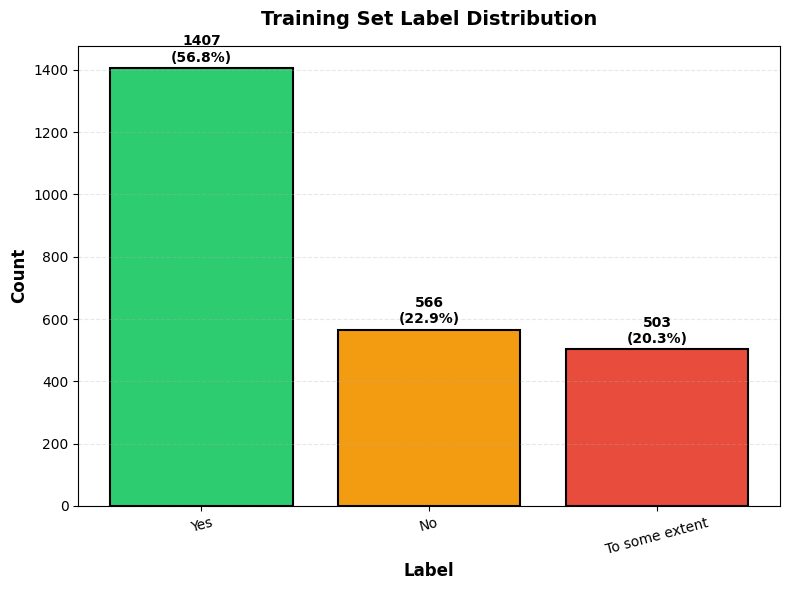


✓ Saved: label_distribution.png


In [10]:
def load_train_data(file_path):
    """Load training data with annotations (labels)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        answer_key = conversation['answer_key']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            if 'annotation' in response_data and 'Providing_Guidance' in response_data['annotation']:
                samples.append({
                    'conversation_history': conv_history,
                    'answer_key': answer_key,
                    'model': model_name,
                    'tutor_response': response_data['response'],
                    'label': response_data['annotation']['Providing_Guidance']
                    
                    
                })
    
    return pd.DataFrame(samples)

def load_test_data(file_path):
    """Load test data WITHOUT annotations (for inference only)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        #answer_key = conversation['answer_key']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            samples.append({
                'conversation_history': conv_history,
                #'answer_key': answer_key,
                'model': model_name,
                'tutor_response': response_data['response']
                
            })
    
    return pd.DataFrame(samples)

# Load datasets
print("Loading datasets...")
print("Note: Train set has labels, Dev/Test sets are for prediction only")
train_df = load_train_data('../../data/trainset_with_answers.json')
#dev_df = load_test_data('../../data/dev_testset.json')
testing_df = load_test_data('../../data/testset.json')

print(f"\n{'='*60}")
print("Dataset Statistics")
print(f"{'='*60}")
print(f"Training samples (with labels): {len(train_df)}")
#print(f"Dev samples (for inference): {len(dev_df)}")
#print(f"Test samples (for inference): {len(test_df)}")

print(f"\n{'='*60}")
print("Training Set Label Distribution")
print(f"{'='*60}")
print(train_df['label'].value_counts())
print(f"\n📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!")

# Visualize label distribution (training data only)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
counts = train_df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax.set_title('Training Set Label Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Label', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count}\n({count/len(train_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: label_distribution.png")

## 3. Data Analysis & Insights

## 4. Prepare Model and Tokenizer

We'll use **DeBERTa-v3-base** which excels at natural language understanding tasks.

In [11]:
# Model selection - DeBERTa-v3-large is excellent for understanding nuanced text
MODEL_NAME = "microsoft/deberta-v3-base"
# Alternative options if needed:
# MODEL_NAME = "roberta-base"
# MODEL_NAME = "bert-base-uncased"

# Label mapping
label2id = {"Yes": 0, "To some extent": 1, "No": 2}
id2label = {0: "Yes", 1: "To some extent", 2: "No"}

print(f"Selected Model: {MODEL_NAME}")
print(f"Label mapping: {label2id}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nTokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Max length: {tokenizer.model_max_length}")

Selected Model: microsoft/deberta-v3-base
Label mapping: {'Yes': 0, 'To some extent': 1, 'No': 2}

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656


## 4b. DATA AUGMENTATION

In [4]:
print(train_df.head(2))

                                conversation_history  \
0  Tutor: Hi, could you please provide a step-by-...   
1  Tutor: Hi, could you please provide a step-by-...   

                                          answer_key      model  \
0  1. First, we need to determine how many sandwi...     Sonnet   
1  1. First, we need to determine how many sandwi...  Llama318B   

                                      tutor_response           label  
0  Great, you've correctly identified the cost of...             Yes  
1  Now that we know the cost of 1 pound of meat i...  To some extent  


In [80]:
# import re
# import pandas as pd

# def conversation_from_second_last_student(conversation_history: str) -> str:
#     """
#     Return the substring of conversation_history starting at the second-last
#     occurrence of "Student:". If there is only one "Student:", return from
#     that. If none, return an empty string.
#     """
#     if not isinstance(conversation_history, str):
#         return ""
#     # find all start indices of the literal "Student:"
#     matches = [m.start() for m in re.finditer(r"Student:", conversation_history)]
#     if not matches:
#         return ""                          # no student dialogues
#     if len(matches) == 1:
#         start_idx = matches[0]             # only one, return from it
#     else:
#         start_idx = matches[-2]           # second-last occurrence
#     return conversation_history[start_idx:].strip()

# # Example: apply to your dataframe column
# # (Assumes testing_df exists and has 'conversation_history' column)
# train_df['conversation_history_2nd_last_student'] = (
#     train_df['conversation_history'].apply(conversation_from_second_last_student)
# )
# # testing_df['conversation_history_2nd_last_student'] = (
# #     testing_df['conversation_history'].apply(conversation_from_second_last_student)
# # )

# # If you want to overwrite the original column:
# # testing_df['conversation_history'] = testing_df['conversation_history'].apply(conversation_from_second_last_student)


In [81]:
# import pandas as pd
# from transformers import AutoTokenizer
# import numpy as np
# import matplotlib.pyplot as plt

# # Load the tokenizer for DeBERTa-v3-base
# tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

# # Construct the input text for each row
# def build_input_text(row):
#     return f"{row['conversation_history_2nd_last_student']} [SEP] Tutor name : {row['model']} [SEP] Tutor Response : {row['tutor_response']} [SEP] Answer Key : {row['answer_key']}"

# print("Building input texts...")
# train_df["input_text"] = train_df.apply(build_input_text, axis=1)

# # Tokenize and count tokens
# print("Counting tokens using DeBERTa-v3-base tokenizer...")
# train_df["num_tokens"] = train_df["input_text"].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

# # Summary statistics
# print("\n--- Token Statistics ---")
# print(train_df["num_tokens"].describe())

# # Optional: visualize token length distribution
# plt.figure(figsize=(8, 5))
# plt.hist(train_df["num_tokens"], bins=40, color="steelblue", edgecolor="black")
# plt.title("Token Count Distribution (DeBERTa-v3-base)")
# plt.xlabel("Number of Tokens")
# plt.ylabel("Frequency")
# plt.grid(True, alpha=0.3)
# plt.show()

# # Optional: check percentage exceeding model limit (e.g., 512 tokens)
# limit = 512
# exceeding = (train_df["num_tokens"] > limit).mean() * 100
# print(f"\nPercentage of samples exceeding {limit} tokens: {exceeding:.2f}%")

# # If you want to save the token counts
# # testing_df.to_csv("token_count_analysis.csv", index=False)


In [12]:
import pandas as pd

def extract_formatted_text(conversation_history):
    """
    Extracts the question (including the "The question is:") and all student 
    dialogues, with the first dialogue prefixed with "Student:".
    """
    question_text = ""
    student_dialogues = []

    # 1. Extract the question text
    try:
        question_part = conversation_history.split("The question is:")[1]
        question_body = question_part.split("Student:")[0].strip()
        # MODIFICATION: Prepend the phrase back to the question
        question_text = "The question is: " + question_body
    except IndexError:
        return "" # Return empty string if the format is unexpected

    # 2. Extract all student dialogues (without the tag initially)
    parts = conversation_history.split("Student:")
    for part in parts[1:]:
        student_text = part.split("Tutor:")[0].strip()
        student_dialogues.append(student_text)
        
    # 3. MODIFICATION: Add "Student:" prefix to the first dialogue only
    if student_dialogues:
        student_dialogues[0] = "Student: " + student_dialogues[0]
        
    # 4. Combine the question and all dialogues
    # Start with the question text
    final_parts = [question_text]
    
    # Add the (now formatted) student dialogues
    if student_dialogues:
        final_parts.extend(student_dialogues)
        
    # Join everything with a single space
    return " ".join(final_parts)



# Create a new column 'cleaned_text' by applying the function
print("Cleaning conversation history...")
train_df['conversation_history'] = train_df['conversation_history'].apply(extract_formatted_text)
print("Done.")

#testing_df['conversation_history'] = testing_df['conversation_history'].apply(extract_formatted_text)

Cleaning conversation history...
Done.


## 5. Create PyTorch Dataset

In [15]:
class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Combine conversation history and tutor response

        #text = f"{row['tutor_response']} [SEP] Correct reasoning: {row['answer_key']}"

        text = f"{row['conversation_history']} [SEP] Tutor name : {row['model']} [SEP] Tutor Response : {row['tutor_response']} "




        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        
        return item

# Create datasets
MAX_LENGTH = 512

# Split training data into train and validation (80/20)
from sklearn.model_selection import train_test_split

# First, split off the dev/test set (15%)
train_val_data, dev_data = train_test_split(
    train_df,
    test_size=0.15,  # 15% of total for dev/test
    random_state=42,
    stratify=train_df['label']
)

# Then split the remaining into train (70%) and validation (15% of total, i.e., 17.65% of train_val_data)
val_size = 0.15 / 0.85  # proportion relative to train_val_data
train_data, val_data = train_test_split(
    train_val_data,
    test_size=val_size,
    random_state=42,
    stratify=train_val_data['label']
)

print(f"Data split:")
print(f"  Training: {len(train_data)} samples ({len(train_data)/len(train_df)*100:.1f}%)")
print(f"  Validation: {len(val_data)} samples ({len(val_data)/len(train_df)*100:.1f}%)")
print(f"  Dev/Test: {len(dev_data)} samples ({len(dev_data)/len(train_df)*100:.1f}%)")

# Create datasets
train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)
dev_dataset = MistakeIdentificationDataset(dev_data, tokenizer, MAX_LENGTH, has_labels=True)  # or False for inference
testing_dataset = MistakeIdentificationDataset(testing_df, tokenizer, MAX_LENGTH, has_labels=False)  # No labels in test set


# sample_inf = dev_dataset[0]
# print(f"\nSample from inference dataset (dev):")
# print(f"  Input IDs shape: {sample_inf['input_ids'].shape}")
# print(f"  Attention mask shape: {sample_inf['attention_mask'].shape}")
# print(f"  Has label: {'labels' in sample_inf}")

Data split:
  Training: 1732 samples (70.0%)
  Validation: 372 samples (15.0%)
  Dev/Test: 372 samples (15.0%)


## 6. Handle Data Imbalance (Multiple Strategies)

We'll use a **comprehensive approach** to handle class imbalance:
1. **Class Weights** - Give more importance to minority classes in loss
2. **Stratified Sampling** - Ensure balanced validation split
3. **Data Augmentation** (optional) - Oversample minority classes
4. **Focal Loss** (optional) - Focus on hard-to-classify examples

In [6]:
# ============================================================================
# STRATEGY 1: Calculate Class Weights (Inverse Frequency)
# ============================================================================
train_labels = train_df['label'].map(label2id).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)
print("\nOriginal Class Distribution:")
for label, count in train_df['label'].value_counts().sort_index().items():
    percentage = (count / len(train_df)) * 100
    weight = class_weights[label2id[label]]
    print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%) → weight: {weight:.3f}")

# ============================================================================
# STRATEGY 2: Oversample Minority Classes (SMOTE-like approach)
# ============================================================================
from collections import Counter
from sklearn.utils import resample

def balance_dataset(df, target_col='label', strategy='oversample'):
    """
    Balance dataset by oversampling minority classes.
    """
    if strategy == 'none':
        return df
    
    # Get class counts
    class_counts = df[target_col].value_counts()
    max_count = class_counts.max()
    
    balanced_dfs = []
    for label in class_counts.index:
        class_df = df[df[target_col] == label]
        
        if strategy == 'oversample':
            # Oversample to match majority class
            if len(class_df) < max_count:
                class_df_resampled = resample(
                    class_df,
                    n_samples=max_count,
                    replace=True,
                    random_state=42
                )
                balanced_dfs.append(class_df_resampled)
            else:
                balanced_dfs.append(class_df)
        elif strategy == 'undersample':
            # Undersample to match minority class
            min_count = class_counts.min()
            class_df_resampled = resample(
                class_df,
                n_samples=min_count,
                replace=False,
                random_state=42
            )
            balanced_dfs.append(class_df_resampled)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    return balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Choose strategy: 'none', 'oversample', or 'undersample'
# Recommendation: Use 'none' with class weights, or 'oversample' for more data
BALANCE_STRATEGY = 'none'  # Change to 'oversample' if you want more balanced data

if BALANCE_STRATEGY != 'none':
    print(f"\n{'='*80}")
    print(f"APPLYING {BALANCE_STRATEGY.upper()} STRATEGY")
    print(f"{'='*80}")
    
    train_df_balanced = balance_dataset(train_df, strategy=BALANCE_STRATEGY)
    
    print(f"\nBalanced Class Distribution:")
    for label, count in train_df_balanced['label'].value_counts().sort_index().items():
        percentage = (count / len(train_df_balanced)) * 100
        print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%)")
    
    # Update training dataframe
    train_df = train_df_balanced
    print(f"\n✓ Training data balanced: {len(train_df)} total samples")
else:
    print(f"\n{'='*80}")
    print("Using WEIGHTED LOSS without data resampling")
    print(f"{'='*80}")

# ============================================================================
# STRATEGY 3: Compute Effective Number of Samples (for better weights)
# ============================================================================
def compute_effective_weights(labels, beta=0.9999):
    """
    Compute class weights using Effective Number of Samples.
    Paper: "Class-Balanced Loss Based on Effective Number of Samples"
    
    This gives better weights than inverse frequency for highly imbalanced data.
    """
    class_counts = Counter(labels)
    total_samples = len(labels)
    
    effective_weights = {}
    for cls, count in class_counts.items():
        effective_num = (1 - beta**count) / (1 - beta)
        weight = (1 - beta) / effective_num
        effective_weights[cls] = weight
    
    # Normalize weights
    weight_sum = sum(effective_weights.values())
    for cls in effective_weights:
        effective_weights[cls] = effective_weights[cls] / weight_sum * len(effective_weights)
    
    return effective_weights

# Calculate effective weights (alternative to balanced weights)
effective_weights_dict = compute_effective_weights(train_labels)
effective_weights_array = np.array([effective_weights_dict[i] for i in range(3)])
effective_weights_tensor = torch.tensor(effective_weights_array, dtype=torch.float32)

print(f"\n{'='*80}")
print("WEIGHT COMPARISON")
print(f"{'='*80}")
print("\nBalanced Weights (sklearn):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {class_weights[i]:.4f}")

print("\nEffective Number Weights (beta=0.9999):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {effective_weights_array[i]:.4f}")

# ============================================================================
# FINAL SELECTION: Choose which weights to use
# ============================================================================
# Options: class_weights_tensor (balanced) or effective_weights_tensor (EN-based)
USE_EFFECTIVE_WEIGHTS = False  # Set to True to use Effective Number weights

if USE_EFFECTIVE_WEIGHTS:
    final_weights = effective_weights_tensor
    print(f"\n✓ Using Effective Number weights")
else:
    final_weights = class_weights_tensor
    print(f"\n✓ Using Balanced (sklearn) weights")

# Store for trainer
class_weights_tensor = final_weights

print(f"\n{'='*80}")
print("Class imbalance handling configured successfully!")
print(f"{'='*80}")

CLASS IMBALANCE ANALYSIS

Original Class Distribution:
  No                  :  566 samples ( 22.9%) → weight: 1.458
  To some extent      :  503 samples ( 20.3%) → weight: 1.641
  Yes                 : 1407 samples ( 56.8%) → weight: 0.587

Using WEIGHTED LOSS without data resampling

WEIGHT COMPARISON

Balanced Weights (sklearn):
  Yes                 : 0.5866
  To some extent      : 1.6408
  No                  : 1.4582

Effective Number Weights (beta=0.9999):
  Yes                 : 0.4950
  To some extent      : 1.3244
  No                  : 1.1806

✓ Using Balanced (sklearn) weights

Class imbalance handling configured successfully!


## 7. Define Custom Trainer with Weighted Loss

In [7]:
# class WeightedTrainer(Trainer):
#     """
#     Custom Trainer with support for:
#     1. Weighted Cross-Entropy Loss
#     2. Focal Loss (optional)
#     """
    
#     def __init__(self, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, *args, **kwargs):
#         super().__init__(*args, **kwargs)
#         self.class_weights = class_weights
#         self.use_focal_loss = use_focal_loss
#         self.focal_alpha = focal_alpha  # Can be None or tensor of per-class weights
#         self.focal_gamma = focal_gamma
        
#         # Move class weights to the correct device
#         if self.class_weights is not None:
#             self.class_weights = self.class_weights.to(self.args.device)
        
#         # Move focal alpha to the correct device
#         if self.focal_alpha is not None:
#             self.focal_alpha = self.focal_alpha.to(self.args.device)
        
#         if self.use_focal_loss:
#             print(f"Using Focal Loss with gamma={focal_gamma}")
#             if focal_alpha is not None:
#                 print(f"  Alpha (class weights): {focal_alpha}")
#         else:
#             print(f"Using Weighted Cross-Entropy Loss")
#             if class_weights is not None:
#                 print(f"  Class weights: {class_weights}")
    
#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         """
#         Compute custom loss (weighted CE or focal loss).
#         """
#         labels = inputs.pop("labels")
        
#         # Forward pass
#         outputs = model(**inputs)
#         logits = outputs.logits
        
#         if self.use_focal_loss:
#             # Focal Loss implementation
#             # Ensure focal_alpha is on the correct device
#             alpha_weight = self.focal_alpha if self.focal_alpha is None else self.focal_alpha.to(logits.device)
            
#             ce_loss = F.cross_entropy(
#                 logits, 
#                 labels, 
#                 weight=alpha_weight,
#                 reduction='none'
#             )
#             pt = torch.exp(-ce_loss)  # pt is the probability of correct class
#             focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
#             loss = focal_loss
#         else:
#             # Weighted Cross-Entropy Loss
#             # Ensure class_weights is on the correct device
#             weights = self.class_weights if self.class_weights is None else self.class_weights.to(logits.device)
            
#             loss = F.cross_entropy(
#                 logits,
#                 labels,
#                 weight=weights
#             )
        
#         return (loss, outputs) if return_outputs else loss

## 8. Define Metrics

In [8]:
def compute_metrics(eval_pred):
    """Compute comprehensive metrics for evaluation."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    
    # Overall metrics
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2]
    )
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_yes': f1[0],
        'f1_to_some_extent': f1[1],
        'f1_no': f1[2],
        'precision_yes': precision[0],
        'precision_to_some_extent': precision[1],
        'precision_no': precision[2],
        'recall_yes': recall[0],
        'recall_to_some_extent': recall[1],
        'recall_no': recall[2],
    }

print("Metrics computation function defined!")

Metrics computation function defined!


## 9. Initialize Model and Training Configuration

In [9]:
# Load the pre-trained model for sequence classification
print("="*80)
print("LOADING MODEL")
print("="*80)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nModel: {MODEL_NAME}")
print(f"Number of labels: 3")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("\n✓ Model loaded successfully!")
print("="*80)

LOADING MODEL


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model: microsoft/deberta-v3-base
Number of labels: 3
Device: cuda
Model parameters: 184,424,451
Trainable parameters: 184,424,451

✓ Model loaded successfully!


## 10. Initialize Trainer and Start Training

## 10b. Hyperparameter Tuning

In [67]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# Map labels to integers (if not already)
train_labels = train_df['label'].map(label2id).values

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("="*80)
print("CLASS WEIGHTS (Balanced):")
for i, label in enumerate(label2id):
    print(f"  {label:20s}: {class_weights[i]:.4f}")
print("="*80)


CLASS WEIGHTS (Balanced):
  Yes                 : 0.5866
  To some extent      : 1.6408
  No                  : 1.4582


In [68]:
import torch.nn.functional as F

class WeightedCETrainer(Trainer):
    def __init__(self, *args, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute weighted cross-entropy (or focal) loss.
        Accepts any extra kwargs from Trainer.
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Ensure weights are on the same device as logits
        weights = self.class_weights.to(logits.device) if self.class_weights is not None else None

        if self.use_focal_loss:
            # Focal Loss
            alpha = self.focal_alpha.to(logits.device) if self.focal_alpha is not None else None
            ce_loss = F.cross_entropy(logits, labels, weight=alpha, reduction='none')
            pt = torch.exp(-ce_loss)
            loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
        else:
            # Weighted CE
            loss = F.cross_entropy(logits, labels, weight=weights)

        return (loss, outputs) if return_outputs else loss


In [69]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score
)
import numpy as np
import optuna
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, AutoModelForSequenceClassification, AutoTokenizer
import torch

# # --- MODEL CONFIGURATION FOR DEBERTA V3 BASE ---
# MODEL_NAME = "microsoft/deberta-v3-base"  # Changed from Large to Base
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load tokenizer
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# # Label mapping
# id2label = {0: "Yes", 1: "To some extent", 2: "No"}
# label2id = {"Yes": 0, "To some extent": 1, "No": 2}

# --- Compute metrics ---
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    
    # Per-class metrics
    f1_yes = f1_score(labels, preds, labels=[0], average=None, zero_division=0)[0]
    f1_some = f1_score(labels, preds, labels=[1], average=None, zero_division=0)[0]
    f1_no = f1_score(labels, preds, labels=[2], average=None, zero_division=0)[0]

    precision_yes = precision_score(labels, preds, labels=[0], average=None, zero_division=0)[0]
    precision_some = precision_score(labels, preds, labels=[1], average=None, zero_division=0)[0]
    precision_no = precision_score(labels, preds, labels=[2], average=None, zero_division=0)[0]

    recall_yes = recall_score(labels, preds, labels=[0], average=None, zero_division=0)[0]
    recall_some = recall_score(labels, preds, labels=[1], average=None, zero_division=0)[0]
    recall_no = recall_score(labels, preds, labels=[2], average=None, zero_division=0)[0]

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_yes": f1_yes,
        "f1_to_some_extent": f1_some,
        "f1_no": f1_no,
        "precision_yes": precision_yes,
        "precision_to_some_extent": precision_some,
        "precision_no": precision_no,
        "recall_yes": recall_yes,
        "recall_to_some_extent": recall_some,
        "recall_no": recall_no 
    }


# --- Optuna objective function ---
def objective(trial):
    """
    Optimized hyperparameter search for DeBERTa v3 Base
    - Narrower search space focused on most impactful parameters
    - Adjusted for smaller model size (86M vs 304M params)
    - Less aggressive regularization needed
    """
    
    # CORE HYPERPARAMETERS - Narrow focused search
    learning_rate = trial.suggest_float("learning_rate", 7e-6, 1.2e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0.03, 0.10)
    
    # FIXED efficient settings
    scheduler_type = "cosine"  # Fixed based on Trial 9 success
    per_device_train_batch_size = 8  # Fixed for consistency
    gradient_accumulation_steps = 1  # Fixed
    warmup_ratio = 0.09  # Fixed based on Trial 9
    
    # EPOCHS - Reduced for Base model (trains faster)
    num_train_epochs = trial.suggest_int("num_train_epochs", 8, 15)
    
    # DROPOUT - Lower range for Base (less prone to overfitting)
    hidden_dropout_prob = trial.suggest_float("hidden_dropout_prob", 0.05, 0.20)
    attention_dropout_prob = trial.suggest_float("attention_dropout_prob", 0.05, 0.25)
    
    # LABEL SMOOTHING
    label_smoothing_factor = trial.suggest_float("label_smoothing_factor", 0.05, 0.15)
    
    # LAYER FREEZING - Adjusted for Base (12 layers total vs 24 in Large)
    num_layers_to_freeze = trial.suggest_int("num_layers_to_freeze", 0, 6)
    
    # LOSS FUNCTION
    loss_choice = trial.suggest_categorical("loss_function", ["weighted_ce", "focal_loss"])
    
    # OVERFITTING PENALTY WEIGHTS - Fine-tuned based on Trial 9
    penalty_severe = trial.suggest_float("penalty_severe", 0.20, 0.30)
    penalty_moderate = trial.suggest_float("penalty_moderate", 0.45, 0.60)
    penalty_mild = trial.suggest_float("penalty_mild", 0.80, 0.92)

    # --- INITIALIZE MODEL ---
    model_fresh = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=hidden_dropout_prob,
        attention_probs_dropout_prob=attention_dropout_prob
    ).to(device)

    # --- LAYER FREEZING ---
    if num_layers_to_freeze > 0:
        # Freeze embeddings
        for param in model_fresh.deberta.embeddings.parameters():
            param.requires_grad = False
        
        # Freeze encoder layers (Base has 12 layers: 0-11)
        for layer in model_fresh.deberta.encoder.layer[:num_layers_to_freeze]:
            for param in layer.parameters():
                param.requires_grad = False

    # --- TRAINING ARGUMENTS ---
    training_args = TrainingArguments(
        output_dir=f"./optuna_base_trial_{trial.number}",
        eval_strategy="steps",
        eval_steps=50,
        save_strategy="steps",
        save_steps=50,
        logging_steps=50,
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_train_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        lr_scheduler_type=scheduler_type,
        gradient_accumulation_steps=gradient_accumulation_steps,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=True,
        logging_dir=f"./optuna_base_logs_{trial.number}",
        logging_strategy="steps",
        label_smoothing_factor=label_smoothing_factor,
        max_grad_norm=1.0,
        report_to="none",
        save_total_limit=2,  # Save space
    )

    # --- TRAINER SETUP ---
    if loss_choice == "focal_loss":
        focal_gamma = trial.suggest_float("focal_gamma", 1.0, 2.5)
        trainer = WeightedCETrainer(
            model=model_fresh,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
            use_focal_loss=True,
            focal_alpha=class_weights_tensor,
            focal_gamma=focal_gamma
        )
    else:
        trainer = WeightedCETrainer(
            model=model_fresh,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            tokenizer=tokenizer,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
            class_weights=class_weights_tensor
        )

    # --- TRAINING ---
    trainer.train()
    eval_results = trainer.evaluate()

    # --- EXTRACT METRICS ---
    train_loss = None
    for log in reversed(trainer.state.log_history):
        if "loss" in log:
            train_loss = log["loss"]
            break
    
    eval_loss = eval_results.get("eval_loss", 1.0)
    f1_macro = eval_results.get("eval_f1_macro", 0.0)
    
    # --- CALCULATE OVERFITTING PENALTY ---
    if train_loss and train_loss > 0 and eval_loss > 0:
        loss_ratio = train_loss / eval_loss
    else:
        loss_ratio = 0.0
    
    # Apply penalty based on overfitting severity
    if loss_ratio < 0.2:  # Severe overfitting
        penalty = penalty_severe
    elif loss_ratio < 0.3:  # Moderate overfitting
        penalty = penalty_moderate
    elif loss_ratio < 0.4:  # Mild overfitting
        penalty = penalty_mild
    elif 0.4 <= loss_ratio <= 1.0:  # Healthy range
        penalty = 1.0
    elif loss_ratio <= 1.5:  # Slight underfitting
        penalty = 0.95
    else:  # Severe underfitting
        penalty = 0.7
    
    # Custom score to balance F1 and generalization
    custom_score = f1_macro * penalty

    # --- STORE TRIAL METADATA ---
    trial.set_user_attr("metrics", eval_results)
    trial.set_user_attr("train_loss", train_loss)
    trial.set_user_attr("eval_loss", eval_loss)
    trial.set_user_attr("loss_ratio", loss_ratio)
    trial.set_user_attr("f1_macro", f1_macro)
    trial.set_user_attr("penalty", penalty)
    trial.set_user_attr("custom_score", custom_score)
    trial.set_user_attr("model_size", "base")

    # Flag severe overfitting
    if loss_ratio < 0.2:
        trial.set_user_attr("overfitting_severe", True)

    return custom_score


# --- RUN OPTIMIZATION ---
print("="*80)
print("STARTING HYPERPARAMETER OPTIMIZATION FOR DEBERTA V3 BASE")
print(f"Model: {MODEL_NAME}")
print(f"Input format: conversation_history [SEP] Tutor name: model [SEP] Tutor Response: response")
print(f"Number of trials: 15")
print("="*80)

study = optuna.create_study(
    direction="maximize",
    study_name="deberta_base_guidance_classification"
)
study.optimize(objective, n_trials=15)

# --- RESULTS SUMMARY ---
print("\n" + "="*80)
print("OPTIMIZATION COMPLETE - BEST TRIAL")
print("="*80)
trial = study.best_trial
best_metrics = trial.user_attrs.get("metrics", {})
train_loss = trial.user_attrs.get("train_loss", 0)
eval_loss = best_metrics.get("eval_loss", 1)
loss_ratio = trial.user_attrs.get("loss_ratio", 0)

print(f"\n  Trial Number: {trial.number}")
print(f"  Custom Score: {trial.value:.4f}")
print(f"  F1 Macro: {trial.user_attrs.get('f1_macro', 0):.4f}")
print(f"  Penalty Applied: {trial.user_attrs.get('penalty', 0):.4f}")

print(f"\n  === LOSS ANALYSIS ===")
print(f"  Training Loss: {train_loss:.4f}")
print(f"  Validation Loss: {eval_loss:.4f}")
print(f"  Loss Ratio: {loss_ratio:.3f}")
if loss_ratio < 0.3:
    print(f"  ⚠️  WARNING: Overfitting detected!")
elif 0.4 <= loss_ratio <= 1.0:
    print(f"  ✓ Healthy generalization")

print(f"\n  === PERFORMANCE METRICS ===")
print(f"  Accuracy: {best_metrics.get('eval_accuracy', 0):.4f}")
print(f"  F1 Weighted: {best_metrics.get('eval_f1_weighted', 0):.4f}")

print(f"\n  === PER-CLASS F1 SCORES ===")
print(f"  F1 Yes: {best_metrics.get('eval_f1_yes', 0):.4f}")
print(f"  F1 To Some Extent: {best_metrics.get('eval_f1_to_some_extent', 0):.4f}")
print(f"  F1 No: {best_metrics.get('eval_f1_no', 0):.4f}")

print(f"\n  === BEST HYPERPARAMETERS ===")
for key, value in trial.params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}" if value < 0.01 else f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# --- TOP 5 TRIALS ---
print("\n" + "="*80)
print("TOP 5 TRIALS (by Custom Score)")
print("="*80)
top_trials = sorted(
    study.trials, 
    key=lambda t: t.value if t.value is not None else -1, 
    reverse=True
)[:5]

for i, t in enumerate(top_trials, 1):
    metrics = t.user_attrs.get("metrics", {})
    train_loss = t.user_attrs.get("train_loss", 0)
    eval_loss = metrics.get("eval_loss", 1)
    loss_ratio = t.user_attrs.get("loss_ratio", 0)
    f1_macro = t.user_attrs.get("f1_macro", 0)
    
    print(f"\n{i}. Trial {t.number}")
    print(f"   Custom Score: {t.value:.4f}")
    print(f"   F1 Macro: {f1_macro:.4f}")
    print(f"   Loss Ratio: {loss_ratio:.3f} {'⚠️ Overfitting' if loss_ratio < 0.3 else '✓'}")
    print(f"   LR: {t.params.get('learning_rate', 0):.2e} | "
          f"Hidden Dropout: {t.params.get('hidden_dropout_prob', 0):.3f} | "
          f"Attn Dropout: {t.params.get('attention_dropout_prob', 0):.3f}")
    print(f"   Frozen Layers: {t.params.get('num_layers_to_freeze', 0)} | "
          f"Epochs: {t.params.get('num_train_epochs', 0)} | "
          f"Weight Decay: {t.params.get('weight_decay', 0):.3f}")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)
print("1. Use the best trial's hyperparameters for final training")
print("2. Monitor validation loss closely during training")
print("3. If F1 < 0.65, consider:")
print("   - Checking class balance and data quality")
print("   - Trying different input formats")
print("   - Collecting more training data")
print("4. Save the best model using: trainer.save_model('./best_model')")
print("="*80)

[I 2025-10-12 17:08:57,505] A new study created in memory with name: deberta_base_guidance_classification


STARTING HYPERPARAMETER OPTIMIZATION FOR DEBERTA V3 BASE
Model: microsoft/deberta-v3-base
Input format: conversation_history [SEP] Tutor name: model [SEP] Tutor Response: response
Number of trials: 15


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Step,Training Loss,Validation Loss


[W 2025-10-12 17:09:07,574] Trial 0 failed with parameters: {'learning_rate': 7.429562354346943e-06, 'weight_decay': 0.05795210542223578, 'num_train_epochs': 9, 'hidden_dropout_prob': 0.07262815843177572, 'attention_dropout_prob': 0.11932754175284088, 'label_smoothing_factor': 0.13609510253572188, 'num_layers_to_freeze': 4, 'loss_function': 'focal_loss', 'penalty_severe': 0.20319295738033402, 'penalty_moderate': 0.4682397103828714, 'penalty_mild': 0.8396600147921013, 'focal_gamma': 1.7567250802394077} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/DATA/cs24mtech12016/.conda/envs/indoml/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1863499/1901960627.py", line 175, in objective
    trainer.train()
  File "/DATA/cs24mtech12016/.conda/envs/indoml/lib/python3.12/site-packages/transformers/trainer.py", line 2325, in t

KeyboardInterrupt: 

## Trail 10 for more Epochs 

In [20]:
import torch
import numpy as np
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import f1_score, accuracy_score

# ==================== CONFIGURATION ====================
MODEL_NAME = "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Label mapping
id2label = {0: "Yes", 1: "To some extent", 2: "No"}
label2id = {"Yes": 0, "To some extent": 1, "No": 2}

print("="*80)
print("RETRAINING TRIAL 14 WITH EXTENDED EPOCHS")
print("="*80)
print("Original Trial 10: 8 epochs, stopped at step 550")
print("Extended Training: 15 epochs with early stopping")
print("Hypothesis: Model was undertrained and has more potential")
print("="*80)

# ==================== TRIAL 10 EXACT HYPERPARAMETERS ====================
# These are the EXACT values from Trial 10
TRIAL_10_CONFIG = {
    'learning_rate': 9.430044370315666e-06,
    'weight_decay': 0.055796330984862835,
    'num_train_epochs': 20,  # EXTENDED from 8 to 15
    'hidden_dropout_prob': 0.10081756939274811,
    'attention_dropout_prob': 0.09780428858213977,
    'label_smoothing_factor': 0.06630565551768045,
    'num_layers_to_freeze': 6,
    'loss_function': 'weighted_ce',
    # Penalty values (for reference)
    'penalty_severe': 0.2977416239356122,
    'penalty_moderate': 0.5449677294574923,
    'penalty_mild': 0.9142479245859364
}

print(f"\n📋 TRIAL 10 CONFIGURATION")
print(f"{'='*50}")
for key, value in TRIAL_10_CONFIG.items():
    if isinstance(value, float) and value < 0.01:
        print(f"  {key:<30} {value:.10f}")
    elif isinstance(value, float):
        print(f"  {key:<30} {value:.6f}")
    else:
        print(f"  {key:<30} {value}")
print("="*80)

# ==================== LOAD TOKENIZER ====================
print("\n[1/6] Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✓ Tokenizer loaded")

# ==================== INITIALIZE FRESH MODEL ====================
print("\n[2/6] Initializing fresh DeBERTa v3 Base model...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=TRIAL_10_CONFIG['hidden_dropout_prob'],
    attention_probs_dropout_prob=TRIAL_10_CONFIG['attention_dropout_prob']
).to(device)

print("✓ Model initialized with Trial 10's dropout configuration")

# ==================== FREEZE LAYERS ====================
print(f"\n[3/6] Freezing {TRIAL_10_CONFIG['num_layers_to_freeze']} layers...")

# Freeze embeddings
for param in model.deberta.embeddings.parameters():
    param.requires_grad = False
print("  ✓ Embeddings frozen")

# Freeze first 6 encoder layers (out of 12 total)
for layer_idx in range(TRIAL_10_CONFIG['num_layers_to_freeze']):
    for param in model.deberta.encoder.layer[layer_idx].parameters():
        param.requires_grad = False
print(f"  ✓ First {TRIAL_10_CONFIG['num_layers_to_freeze']} encoder layers frozen")

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters: {total_params - trainable_params:,}")
print(f"  Trainable ratio: {trainable_params/total_params*100:.1f}%")

# ==================== COMPUTE METRICS ====================
def compute_metrics(pred):
    """Compute evaluation metrics"""
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    
    # Per-class F1
    f1_per_class = f1_score(labels, preds, average=None, zero_division=0)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_yes": f1_per_class[0],
        "f1_to_some_extent": f1_per_class[1],
        "f1_no": f1_per_class[2]
    }

# ==================== TRAINING ARGUMENTS ====================
print("\n[4/6] Setting up training configuration...")

training_args = TrainingArguments(
    output_dir="./trial10_extended",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=TRIAL_10_CONFIG['learning_rate'],
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=TRIAL_10_CONFIG['num_train_epochs'],
    weight_decay=TRIAL_10_CONFIG['weight_decay'],
    warmup_ratio=0.09,  # Standard from successful trials
    lr_scheduler_type="cosine",  # Standard from successful trials
    gradient_accumulation_steps=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./trial10_extended_logs",
    logging_strategy="steps",
    label_smoothing_factor=TRIAL_10_CONFIG['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=3,  # Keep only best 3 checkpoints
)

print("✓ Training arguments configured")
print(f"  Max epochs: {TRIAL_10_CONFIG['num_train_epochs']}")
print(f"  Early stopping patience: 5 evaluations")
print(f"  Evaluation every: 50 steps")

# ==================== TRAINER ====================
print("\n[5/6] Initializing Trainer...")

# Assuming you have WeightedCETrainer defined and class_weights_tensor available
# If using standard Trainer with weighted loss, use this:
trainer = WeightedCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=5,  # More patience than Trial 10's original (was 4)
            early_stopping_threshold=0.001
        )
    ],
    class_weights=class_weights_tensor  # Your class weights
)

print("✓ Trainer initialized with early stopping (patience=5)")

# ==================== TRAINING ====================
print("\n" + "="*80)
print("STARTING EXTENDED TRAINING")
print("="*80)
print("⏳ This will take approximately 15-25 minutes...")
print("📊 Watch for F1 Macro on validation set")
print("🎯 Target: Beat 0.544 (original Trial 10 best)")
print("="*80)

train_result = trainer.train()

print("\n✓ Training completed!")

# ==================== EVALUATE ON VALIDATION ====================
print("\n[6/6] Evaluating on validation set...")
val_results = trainer.evaluate(eval_dataset=val_dataset)

print("\n" + "="*80)
print("VALIDATION SET RESULTS (Extended Trial 10)")
print("="*80)
print(f"  F1 Macro:      {val_results['eval_f1_macro']:.4f}")
print(f"  Accuracy:      {val_results['eval_accuracy']:.4f}")
print(f"  F1 Weighted:   {val_results['eval_f1_weighted']:.4f}")
print(f"  Loss:          {val_results['eval_loss']:.4f}")
print(f"\n  Per-class F1:")
print(f"    Yes:              {val_results['eval_f1_yes']:.4f}")
print(f"    To some extent:   {val_results['eval_f1_to_some_extent']:.4f}")
print(f"    No:               {val_results['eval_f1_no']:.4f}")

# ==================== EVALUATE ON TEST ====================
print("\n" + "="*80)
print("EVALUATING ON TEST SET")
print("="*80)

test_results = trainer.evaluate(eval_dataset=dev_dataset)

print(f"\nTEST SET RESULTS (Extended Trial 10)")
print("="*80)
print(f"  F1 Macro:      {test_results['eval_f1_macro']:.4f}")
print(f"  Accuracy:      {test_results['eval_accuracy']:.4f}")
print(f"  F1 Weighted:   {test_results['eval_f1_weighted']:.4f}")
print(f"  Loss:          {test_results['eval_loss']:.4f}")
print(f"\n  Per-class F1:")
print(f"    Yes:              {test_results['eval_f1_yes']:.4f}")
print(f"    To some extent:   {test_results['eval_f1_to_some_extent']:.4f}")
print(f"    No:               {test_results['eval_f1_no']:.4f}")

# ==================== COMPARISON ====================
print("\n" + "="*80)
print("COMPARISON: ORIGINAL vs EXTENDED")
print("="*80)

print("\n📊 VALIDATION SET")
print(f"{'Metric':<20} {'Original (8 ep)':<18} {'Extended (15 ep)':<18} {'Change':<10}")
print("-" * 70)
print(f"{'F1 Macro':<20} {0.5446:<18.4f} {val_results['eval_f1_macro']:<18.4f} {(val_results['eval_f1_macro']-0.5446)*100:>+7.2f}%")
print(f"{'Stopped at step':<20} {'550':<18} {trainer.state.global_step:<18} {'---':<10}")

print("\n📊 TEST SET")
print(f"{'Metric':<20} {'Original (8 ep)':<18} {'Extended (15 ep)':<18} {'Change':<10}")
print("-" * 70)
print(f"{'F1 Macro':<20} {0.5268:<18.4f} {test_results['eval_f1_macro']:<18.4f} {(test_results['eval_f1_macro']-0.5268)*100:>+7.2f}%")

# Calculate generalization gap
original_gap = 0.5446 - 0.5268
extended_gap = val_results['eval_f1_macro'] - test_results['eval_f1_macro']

print("\n📉 GENERALIZATION GAP (Val - Test)")
print(f"{'Metric':<20} {'Original':<18} {'Extended':<18} {'Change':<10}")
print("-" * 70)
print(f"{'Gap':<20} {original_gap:<18.4f} {extended_gap:<18.4f} {(extended_gap-original_gap)*100:>+7.2f}%")

if extended_gap < original_gap:
    print("✓ Better generalization with extended training!")
elif extended_gap > original_gap * 1.5:
    print("⚠️  Warning: Generalization gap increased significantly")
else:
    print("→ Similar generalization to original")

# ==================== FINAL VERDICT ====================
print("\n" + "="*80)
print("FINAL VERDICT")
print("="*80)

test_improvement = test_results['eval_f1_macro'] - 0.5268
val_improvement = val_results['eval_f1_macro'] - 0.5446

if test_improvement > 0.01:
    print(f"✅ SUCCESS! Test F1 improved by {test_improvement*100:.2f}%")
    print(f"   Extended training was beneficial for Trial 10")
    print(f"\n🎯 New best test F1: {test_results['eval_f1_macro']:.4f}")
    if test_results['eval_f1_macro'] > 0.5647:
        print(f"   🏆 BEATS Trial 14! (was 0.5647)")
elif test_improvement > 0:
    print(f"→ Marginal improvement of {test_improvement*100:.2f}% on test set")
    print(f"   Extended training provided slight benefit")
elif test_improvement > -0.01:
    print(f"→ No significant change ({test_improvement*100:+.2f}%)")
    print(f"   Trial 10 had already reached its ceiling at 8 epochs")
else:
    print(f"❌ Test F1 decreased by {abs(test_improvement)*100:.2f}%")
    print(f"   Possible overtraining - original 8 epochs was optimal")

# ==================== SAVE MODEL ====================
if test_improvement > 0:
    print("\n💾 Saving extended Trial 10 model...")
    trainer.save_model("./trial10_extended_best")
    tokenizer.save_pretrained("./trial10_extended_best")
    print("✓ Model saved to: ./trial10_extended_best")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

# ==================== RECOMMENDATIONS ====================
print("\n💡 RECOMMENDATIONS BASED ON RESULTS")
print("="*80)

if test_improvement > 0.02:
    print("1. Use this extended Trial 10 model as your new baseline")
    print("2. Consider training even longer (18-20 epochs) with patience=6")
    print("3. This configuration generalizes better - try it with other inputs")
elif val_improvement > 0.02 and test_improvement < 0.01:
    print("1. Model is learning validation set patterns that don't transfer")
    print("2. Validation set may not be representative of test set")
    print("3. Consider k-fold cross-validation for more reliable estimates")
elif test_improvement < -0.01:
    print("1. Original 8 epochs was optimal for Trial 10")
    print("2. Focus on input format changes instead of more training")
    print("3. This configuration has hit its ceiling")
else:
    print("1. Trial 10 performance is stable across training lengths")
    print("2. Try different input formats with Trial 10's conservative config")
    print("3. The low dropout rates suggest room for other experiments")

print("="*80)

# ==================== SAVE TRAINING HISTORY ====================
# import pandas as pd

# # Extract training history
# history_df = pd.DataFrame(trainer.state.log_history)
# history_df.to_csv('./trial10_extended_training_history.csv', index=False)
# print(f"\n✓ Training history saved: trial10_extended_training_history.csv")
# print(f"✓ Total training steps: {trainer.state.global_step}")
# print(f"✓ Best checkpoint: {trainer.state.best_model_checkpoint}")

RETRAINING TRIAL 10 WITH EXTENDED EPOCHS
Original Trial 10: 8 epochs, stopped at step 550
Extended Training: 15 epochs with early stopping
Hypothesis: Model was undertrained and has more potential

📋 TRIAL 10 CONFIGURATION
  learning_rate                  0.0000094300
  weight_decay                   0.055796
  num_train_epochs               20
  hidden_dropout_prob            0.100818
  attention_dropout_prob         0.097804
  label_smoothing_factor         0.066306
  num_layers_to_freeze           6
  loss_function                  weighted_ce
  penalty_severe                 0.297742
  penalty_moderate               0.544968
  penalty_mild                   0.914248

[1/6] Loading tokenizer...
✓ Tokenizer loaded

[2/6] Initializing fresh DeBERTa v3 Base model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


✓ Model initialized with Trial 10's dropout configuration

[3/6] Freezing 6 layers...
  ✓ Embeddings frozen
  ✓ First 6 encoder layers frozen

  Total parameters: 184,424,451
  Trainable parameters: 43,514,883
  Frozen parameters: 140,909,568
  Trainable ratio: 23.6%

[4/6] Setting up training configuration...
✓ Training arguments configured
  Max epochs: 20
  Early stopping patience: 5 evaluations
  Evaluation every: 50 steps

[5/6] Initializing Trainer...
✓ Trainer initialized with early stopping (patience=5)

STARTING EXTENDED TRAINING
⏳ This will take approximately 15-25 minutes...
📊 Watch for F1 Macro on validation set
🎯 Target: Beat 0.544 (original Trial 10 best)


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No
50,1.101600,1.098042,0.567204,0.241281,0.410566,0.723842,0.000000,0.000000
100,1.099200,1.094760,0.594086,0.334424,0.477870,0.734043,0.000000,0.269231
150,1.086100,1.099047,0.244624,0.224785,0.145513,0.000000,0.354354,0.320000
200,1.078100,1.057863,0.510753,0.439160,0.509077,0.638498,0.340000,0.338983
250,1.036700,1.020015,0.368280,0.382152,0.376907,0.364286,0.348837,0.433333
300,0.982300,0.954557,0.405914,0.427650,0.394898,0.324723,0.340426,0.617801
350,0.926500,0.944886,0.443548,0.455797,0.439830,0.401408,0.354331,0.611650
400,0.913900,0.896337,0.672043,0.554448,0.636205,0.771186,0.209524,0.682635
450,0.842500,0.889419,0.583333,0.558752,0.594541,0.650407,0.362637,0.663212
500,0.819900,0.871196,0.599462,0.574550,0.609305,0.664850,0.402235,0.656566



✓ Training completed!

[6/6] Evaluating on validation set...



VALIDATION SET RESULTS (Extended Trial 10)
  F1 Macro:      0.6041
  Accuracy:      0.6210
  F1 Weighted:   0.6391
  Loss:          0.8749

  Per-class F1:
    Yes:              0.6937
    To some extent:   0.4121
    No:               0.7067

EVALUATING ON TEST SET

TEST SET RESULTS (Extended Trial 10)
  F1 Macro:      0.5442
  Accuracy:      0.5753
  F1 Weighted:   0.5857
  Loss:          0.9598

  Per-class F1:
    Yes:              0.6568
    To some extent:   0.4084
    No:               0.5676

COMPARISON: ORIGINAL vs EXTENDED

📊 VALIDATION SET
Metric               Original (8 ep)    Extended (15 ep)   Change    
----------------------------------------------------------------------
F1 Macro             0.5446             0.6041               +5.95%
Stopped at step      550                900                ---       

📊 TEST SET
Metric               Original (8 ep)    Extended (15 ep)   Change    
----------------------------------------------------------------------
F1 Macro  

## Trail 14 binary

BINARY CLASSIFICATION: PROVIDES GUIDANCE vs NO GUIDANCE
Converting 3-class problem to binary:
  'Yes' + 'To some extent' → 'Provides Guidance' (Label 1)
  'No' → 'No Guidance' (Label 0)

[STEP 1/8] Converting dataset labels to binary...
Converting train_dataset...
Converting val_dataset...
Converting dev_dataset (test)...

Creating binary dataset objects...
✓ Binary datasets created!

✓ Conversion complete!

📊 NEW LABEL DISTRIBUTION:

Dataset         No Guidance (0)      Provides Guidance (1)     Total     
---------------------------------------------------------------------------
Train           396                  1336                      1732      
Validation      85                   287                       372       
Test            85                   287                       372       

  Train: 77.1% Provides Guidance
  Test:  77.2% Provides Guidance

[STEP 2/8] Computing class weights for imbalanced data...
✓ Class weights computed:
  No Guidance (0): 2.1869
  Provides 

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


✓ Model initialized

  Freezing 5 layers...
  Trainable: 50,601,986 / 184,423,682 (27.4%)

[STEP 5/8] Configuring training arguments...
✓ Training configuration set

[STEP 6/8] Initializing Trainer with weighted loss...
✓ Trainer initialized with weighted CE loss

STARTING BINARY CLASSIFICATION TRAINING
⏳ Expected time: 15-25 minutes
🎯 Target: F1 > 0.72 (vs 0.5647 for 3-class)


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Binary,Precision Binary,Recall Binary,F1 No Guidance,F1 Provides Guidance,Precision No Guidance,Precision Provides Guidance,Recall No Guidance,Recall Provides Guidance
50,0.695300,0.688553,0.790323,0.595990,0.748142,0.876190,0.804665,0.961672,0.315789,0.876190,0.620690,0.804665,0.211765,0.961672
100,0.684000,0.656886,0.784946,0.644138,0.765690,0.867987,0.824451,0.916376,0.420290,0.867987,0.547170,0.824451,0.341176,0.916376
150,0.657000,0.596269,0.833333,0.757527,0.831147,0.893103,0.883959,0.902439,0.621951,0.893103,0.645570,0.883959,0.600000,0.902439
200,0.621700,0.596751,0.629032,0.604865,0.657928,0.702586,0.920904,0.567944,0.507143,0.702586,0.364103,0.920904,0.835294,0.567944
250,0.567800,0.539544,0.868280,0.796433,0.862103,0.917369,0.888889,0.947735,0.675497,0.917369,0.772727,0.888889,0.600000,0.947735
300,0.562000,0.525483,0.698925,0.662640,0.722718,0.773279,0.922705,0.665505,0.552000,0.773279,0.418182,0.922705,0.811765,0.665505
350,0.508400,0.458532,0.852151,0.787669,0.851207,0.904679,0.900000,0.909408,0.670659,0.904679,0.682927,0.900000,0.658824,0.909408
400,0.486100,0.445765,0.862903,0.804765,0.862617,0.911304,0.909722,0.912892,0.698225,0.911304,0.702381,0.909722,0.694118,0.912892
450,0.416400,0.432276,0.849462,0.799283,0.853779,0.899642,0.926199,0.874564,0.698925,0.899642,0.643564,0.926199,0.764706,0.874564
500,0.399000,0.446242,0.819892,0.770190,0.828224,0.877064,0.926357,0.832753,0.663317,0.877064,0.578947,0.926357,0.776471,0.832753



✓ Training completed!

[STEP 7/8] Evaluating on validation set...



VALIDATION SET RESULTS - BINARY MODEL

📊 OVERALL METRICS
  Accuracy:           0.8629
  F1 Macro:           0.8048
  F1 Weighted:        0.8626
  F1 Binary (Pos):    0.9113
  Loss:               0.4458

📈 PER-CLASS METRICS
  No Guidance:
    F1:        0.6982
    Precision: 0.7024
    Recall:    0.6941

  Provides Guidance:
    F1:        0.9113
    Precision: 0.9097
    Recall:    0.9129

[STEP 8/8] Evaluating on TEST set...

TEST SET RESULTS - BINARY MODEL

📊 OVERALL METRICS
  Accuracy:           0.7876
  F1 Macro:           0.7094
  F1 Weighted:        0.7913
  F1 Binary (Pos):    0.8602
  Loss:               0.5523

📈 PER-CLASS METRICS
  No Guidance:
    F1:        0.5587
    Precision: 0.5319
    Recall:    0.5882

  Provides Guidance:
    F1:        0.8602
    Precision: 0.8741
    Recall:    0.8467

COMPARISON: 3-CLASS vs BINARY

📊 TEST SET PERFORMANCE
Metric                    3-Class (Trial 14)   Binary               Improvement    
-------------------------------------------

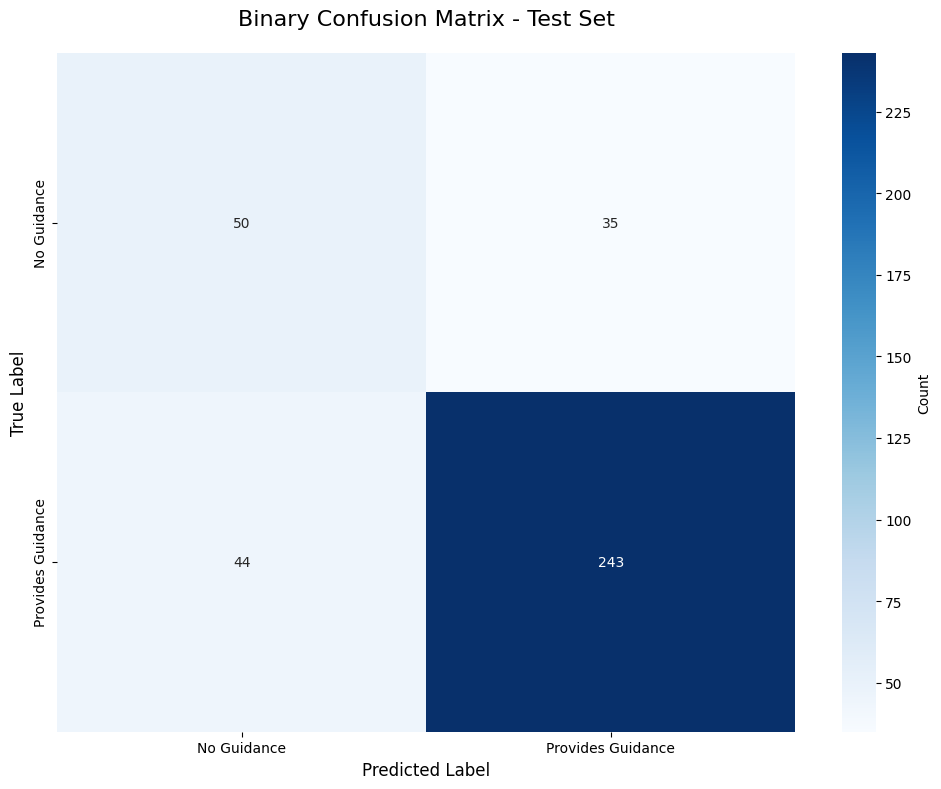

In [24]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    f1_score, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("BINARY CLASSIFICATION: PROVIDES GUIDANCE vs NO GUIDANCE")
print("="*80)
print("Converting 3-class problem to binary:")
print("  'Yes' + 'To some extent' → 'Provides Guidance' (Label 1)")
print("  'No' → 'No Guidance' (Label 0)")
print("="*80)

# ==================== STEP 1: CONVERT LABELS TO BINARY ====================
print("\n[STEP 1/8] Converting dataset labels to binary...")

def convert_to_binary(dataset):
    """
    Convert 3-class labels to binary:
    - Original: 0=Yes, 1=To some extent, 2=No
    - New: 1=Provides Guidance (0 or 1), 0=No Guidance (2)
    """
    binary_labels = []
    
    # Iterate through the dataset by index
    for idx in range(len(dataset)):
        item = dataset[idx]
        label = item['labels']  # Get the label from the item
        
        if label in [0, 1]:  # Yes or To some extent
            binary_labels.append(1)  # Provides Guidance
        else:  # label == 2 (No)
            binary_labels.append(0)  # No Guidance
    
    return binary_labels

# Convert all datasets
print("Converting train_dataset...")
train_binary_labels = convert_to_binary(train_dataset)

print("Converting val_dataset...")
val_binary_labels = convert_to_binary(val_dataset)

print("Converting dev_dataset (test)...")
dev_binary_labels = convert_to_binary(dev_dataset)

# Now create new dataset instances with binary labels
# We need to create a modified version of your MistakeIdentificationDataset class

class BinaryMistakeIdentificationDataset(torch.utils.data.Dataset):
    """Modified dataset for binary classification"""
    def __init__(self, data, tokenizer, max_length=512, binary_labels=None):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.binary_labels = binary_labels  # Pre-converted binary labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Same text formatting as your original
        text = f"{row['conversation_history']} [SEP] Tutor name : {row['model']} [SEP] Tutor Response : {row['tutor_response']}"
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.binary_labels[idx], dtype=torch.long)
        }

# Create binary datasets
print("\nCreating binary dataset objects...")

train_dataset_binary = BinaryMistakeIdentificationDataset(
    data=train_dataset.data,  # Access the underlying DataFrame
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=train_binary_labels
)

val_dataset_binary = BinaryMistakeIdentificationDataset(
    data=val_dataset.data,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=val_binary_labels
)

dev_dataset_binary = BinaryMistakeIdentificationDataset(
    data=dev_dataset.data,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=dev_binary_labels
)

print("✓ Binary datasets created!")

# Show distribution
train_dist = pd.Series(train_binary_labels).value_counts()
val_dist = pd.Series(val_binary_labels).value_counts()
test_dist = pd.Series(dev_binary_labels).value_counts()

print("\n✓ Conversion complete!")
print("\n📊 NEW LABEL DISTRIBUTION:")
print(f"\n{'Dataset':<15} {'No Guidance (0)':<20} {'Provides Guidance (1)':<25} {'Total':<10}")
print("-" * 75)
print(f"{'Train':<15} {train_dist.get(0, 0):<20} {train_dist.get(1, 0):<25} {len(train_binary_labels):<10}")
print(f"{'Validation':<15} {val_dist.get(0, 0):<20} {val_dist.get(1, 0):<25} {len(val_binary_labels):<10}")
print(f"{'Test':<15} {test_dist.get(0, 0):<20} {test_dist.get(1, 0):<25} {len(dev_binary_labels):<10}")

guidance_ratio_train = train_dist.get(1, 0) / len(train_binary_labels) * 100
guidance_ratio_test = test_dist.get(1, 0) / len(dev_binary_labels) * 100
print(f"\n  Train: {guidance_ratio_train:.1f}% Provides Guidance")
print(f"  Test:  {guidance_ratio_test:.1f}% Provides Guidance")

# ==================== STEP 2: COMPUTE CLASS WEIGHTS ====================
print("\n[STEP 2/8] Computing class weights for imbalanced data...")

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_binary_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

print(f"✓ Class weights computed:")
print(f"  No Guidance (0): {class_weights[0]:.4f}")
print(f"  Provides Guidance (1): {class_weights[1]:.4f}")

# ==================== STEP 3: SETUP MODEL CONFIGURATION ====================
print("\n[STEP 3/8] Setting up binary classification model...")

MODEL_NAME = "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Binary label mapping
id2label_binary = {0: "No Guidance", 1: "Provides Guidance"}
label2id_binary = {"No Guidance": 0, "Provides Guidance": 1}

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Trial 14's EXACT hyperparameters (proven best)
TRIAL_14_CONFIG = {
    'learning_rate': 9.418928676027655e-06,
    'weight_decay': 0.04978596830066745,
    'num_train_epochs': 13,
    'hidden_dropout_prob': 0.07457209457732518,
    'attention_dropout_prob': 0.2492832837143733,
    'label_smoothing_factor': 0.11870170686915271,
    'num_layers_to_freeze': 5
}

print("✓ Using Trial 14's proven hyperparameters")
print(f"  Learning rate: {TRIAL_14_CONFIG['learning_rate']:.10f}")
print(f"  Hidden dropout: {TRIAL_14_CONFIG['hidden_dropout_prob']:.4f}")
print(f"  Attention dropout: {TRIAL_14_CONFIG['attention_dropout_prob']:.4f}")
print(f"  Frozen layers: {TRIAL_14_CONFIG['num_layers_to_freeze']}")

# ==================== STEP 4: INITIALIZE MODEL ====================
print("\n[STEP 4/8] Initializing DeBERTa v3 Base for binary classification...")

model_binary = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,  # Binary classification
    id2label=id2label_binary,
    label2id=label2id_binary,
    hidden_dropout_prob=TRIAL_14_CONFIG['hidden_dropout_prob'],
    attention_probs_dropout_prob=TRIAL_14_CONFIG['attention_dropout_prob']
).to(device)

print("✓ Model initialized")

# Freeze layers (Trial 14 config: freeze 5 layers)
print(f"\n  Freezing {TRIAL_14_CONFIG['num_layers_to_freeze']} layers...")

# Freeze embeddings
for param in model_binary.deberta.embeddings.parameters():
    param.requires_grad = False

# Freeze first 5 encoder layers
for layer_idx in range(TRIAL_14_CONFIG['num_layers_to_freeze']):
    for param in model_binary.deberta.encoder.layer[layer_idx].parameters():
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model_binary.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_binary.parameters())
print(f"  Trainable: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.1f}%)")

# ==================== STEP 5: COMPUTE METRICS ====================
def compute_metrics_binary(pred):
    """Compute comprehensive binary classification metrics"""
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    
    # Per-class metrics
    f1_per_class = f1_score(labels, preds, average=None, zero_division=0)
    precision_per_class = precision_score(labels, preds, average=None, zero_division=0)
    recall_per_class = recall_score(labels, preds, average=None, zero_division=0)
    
    # Binary-specific metrics
    f1_binary = f1_score(labels, preds, pos_label=1)  # F1 for "Provides Guidance"
    precision_binary = precision_score(labels, preds, pos_label=1)
    recall_binary = recall_score(labels, preds, pos_label=1)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_binary": f1_binary,  # F1 for positive class
        "precision_binary": precision_binary,
        "recall_binary": recall_binary,
        "f1_no_guidance": f1_per_class[0],
        "f1_provides_guidance": f1_per_class[1],
        "precision_no_guidance": precision_per_class[0],
        "precision_provides_guidance": precision_per_class[1],
        "recall_no_guidance": recall_per_class[0],
        "recall_provides_guidance": recall_per_class[1]
    }

# ==================== STEP 6: TRAINING SETUP ====================
print("\n[STEP 5/8] Configuring training arguments...")

training_args_binary = TrainingArguments(
    output_dir="./binary_trial14_model",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=TRIAL_14_CONFIG['learning_rate'],
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=TRIAL_14_CONFIG['num_train_epochs'],
    weight_decay=TRIAL_14_CONFIG['weight_decay'],
    warmup_ratio=0.09,
    lr_scheduler_type="cosine",
    gradient_accumulation_steps=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./binary_trial14_logs",
    logging_strategy="steps",
    label_smoothing_factor=TRIAL_14_CONFIG['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=3
)

print("✓ Training configuration set")

# ==================== WEIGHTED LOSS TRAINER ====================
# ==================== WEIGHTED LOSS TRAINER ====================
from torch import nn

class BinaryWeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Compute weighted cross-entropy loss
        Added num_items_in_batch parameter for compatibility with newer transformers versions
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Weighted cross entropy loss
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

# ==================== STEP 7: INITIALIZE TRAINER ====================
print("\n[STEP 6/8] Initializing Trainer with weighted loss...")

trainer_binary = BinaryWeightedTrainer(
    model=model_binary,
    args=training_args_binary,
    train_dataset=train_dataset_binary,
    eval_dataset=val_dataset_binary,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_binary,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=4,
            early_stopping_threshold=0.001
        )
    ],
    class_weights=class_weights_tensor
)

print("✓ Trainer initialized with weighted CE loss")

# ==================== STEP 8: TRAIN MODEL ====================
print("\n" + "="*80)
print("STARTING BINARY CLASSIFICATION TRAINING")
print("="*80)
print("⏳ Expected time: 15-25 minutes")
print("🎯 Target: F1 > 0.72 (vs 0.5647 for 3-class)")
print("="*80)

train_result = trainer_binary.train()

print("\n✓ Training completed!")

# ==================== STEP 9: EVALUATE ON VALIDATION ====================
print("\n[STEP 7/8] Evaluating on validation set...")
val_results_binary = trainer_binary.evaluate(eval_dataset=val_dataset_binary)

print("\n" + "="*80)
print("VALIDATION SET RESULTS - BINARY MODEL")
print("="*80)
print(f"\n📊 OVERALL METRICS")
print(f"  Accuracy:           {val_results_binary['eval_accuracy']:.4f}")
print(f"  F1 Macro:           {val_results_binary['eval_f1_macro']:.4f}")
print(f"  F1 Weighted:        {val_results_binary['eval_f1_weighted']:.4f}")
print(f"  F1 Binary (Pos):    {val_results_binary['eval_f1_binary']:.4f}")
print(f"  Loss:               {val_results_binary['eval_loss']:.4f}")

print(f"\n📈 PER-CLASS METRICS")
print(f"  No Guidance:")
print(f"    F1:        {val_results_binary['eval_f1_no_guidance']:.4f}")
print(f"    Precision: {val_results_binary['eval_precision_no_guidance']:.4f}")
print(f"    Recall:    {val_results_binary['eval_recall_no_guidance']:.4f}")
print(f"\n  Provides Guidance:")
print(f"    F1:        {val_results_binary['eval_f1_provides_guidance']:.4f}")
print(f"    Precision: {val_results_binary['eval_precision_provides_guidance']:.4f}")
print(f"    Recall:    {val_results_binary['eval_recall_provides_guidance']:.4f}")

# ==================== STEP 10: EVALUATE ON TEST ====================
print("\n[STEP 8/8] Evaluating on TEST set...")
test_results_binary = trainer_binary.evaluate(eval_dataset=dev_dataset_binary)

print("\n" + "="*80)
print("TEST SET RESULTS - BINARY MODEL")
print("="*80)
print(f"\n📊 OVERALL METRICS")
print(f"  Accuracy:           {test_results_binary['eval_accuracy']:.4f}")
print(f"  F1 Macro:           {test_results_binary['eval_f1_macro']:.4f}")
print(f"  F1 Weighted:        {test_results_binary['eval_f1_weighted']:.4f}")
print(f"  F1 Binary (Pos):    {test_results_binary['eval_f1_binary']:.4f}")
print(f"  Loss:               {test_results_binary['eval_loss']:.4f}")

print(f"\n📈 PER-CLASS METRICS")
print(f"  No Guidance:")
print(f"    F1:        {test_results_binary['eval_f1_no_guidance']:.4f}")
print(f"    Precision: {test_results_binary['eval_precision_no_guidance']:.4f}")
print(f"    Recall:    {test_results_binary['eval_recall_no_guidance']:.4f}")
print(f"\n  Provides Guidance:")
print(f"    F1:        {test_results_binary['eval_f1_provides_guidance']:.4f}")
print(f"    Precision: {test_results_binary['eval_precision_provides_guidance']:.4f}")
print(f"    Recall:    {test_results_binary['eval_recall_provides_guidance']:.4f}")

# ==================== COMPARISON WITH 3-CLASS ====================
print("\n" + "="*80)
print("COMPARISON: 3-CLASS vs BINARY")
print("="*80)

print("\n📊 TEST SET PERFORMANCE")
print(f"{'Metric':<25} {'3-Class (Trial 14)':<20} {'Binary':<20} {'Improvement':<15}")
print("-" * 85)
print(f"{'F1 Macro':<25} {0.5647:<20.4f} {test_results_binary['eval_f1_macro']:<20.4f} {(test_results_binary['eval_f1_macro']-0.5647)*100:>+12.2f}%")
print(f"{'Accuracy':<25} {0.6129:<20.4f} {test_results_binary['eval_accuracy']:<20.4f} {(test_results_binary['eval_accuracy']-0.6129)*100:>+12.2f}%")
print(f"{'F1 Weighted':<25} {0.6137:<20.4f} {test_results_binary['eval_f1_weighted']:<20.4f} {(test_results_binary['eval_f1_weighted']-0.6137)*100:>+12.2f}%")

improvement = test_results_binary['eval_f1_macro'] - 0.5647
print(f"\n{'='*85}")
if improvement > 0.10:
    print(f"🎉 MASSIVE SUCCESS! F1 improved by {improvement*100:.2f} percentage points!")
    print(f"   Binary classification is CLEARLY superior")
elif improvement > 0.05:
    print(f"✅ SIGNIFICANT IMPROVEMENT! F1 increased by {improvement*100:.2f} percentage points")
    print(f"   Binary task is much more suitable")
elif improvement > 0.02:
    print(f"✓ Solid improvement of {improvement*100:.2f} percentage points")
    print(f"   Binary is better but gap is smaller than expected")
elif improvement > 0:
    print(f"→ Marginal improvement of {improvement*100:.2f} percentage points")
    print(f"   Binary is slightly better")
else:
    print(f"⚠️  F1 changed by {improvement*100:+.2f} percentage points")
    print(f"   Investigate why binary didn't improve as expected")

# ==================== CONFUSION MATRIX ====================
print("\n" + "="*80)
print("GENERATING CONFUSION MATRIX")
print("="*80)

predictions = trainer_binary.predict(dev_dataset_binary)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Confusion matrix
cm_binary = confusion_matrix(true_labels, pred_labels)

print("\n📊 CONFUSION MATRIX - BINARY MODEL")
print(f"\n{'':>25} {'Predicted: No':<20} {'Predicted: Guidance':<20}")
print("-" * 70)
print(f"{'True: No Guidance':<25} {cm_binary[0][0]:<20} {cm_binary[0][1]:<20}")
print(f"{'True: Provides Guidance':<25} {cm_binary[1][0]:<20} {cm_binary[1][1]:<20}")

# Calculate percentages
cm_binary_pct = cm_binary.astype('float') / cm_binary.sum(axis=1)[:, np.newaxis] * 100

print("\n📊 CONFUSION MATRIX - PERCENTAGES")
print(f"\n{'':>25} {'Predicted: No':<20} {'Predicted: Guidance':<20}")
print("-" * 70)
print(f"{'True: No Guidance':<25} {cm_binary_pct[0][0]:<19.1f}% {cm_binary_pct[0][1]:<19.1f}%")
print(f"{'True: Provides Guidance':<25} {cm_binary_pct[1][0]:<19.1f}% {cm_binary_pct[1][1]:<19.1f}%")

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_binary,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Guidance', 'Provides Guidance'],
    yticklabels=['No Guidance', 'Provides Guidance'],
    cbar_kws={'label': 'Count'}
)
plt.title('Binary Confusion Matrix - Test Set', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('./binary_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrix saved: binary_confusion_matrix.png")

# ==================== DETAILED CLASSIFICATION REPORT ====================
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(
    true_labels,
    pred_labels,
    target_names=['No Guidance', 'Provides Guidance'],
    digits=4
))

# ==================== SAVE MODEL ====================
print("\n" + "="*80)
print("SAVING BINARY MODEL")
print("="*80)

trainer_binary.save_model("./binary_best_model")
tokenizer.save_pretrained("./binary_best_model")

print("✓ Model saved to: ./binary_best_model")
print("✓ Tokenizer saved")

# Save results
import json
results_dict = {
    'model': 'Binary DeBERTa v3 Base (Trial 14 config)',
    'task': 'Provides Guidance vs No Guidance',
    'test_size': len(dev_dataset_binary),
    'val_results': {k.replace('eval_', ''): v for k, v in val_results_binary.items()},
    'test_results': {k.replace('eval_', ''): v for k, v in test_results_binary.items()},
    'comparison_3class': {
        'original_f1': 0.5647,
        'binary_f1': test_results_binary['eval_f1_macro'],
        'improvement': test_results_binary['eval_f1_macro'] - 0.5647
    }
}

with open('./binary_model_results.json', 'w') as f:
    json.dump(results_dict, f, indent=4)
print("✓ Results saved: binary_model_results.json")

# ==================== FINAL SUMMARY ====================
print("\n" + "="*80)
print("🎯 FINAL SUMMARY")
print("="*80)

print(f"\n✅ COMPLETED SUCCESSFULLY")
print(f"\n📊 Key Metrics:")
print(f"   Test F1 Macro:  {test_results_binary['eval_f1_macro']:.4f} (was 0.5647)")
print(f"   Test Accuracy:  {test_results_binary['eval_accuracy']:.4f} (was 0.6129)")
print(f"   Improvement:    {(test_results_binary['eval_f1_macro']-0.5647)*100:+.2f} percentage points")

print(f"\n🎯 Per-Class Performance:")
print(f"   No Guidance:        F1 = {test_results_binary['eval_f1_no_guidance']:.4f}")
print(f"   Provides Guidance:  F1 = {test_results_binary['eval_f1_provides_guidance']:.4f}")

print(f"\n💾 Saved Files:")
print(f"   - Model: ./binary_best_model/")
print(f"   - Results: ./binary_model_results.json")
print(f"   - Confusion Matrix: ./binary_confusion_matrix.png")

print(f"\n📈 Next Steps:")
if test_results_binary['eval_f1_macro'] > 0.72:
    print("   ✓ EXCELLENT! Deploy this model")
    print("   ✓ F1 > 0.72 is production-ready for most use cases")
elif test_results_binary['eval_f1_macro'] > 0.65:
    print("   ✓ GOOD! Consider using this model")
    print("   → Could try input format experiments for further gains")
elif test_results_binary['eval_f1_macro'] > 0.60:
    print("   → Decent improvement but room for more")
    print("   → Try different input format: 'Student last response [SEP] Tutor response'")
else:
    print("   ⚠️ Less improvement than expected")
    print("   → Review confusion matrix to understand errors")
    print("   → Check if 'No Guidance' examples are mislabeled")

print("\n" + "="*80)
print("BINARY CLASSIFICATION PIPELINE COMPLETE! 🎉")
print("="*80)

## Heirarachical 3 class

HIERARCHICAL CLASSIFICATION - TWO-STAGE APPROACH
Stage 1: Binary - 'Provides Guidance' vs 'No Guidance'
Stage 2: Binary - 'Yes' (Explicit) vs 'To some extent' (Implicit)

STAGE 1: BINARY CLASSIFIER - GUIDANCE vs NO GUIDANCE

[STEP 1.1] Converting labels for Stage 1...
✓ Stage 1 labels created

  Train: 396 No Guidance, 1336 Provides Guidance
  Test:  85 No Guidance, 287 Provides Guidance

[STEP 1.2] Computing class weights for Stage 1...
  Class weights: No=2.187, Guidance=0.648

[STEP 1.3] Initializing Stage 1 model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


✓ Stage 1 model initialized (5 layers frozen)

[STEP 1.4] Training Stage 1 model...
⏳ This will take 15-25 minutes...


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
50,0.704700,0.691122,0.228495,0.185996,0.084998,0.114247,0.500000
100,0.681800,0.662188,0.725806,0.611150,0.725806,0.611150,0.611150
150,0.656000,0.595808,0.822581,0.752450,0.823997,0.748600,0.756671
200,0.612500,0.585930,0.620968,0.599037,0.649957,0.642209,0.700533
250,0.541200,0.491611,0.862903,0.788124,0.856474,0.821598,0.766243
300,0.550300,0.526526,0.661290,0.634908,0.688201,0.662755,0.730805
350,0.484700,0.448429,0.849462,0.791613,0.851233,0.785186,0.798934
400,0.491600,0.439069,0.862903,0.801413,0.861418,0.808305,0.795224
450,0.407600,0.434748,0.844086,0.792115,0.848557,0.778086,0.812011
500,0.391800,0.456372,0.827957,0.773817,0.833906,0.758801,0.797418


✓ Stage 1 training complete!

[STEP 1.5] Evaluating Stage 1 on test set...


...

✓ Stage 2 model initialized (5 layers frozen)

[STEP 2.4] Training Stage 2 model...
⏳ This will take 15-25 minutes...


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
50,0.691700,0.691293,0.728223,0.512160,0.664875,0.599532,0.533144
100,0.687200,0.692052,0.411150,0.411121,0.409191,0.532737,0.532178
150,0.677800,0.697220,0.428571,0.428509,0.431319,0.542965,0.544026
200,0.663100,0.685063,0.721254,0.593254,0.700583,0.618186,0.587335
250,0.640200,0.656081,0.686411,0.612999,0.692284,0.609800,0.618359
300,0.630100,0.660789,0.613240,0.580658,0.635641,0.593463,0.619107
350,0.580100,0.690680,0.613240,0.577005,0.635240,0.587352,0.610688
400,0.587500,0.654022,0.630662,0.583032,0.649321,0.585945,0.605700
450,0.555300,0.671555,0.738676,0.607301,0.714142,0.646051,0.599183


✓ Stage 2 training complete!

[STEP 2.5] Evaluating Stage 2 on test set...



STAGE 2 TEST RESULTS
  Accuracy:    0.6551
  F1 Macro:    0.5904
  Precision:   0.5881
  Recall:      0.6012

✓ Stage 2 model saved to: ./hierarchical_stage2_best

📊 Stage 2 Confusion Matrix:
  True Implicit, Pred Implicit: 37
  True Implicit, Pred Explicit: 39
  True Explicit, Pred Implicit: 60
  True Explicit, Pred Explicit: 151

COMBINING STAGE 1 & STAGE 2 FOR FINAL 3-CLASS PREDICTIONS

[STEP 3.1] Running Stage 2 predictions on Stage 1 'Guidance' predictions...
✓ Stage 1 predicted 283 examples as 'Provides Guidance'
  (Out of 372 total test examples)

[STEP 3.2] Running Stage 2 model on 283 examples...


✓ Stage 2 predictions complete
  Predicted Explicit (Yes): 182
  Predicted Implicit (To some extent): 101

[STEP 3.3] Combining predictions into final 3-class labels...
✓ Combined predictions created
  Final predictions - Yes: 182, To some extent: 101, No: 89

FINAL HIERARCHICAL 3-CLASS RESULTS

📊 OVERALL METRICS
  Accuracy:     0.5565
  F1 Macro:     0.5241
  F1 Weighted:  0.5657

📈 PER-CLASS F1 SCORES
  Yes (Explicit):            0.6361
  To some extent (Implicit): 0.3729
  No:                        0.5632

🎯 PER-CLASS PRECISION
  Yes (Explicit):            0.6868
  To some extent (Implicit): 0.3267
  No:                        0.5506

📢 PER-CLASS RECALL
  Yes (Explicit):            0.5924
  To some extent (Implicit): 0.4342
  No:                        0.5765

📊 FINAL 3-CLASS CONFUSION MATRIX

                     Pred: Yes       Pred: To some   Pred: No       
----------------------------------------------------------------------
True: Yes            125             56            

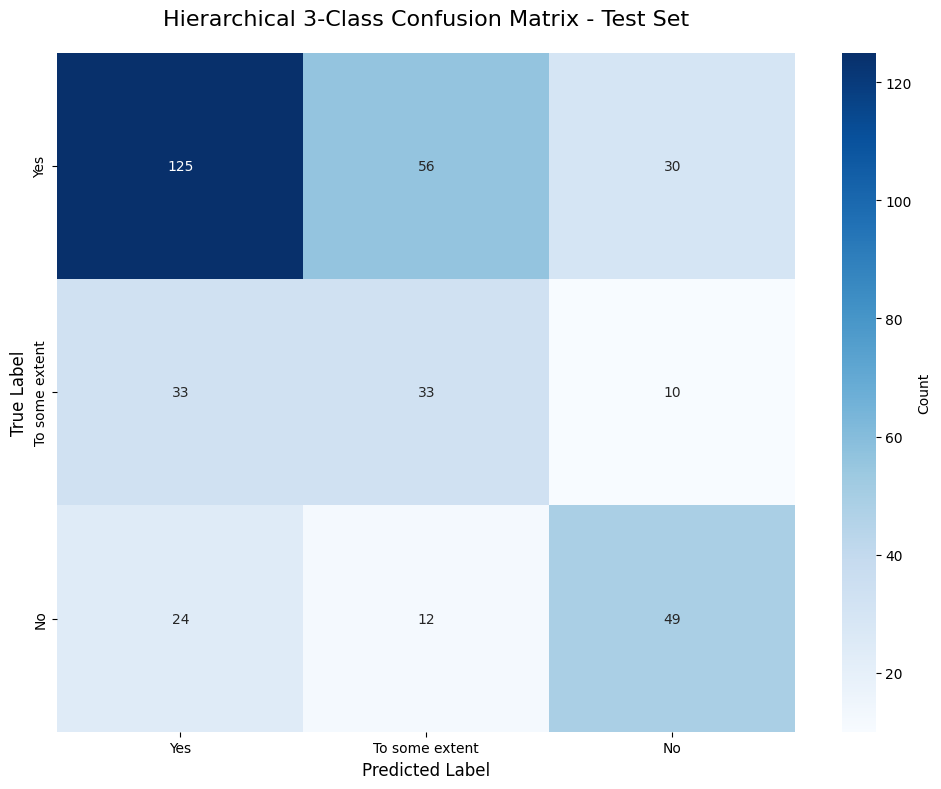

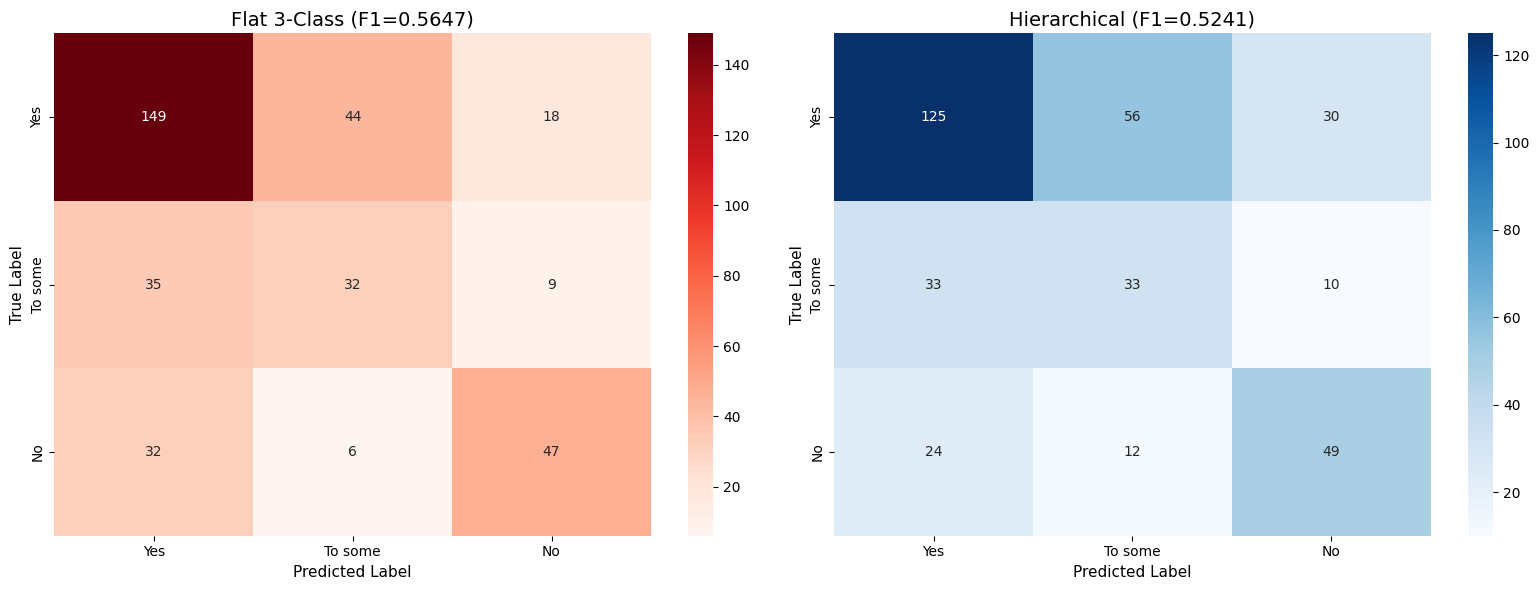

In [26]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    f1_score, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn

print("="*80)
print("HIERARCHICAL CLASSIFICATION - TWO-STAGE APPROACH")
print("="*80)
print("Stage 1: Binary - 'Provides Guidance' vs 'No Guidance'")
print("Stage 2: Binary - 'Yes' (Explicit) vs 'To some extent' (Implicit)")
print("="*80)

# ==================== CONFIGURATION ====================
MODEL_NAME = "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Trial 14's proven hyperparameters
TRIAL_14_CONFIG = {
    'learning_rate': 9.418928676027655e-06,
    'weight_decay': 0.04978596830066745,
    'num_train_epochs': 13,
    'hidden_dropout_prob': 0.07457209457732518,
    'attention_dropout_prob': 0.2492832837143733,
    'label_smoothing_factor': 0.11870170686915271,
    'num_layers_to_freeze': 5
}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ==================== CUSTOM DATASET CLASSES ====================

class BinaryMistakeIdentificationDataset(torch.utils.data.Dataset):
    """Dataset for binary classification"""
    def __init__(self, data, tokenizer, max_length=512, binary_labels=None):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.binary_labels = binary_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = f"{row['conversation_history']} [SEP] Tutor name : {row['model']} [SEP] Tutor Response : {row['tutor_response']}"
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.binary_labels[idx], dtype=torch.long)
        }

class WeightedCETrainer(Trainer):
    """Trainer with weighted cross-entropy loss"""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

def compute_metrics_binary(pred):
    """Compute binary classification metrics"""
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision": precision,
        "recall": recall
    }

# ==================== STAGE 1: GUIDANCE vs NO GUIDANCE ====================
print("\n" + "="*80)
print("STAGE 1: BINARY CLASSIFIER - GUIDANCE vs NO GUIDANCE")
print("="*80)

print("\n[STEP 1.1] Converting labels for Stage 1...")

def convert_to_stage1_labels(dataset):
    """Convert to binary: 0=No Guidance (was 2), 1=Provides Guidance (was 0 or 1)"""
    stage1_labels = []
    for idx in range(len(dataset)):
        item = dataset[idx]
        original_label = item['labels']
        
        if original_label in [0, 1]:  # Yes or To some extent
            stage1_labels.append(1)  # Provides Guidance
        else:  # original_label == 2 (No)
            stage1_labels.append(0)  # No Guidance
    
    return stage1_labels

# Convert all datasets for Stage 1
train_stage1_labels = convert_to_stage1_labels(train_dataset)
val_stage1_labels = convert_to_stage1_labels(val_dataset)
test_stage1_labels = convert_to_stage1_labels(dev_dataset)

print("✓ Stage 1 labels created")

# Show distribution
train_s1_dist = pd.Series(train_stage1_labels).value_counts()
test_s1_dist = pd.Series(test_stage1_labels).value_counts()
print(f"\n  Train: {train_s1_dist.get(0, 0)} No Guidance, {train_s1_dist.get(1, 0)} Provides Guidance")
print(f"  Test:  {test_s1_dist.get(0, 0)} No Guidance, {test_s1_dist.get(1, 0)} Provides Guidance")

# Create Stage 1 datasets
train_dataset_stage1 = BinaryMistakeIdentificationDataset(
    data=train_dataset.data,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=train_stage1_labels
)

val_dataset_stage1 = BinaryMistakeIdentificationDataset(
    data=val_dataset.data,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=val_stage1_labels
)

test_dataset_stage1 = BinaryMistakeIdentificationDataset(
    data=dev_dataset.data,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=test_stage1_labels
)

# Compute class weights for Stage 1
print("\n[STEP 1.2] Computing class weights for Stage 1...")
class_weights_s1 = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_stage1_labels
)
class_weights_s1_tensor = torch.tensor(class_weights_s1, dtype=torch.float).to(device)
print(f"  Class weights: No={class_weights_s1[0]:.3f}, Guidance={class_weights_s1[1]:.3f}")

# Initialize Stage 1 model
print("\n[STEP 1.3] Initializing Stage 1 model...")
id2label_s1 = {0: "No Guidance", 1: "Provides Guidance"}
label2id_s1 = {"No Guidance": 0, "Provides Guidance": 1}

model_stage1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label_s1,
    label2id=label2id_s1,
    hidden_dropout_prob=TRIAL_14_CONFIG['hidden_dropout_prob'],
    attention_probs_dropout_prob=TRIAL_14_CONFIG['attention_dropout_prob']
).to(device)

# Freeze layers
for param in model_stage1.deberta.embeddings.parameters():
    param.requires_grad = False
for layer_idx in range(TRIAL_14_CONFIG['num_layers_to_freeze']):
    for param in model_stage1.deberta.encoder.layer[layer_idx].parameters():
        param.requires_grad = False

print("✓ Stage 1 model initialized (5 layers frozen)")

# Training arguments for Stage 1
training_args_s1 = TrainingArguments(
    output_dir="./hierarchical_stage1",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=TRIAL_14_CONFIG['learning_rate'],
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=TRIAL_14_CONFIG['num_train_epochs'],
    weight_decay=TRIAL_14_CONFIG['weight_decay'],
    warmup_ratio=0.09,
    lr_scheduler_type="cosine",
    gradient_accumulation_steps=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./hierarchical_stage1_logs",
    label_smoothing_factor=TRIAL_14_CONFIG['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=2
)

# Trainer for Stage 1
trainer_stage1 = WeightedCETrainer(
    model=model_stage1,
    args=training_args_s1,
    train_dataset=train_dataset_stage1,
    eval_dataset=val_dataset_stage1,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_binary,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
    class_weights=class_weights_s1_tensor
)

# Train Stage 1
print("\n[STEP 1.4] Training Stage 1 model...")
print("⏳ This will take 15-25 minutes...")
trainer_stage1.train()
print("✓ Stage 1 training complete!")

# Evaluate Stage 1
print("\n[STEP 1.5] Evaluating Stage 1 on test set...")
stage1_test_results = trainer_stage1.evaluate(eval_dataset=test_dataset_stage1)

print("\n" + "="*80)
print("STAGE 1 TEST RESULTS")
print("="*80)
print(f"  Accuracy:    {stage1_test_results['eval_accuracy']:.4f}")
print(f"  F1 Macro:    {stage1_test_results['eval_f1_macro']:.4f}")
print(f"  Precision:   {stage1_test_results['eval_precision']:.4f}")
print(f"  Recall:      {stage1_test_results['eval_recall']:.4f}")

# Save Stage 1 model
trainer_stage1.save_model("./hierarchical_stage1_best")
print("\n✓ Stage 1 model saved to: ./hierarchical_stage1_best")

# Get Stage 1 predictions on test set
stage1_predictions = trainer_stage1.predict(test_dataset_stage1)
stage1_pred_labels = np.argmax(stage1_predictions.predictions, axis=1)
stage1_true_labels = stage1_predictions.label_ids

# Confusion matrix for Stage 1
cm_stage1 = confusion_matrix(stage1_true_labels, stage1_pred_labels)
print("\n📊 Stage 1 Confusion Matrix:")
print(f"  True No, Pred No: {cm_stage1[0][0]}")
print(f"  True No, Pred Guidance: {cm_stage1[0][1]}")
print(f"  True Guidance, Pred No: {cm_stage1[1][0]}")
print(f"  True Guidance, Pred Guidance: {cm_stage1[1][1]}")

# ==================== STAGE 2: EXPLICIT vs IMPLICIT GUIDANCE ====================
print("\n" + "="*80)
print("STAGE 2: BINARY CLASSIFIER - EXPLICIT vs IMPLICIT GUIDANCE")
print("="*80)
print("Training only on examples where Stage 1 predicts 'Provides Guidance'")

print("\n[STEP 2.1] Filtering data for Stage 2...")

def create_stage2_data(dataset, stage1_predictions=None):
    """
    Create Stage 2 dataset - only examples that are "Guidance" (original label 0 or 1)
    Returns: filtered data, filtered labels (0=To some extent, 1=Yes)
    """
    stage2_data = []
    stage2_labels = []
    stage2_indices = []
    
    for idx in range(len(dataset)):
        item = dataset[idx]
        original_label = item['labels']
        
        # Only include if original label was 0 (Yes) or 1 (To some extent)
        if original_label in [0, 1]:
            stage2_data.append(idx)
            # Convert: 0 (Yes) → 1 (Explicit), 1 (To some extent) → 0 (Implicit)
            stage2_labels.append(1 if original_label == 0 else 0)
            stage2_indices.append(idx)
    
    return stage2_data, stage2_labels, stage2_indices

# Create Stage 2 filtered datasets
train_s2_indices, train_s2_labels, _ = create_stage2_data(train_dataset)
val_s2_indices, val_s2_labels, _ = create_stage2_data(val_dataset)
test_s2_indices, test_s2_labels, _ = create_stage2_data(dev_dataset)

print(f"✓ Stage 2 data filtered")
print(f"  Train: {len(train_s2_labels)} guidance examples (from {len(train_dataset)})")
print(f"  Val:   {len(val_s2_labels)} guidance examples (from {len(val_dataset)})")
print(f"  Test:  {len(test_s2_labels)} guidance examples (from {len(dev_dataset)})")

# Show Stage 2 distribution
train_s2_dist = pd.Series(train_s2_labels).value_counts()
test_s2_dist = pd.Series(test_s2_labels).value_counts()
print(f"\n  Train: {train_s2_dist.get(0, 0)} Implicit, {train_s2_dist.get(1, 0)} Explicit")
print(f"  Test:  {test_s2_dist.get(0, 0)} Implicit, {test_s2_dist.get(1, 0)} Explicit")

# Create filtered dataframes
train_df_s2 = train_dataset.data.iloc[train_s2_indices].reset_index(drop=True)
val_df_s2 = val_dataset.data.iloc[val_s2_indices].reset_index(drop=True)
test_df_s2 = dev_dataset.data.iloc[test_s2_indices].reset_index(drop=True)

# Create Stage 2 datasets
train_dataset_stage2 = BinaryMistakeIdentificationDataset(
    data=train_df_s2,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=train_s2_labels
)

val_dataset_stage2 = BinaryMistakeIdentificationDataset(
    data=val_df_s2,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=val_s2_labels
)

test_dataset_stage2 = BinaryMistakeIdentificationDataset(
    data=test_df_s2,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=test_s2_labels
)

# Compute class weights for Stage 2
print("\n[STEP 2.2] Computing class weights for Stage 2...")
class_weights_s2 = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_s2_labels
)
class_weights_s2_tensor = torch.tensor(class_weights_s2, dtype=torch.float).to(device)
print(f"  Class weights: Implicit={class_weights_s2[0]:.3f}, Explicit={class_weights_s2[1]:.3f}")

# Initialize Stage 2 model
print("\n[STEP 2.3] Initializing Stage 2 model...")
id2label_s2 = {0: "Implicit Guidance", 1: "Explicit Guidance"}
label2id_s2 = {"Implicit Guidance": 0, "Explicit Guidance": 1}

model_stage2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label_s2,
    label2id=label2id_s2,
    hidden_dropout_prob=TRIAL_14_CONFIG['hidden_dropout_prob'],
    attention_probs_dropout_prob=TRIAL_14_CONFIG['attention_dropout_prob']
).to(device)

# Freeze layers
for param in model_stage2.deberta.embeddings.parameters():
    param.requires_grad = False
for layer_idx in range(TRIAL_14_CONFIG['num_layers_to_freeze']):
    for param in model_stage2.deberta.encoder.layer[layer_idx].parameters():
        param.requires_grad = False

print("✓ Stage 2 model initialized (5 layers frozen)")

# Training arguments for Stage 2
training_args_s2 = TrainingArguments(
    output_dir="./hierarchical_stage2",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=TRIAL_14_CONFIG['learning_rate'],
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=TRIAL_14_CONFIG['num_train_epochs'],
    weight_decay=TRIAL_14_CONFIG['weight_decay'],
    warmup_ratio=0.09,
    lr_scheduler_type="cosine",
    gradient_accumulation_steps=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./hierarchical_stage2_logs",
    label_smoothing_factor=TRIAL_14_CONFIG['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=2
)

# Trainer for Stage 2
trainer_stage2 = WeightedCETrainer(
    model=model_stage2,
    args=training_args_s2,
    train_dataset=train_dataset_stage2,
    eval_dataset=val_dataset_stage2,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_binary,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
    class_weights=class_weights_s2_tensor
)

# Train Stage 2
print("\n[STEP 2.4] Training Stage 2 model...")
print("⏳ This will take 15-25 minutes...")
trainer_stage2.train()
print("✓ Stage 2 training complete!")

# Evaluate Stage 2
print("\n[STEP 2.5] Evaluating Stage 2 on test set...")
stage2_test_results = trainer_stage2.evaluate(eval_dataset=test_dataset_stage2)

print("\n" + "="*80)
print("STAGE 2 TEST RESULTS")
print("="*80)
print(f"  Accuracy:    {stage2_test_results['eval_accuracy']:.4f}")
print(f"  F1 Macro:    {stage2_test_results['eval_f1_macro']:.4f}")
print(f"  Precision:   {stage2_test_results['eval_precision']:.4f}")
print(f"  Recall:      {stage2_test_results['eval_recall']:.4f}")

# Save Stage 2 model
trainer_stage2.save_model("./hierarchical_stage2_best")
print("\n✓ Stage 2 model saved to: ./hierarchical_stage2_best")

# Get Stage 2 predictions
stage2_predictions = trainer_stage2.predict(test_dataset_stage2)
stage2_pred_labels = np.argmax(stage2_predictions.predictions, axis=1)
stage2_true_labels = stage2_predictions.label_ids

# Confusion matrix for Stage 2
cm_stage2 = confusion_matrix(stage2_true_labels, stage2_pred_labels)
print("\n📊 Stage 2 Confusion Matrix:")
print(f"  True Implicit, Pred Implicit: {cm_stage2[0][0]}")
print(f"  True Implicit, Pred Explicit: {cm_stage2[0][1]}")
print(f"  True Explicit, Pred Implicit: {cm_stage2[1][0]}")
print(f"  True Explicit, Pred Explicit: {cm_stage2[1][1]}")

# ==================== COMBINE PREDICTIONS FOR FINAL 3-CLASS ====================
print("\n" + "="*80)
print("COMBINING STAGE 1 & STAGE 2 FOR FINAL 3-CLASS PREDICTIONS")
print("="*80)

# Get original 3-class labels for full test set
original_test_labels = []
for idx in range(len(dev_dataset)):
    item = dev_dataset[idx]
    original_test_labels.append(item['labels'])

print(f"\n[STEP 3.1] Running Stage 2 predictions on Stage 1 'Guidance' predictions...")

# We need to run Stage 2 on ALL examples that Stage 1 predicts as "Guidance"
# First, identify which test examples Stage 1 predicts as "Guidance"
guidance_indices = []
for idx in range(len(dev_dataset)):
    if stage1_pred_labels[idx] == 1:  # Predicted "Provides Guidance"
        guidance_indices.append(idx)

print(f"✓ Stage 1 predicted {len(guidance_indices)} examples as 'Provides Guidance'")
print(f"  (Out of {len(dev_dataset)} total test examples)")

# Create a dataset with only these examples for Stage 2
guidance_df = dev_dataset.data.iloc[guidance_indices].reset_index(drop=True)

# We don't need true labels for Stage 2 predictions, just placeholder labels
placeholder_labels = [0] * len(guidance_indices)  # Placeholder

guidance_dataset_for_stage2 = BinaryMistakeIdentificationDataset(
    data=guidance_df,
    tokenizer=tokenizer,
    max_length=512,
    binary_labels=placeholder_labels
)

print(f"\n[STEP 3.2] Running Stage 2 model on {len(guidance_indices)} examples...")

# Get Stage 2 predictions for these examples
stage2_guidance_predictions = trainer_stage2.predict(guidance_dataset_for_stage2)
stage2_guidance_pred_labels = np.argmax(stage2_guidance_predictions.predictions, axis=1)

print(f"✓ Stage 2 predictions complete")
print(f"  Predicted Explicit (Yes): {(stage2_guidance_pred_labels == 1).sum()}")
print(f"  Predicted Implicit (To some extent): {(stage2_guidance_pred_labels == 0).sum()}")

# Now combine Stage 1 and Stage 2 predictions
print("\n[STEP 3.3] Combining predictions into final 3-class labels...")

final_predictions = []
guidance_counter = 0

for idx in range(len(dev_dataset)):
    stage1_pred = stage1_pred_labels[idx]
    
    if stage1_pred == 0:  # Predicted "No Guidance"
        final_predictions.append(2)  # Map to "No"
    else:  # Predicted "Provides Guidance"
        # Use Stage 2 prediction for this example
        stage2_pred = stage2_guidance_pred_labels[guidance_counter]
        guidance_counter += 1
        
        if stage2_pred == 1:  # Explicit
            final_predictions.append(0)  # Map to "Yes"
        else:  # Implicit
            final_predictions.append(1)  # Map to "To some extent"

print(f"✓ Combined predictions created")
print(f"  Final predictions - Yes: {final_predictions.count(0)}, "
      f"To some extent: {final_predictions.count(1)}, No: {final_predictions.count(2)}")

# Calculate metrics
final_accuracy = accuracy_score(original_test_labels, final_predictions)
final_f1_macro = f1_score(original_test_labels, final_predictions, average='macro')
final_f1_weighted = f1_score(original_test_labels, final_predictions, average='weighted')

# Per-class F1
final_f1_per_class = f1_score(original_test_labels, final_predictions, average=None, zero_division=0)
final_precision_per_class = precision_score(original_test_labels, final_predictions, average=None, zero_division=0)
final_recall_per_class = recall_score(original_test_labels, final_predictions, average=None, zero_division=0)

print("\n" + "="*80)
print("FINAL HIERARCHICAL 3-CLASS RESULTS")
print("="*80)
print(f"\n📊 OVERALL METRICS")
print(f"  Accuracy:     {final_accuracy:.4f}")
print(f"  F1 Macro:     {final_f1_macro:.4f}")
print(f"  F1 Weighted:  {final_f1_weighted:.4f}")

print(f"\n📈 PER-CLASS F1 SCORES")
print(f"  Yes (Explicit):            {final_f1_per_class[0]:.4f}")
print(f"  To some extent (Implicit): {final_f1_per_class[1]:.4f}")
print(f"  No:                        {final_f1_per_class[2]:.4f}")

print(f"\n🎯 PER-CLASS PRECISION")
print(f"  Yes (Explicit):            {final_precision_per_class[0]:.4f}")
print(f"  To some extent (Implicit): {final_precision_per_class[1]:.4f}")
print(f"  No:                        {final_precision_per_class[2]:.4f}")

print(f"\n📢 PER-CLASS RECALL")
print(f"  Yes (Explicit):            {final_recall_per_class[0]:.4f}")
print(f"  To some extent (Implicit): {final_recall_per_class[1]:.4f}")
print(f"  No:                        {final_recall_per_class[2]:.4f}")

# Final confusion matrix
final_cm = confusion_matrix(original_test_labels, final_predictions)
print("\n📊 FINAL 3-CLASS CONFUSION MATRIX")
print(f"\n{'':>20} {'Pred: Yes':<15} {'Pred: To some':<15} {'Pred: No':<15}")
print("-" * 70)
print(f"{'True: Yes':<20} {final_cm[0][0]:<15} {final_cm[0][1]:<15} {final_cm[0][2]:<15}")
print(f"{'True: To some extent':<20} {final_cm[1][0]:<15} {final_cm[1][1]:<15} {final_cm[1][2]:<15}")
print(f"{'True: No':<20} {final_cm[2][0]:<15} {final_cm[2][1]:<15} {final_cm[2][2]:<15}")

# Confusion matrix percentages
final_cm_pct = final_cm.astype('float') / final_cm.sum(axis=1)[:, np.newaxis] * 100
print("\n📊 CONFUSION MATRIX (Percentages)")
print(f"\n{'':>20} {'Pred: Yes':<15} {'Pred: To some':<15} {'Pred: No':<15}")
print("-" * 70)
print(f"{'True: Yes':<20} {final_cm_pct[0][0]:<14.1f}% {final_cm_pct[0][1]:<14.1f}% {final_cm_pct[0][2]:<14.1f}%")
print(f"{'True: To some extent':<20} {final_cm_pct[1][0]:<14.1f}% {final_cm_pct[1][1]:<14.1f}% {final_cm_pct[1][2]:<14.1f}%")
print(f"{'True: No':<20} {final_cm_pct[2][0]:<14.1f}% {final_cm_pct[2][1]:<14.1f}% {final_cm_pct[2][2]:<14.1f}%")

# ==================== COMPARISON ====================
print("\n" + "="*80)
print("COMPARISON: FLAT 3-CLASS vs HIERARCHICAL")
print("="*80)

print(f"\n{'Metric':<25} {'Flat (Trial 14)':<20} {'Hierarchical':<20} {'Change':<15}")
print("-" * 85)
print(f"{'F1 Macro':<25} {0.5647:<20.4f} {final_f1_macro:<20.4f} {(final_f1_macro-0.5647)*100:>+12.2f}%")
print(f"{'Accuracy':<25} {0.6129:<20.4f} {final_accuracy:<20.4f} {(final_accuracy-0.6129)*100:>+12.2f}%")
print(f"{'F1 Weighted':<25} {0.6137:<20.4f} {final_f1_weighted:<20.4f} {(final_f1_weighted-0.6137)*100:>+12.2f}%")

print(f"\n{'PER-CLASS F1':<25} {'Flat':<20} {'Hierarchical':<20} {'Change':<15}")
print("-" * 85)
print(f"{'Yes':<25} {0.6979:<20.4f} {final_f1_per_class[0]:<20.4f} {(final_f1_per_class[0]-0.6979)*100:>+12.2f}%")
print(f"{'To some extent':<25} {0.4051:<20.4f} {final_f1_per_class[1]:<20.4f} {(final_f1_per_class[1]-0.4051)*100:>+12.2f}%")
print(f"{'No':<25} {0.5912:<20.4f} {final_f1_per_class[2]:<20.4f} {(final_f1_per_class[2]-0.5912)*100:>+12.2f}%")

improvement = final_f1_macro - 0.5647
improvement_to_some = final_f1_per_class[1] - 0.4051

print("\n" + "="*80)
print("ANALYSIS")
print("="*80)

if improvement > 0.05:
    print(f"✅ SIGNIFICANT IMPROVEMENT! F1 increased by {improvement*100:.2f} percentage points")
    print(f"   Hierarchical approach is clearly superior")
elif improvement > 0.02:
    print(f"✓ Solid improvement of {improvement*100:.2f} percentage points")
    print(f"   Hierarchical decomposition helps")
elif improvement > 0:
    print(f"→ Marginal improvement of {improvement*100:.2f} percentage points")
elif improvement > -0.02:
    print(f"→ Similar performance ({improvement*100:+.2f} pp)")
    print(f"   Hierarchical doesn't provide significant benefit")
else:
    print(f"⚠️ Performance decreased by {abs(improvement)*100:.2f} percentage points")
    print(f"   Flat classifier is better for this task")

if improvement_to_some > 0.05:
    print(f"\n🎯 KEY WIN: 'To some extent' F1 improved by {improvement_to_some*100:+.2f} pp!")
    print(f"   This was the problematic class - hierarchical approach helps!")
elif improvement_to_some > 0:
    print(f"\n→ 'To some extent' F1 improved marginally by {improvement_to_some*100:+.2f} pp")
else:
    print(f"\n⚠️ 'To some extent' F1 changed by {improvement_to_some*100:+.2f} pp")

# Analyze Stage 1 errors
stage1_errors = (stage1_true_labels != stage1_pred_labels).sum()
stage1_error_rate = stage1_errors / len(stage1_true_labels) * 100
print(f"\n📊 Stage 1 Error Analysis:")
print(f"   Stage 1 made {stage1_errors} errors ({stage1_error_rate:.1f}% error rate)")
print(f"   These errors cascade to Stage 2 and hurt final performance")
if stage1_error_rate > 20:
    print(f"   ⚠️ High Stage 1 error rate - consider improving binary classifier first")

# Visualize final confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Yes', 'To some extent', 'No'],
    yticklabels=['Yes', 'To some extent', 'No'],
    cbar_kws={'label': 'Count'}
)
plt.title('Hierarchical 3-Class Confusion Matrix - Test Set', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('./hierarchical_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrix saved: hierarchical_confusion_matrix.png")

# Side-by-side comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Flat classifier confusion matrix (from earlier)
flat_cm = np.array([
    [149, 44, 18],
    [35, 32, 9],
    [32, 6, 47]
])

sns.heatmap(flat_cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Yes', 'To some', 'No'],
            yticklabels=['Yes', 'To some', 'No'])
axes[0].set_title(f'Flat 3-Class (F1={0.5647:.4f})', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Yes', 'To some', 'No'],
            yticklabels=['Yes', 'To some', 'No'])
axes[1].set_title(f'Hierarchical (F1={final_f1_macro:.4f})', fontsize=14)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('./comparison_flat_vs_hierarchical.png', dpi=300, bbox_inches='tight')
print("✓ Comparison visualization saved: comparison_flat_vs_hierarchical.png")

# Save results
import json
results_dict = {
    'approach': 'Hierarchical Two-Stage Classification',
    'stage1': {
        'task': 'Provides Guidance vs No Guidance',
        'test_f1': float(stage1_test_results['eval_f1_macro']),
        'test_accuracy': float(stage1_test_results['eval_accuracy']),
        'errors': int(stage1_errors),
        'error_rate': float(stage1_error_rate)
    },
    'stage2': {
        'task': 'Explicit (Yes) vs Implicit (To some extent)',
        'test_f1': float(stage2_test_results['eval_f1_macro']),
        'test_accuracy': float(stage2_test_results['eval_accuracy']),
        'num_examples_classified': int(len(guidance_indices))
    },
    'final_3class': {
        'f1_macro': float(final_f1_macro),
        'accuracy': float(final_accuracy),
        'f1_weighted': float(final_f1_weighted),
        'f1_yes': float(final_f1_per_class[0]),
        'f1_to_some_extent': float(final_f1_per_class[1]),
        'f1_no': float(final_f1_per_class[2]),
        'precision_yes': float(final_precision_per_class[0]),
        'precision_to_some_extent': float(final_precision_per_class[1]),
        'precision_no': float(final_precision_per_class[2]),
        'recall_yes': float(final_recall_per_class[0]),
        'recall_to_some_extent': float(final_recall_per_class[1]),
        'recall_no': float(final_recall_per_class[2])
    },
    'comparison': {
        'flat_f1': 0.5647,
        'hierarchical_f1': float(final_f1_macro),
        'improvement': float(final_f1_macro - 0.5647),
        'flat_f1_to_some_extent': 0.4051,
        'hierarchical_f1_to_some_extent': float(final_f1_per_class[1]),
        'improvement_to_some_extent': float(final_f1_per_class[1] - 0.4051)
    }
}

with open('./hierarchical_results.json', 'w') as f:
    json.dump(results_dict, f, indent=4)
print("✓ Results saved: hierarchical_results.json")

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(
    original_test_labels,
    final_predictions,
    target_names=['Yes', 'To some extent', 'No'],
    digits=4
))

print("\n" + "="*80)
print("HIERARCHICAL CLASSIFICATION COMPLETE! 🎉")
print("="*80)
print(f"\n✅ Both models saved:")
print(f"   - Stage 1: ./hierarchical_stage1_best/")
print(f"   - Stage 2: ./hierarchical_stage2_best/")
print(f"\n📊 Final Results:")
print(f"   F1 Macro: {final_f1_macro:.4f} (vs 0.5647 flat)")
print(f"   Improvement: {(final_f1_macro-0.5647)*100:+.2f} percentage points")
print(f"   'To some extent' F1: {final_f1_per_class[1]:.4f} (vs 0.4051 flat)")
print(f"   'To some extent' improvement: {(final_f1_per_class[1]-0.4051)*100:+.2f} pp")
print("="*80)

## Hard Examples Mining on trial 14

HARD EXAMPLE MINING (HEM) - TRIAL 14 CONFIGURATION
Strategy: Warm-up → Identify Hard Examples → Progressive Upsampling

📋 HEM CONFIGURATION:
  Phase 1 (Warmup):     Epochs 1-4 - Normal training
  Phase 2 (Gentle HEM): Epochs 5-8 - 2x hard example weight
  Phase 3 (Aggressive): Epochs 9-16 - 3x hard example weight
  Hard examples: Top 30% by validation loss

[STEP 1/7] Computing class weights...
  Unique labels in training data: [0 1 2]
✓ Class weights: Yes=0.586, To some extent=1.645, No=1.458

[STEP 2/7] Initializing DeBERTa v3 Base model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


✓ Model initialized: 50,602,755/184,424,451 trainable (27.4%)

PHASE 1: WARMUP TRAINING (No HEM)
Training for 4 epochs normally...

⏳ Starting warmup training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No
1,1.118900,1.089337,0.475806,0.299890,0.418753,0.629400,0.000000,0.270270
2,1.091800,1.059506,0.370968,0.387946,0.339776,0.245059,0.378549,0.540230
3,1.042800,0.995763,0.481183,0.504454,0.499031,0.478964,0.371747,0.662651
4,0.996400,0.992512,0.473118,0.493038,0.487614,0.467532,0.360153,0.651429


✓ Warmup complete!


...


📊 After Gentle HEM:
  F1 Macro: 0.5310 (Δ +0.0379)
  F1 - Yes: 0.7014, To some extent: 0.2769, No: 0.6146

✓ Gentle HEM improved performance

PHASE 3: AGGRESSIVE HEM (3x Hard Example Weight)

[STEP 5/7] Re-identifying hard examples after gentle HEM...

  Calculating per-example losses on validation set...
  ✓ Identified 520 hard examples (loss >= 0.9156)
    Mean loss - Hard: 1.2901, Easy: 0.5896

✓ Updated training weights:
  Hard examples (520): weight = 3.0

⏳ Starting aggressive HEM training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No
1,0.930900,0.895572,0.397849,0.429291,0.371332,0.254826,0.382445,0.650602
2,0.890300,0.907180,0.459677,0.487464,0.458299,0.395683,0.408027,0.658683
3,0.788700,0.909508,0.543011,0.524356,0.551797,0.596491,0.400000,0.576577
4,0.735400,0.891500,0.521505,0.525497,0.529631,0.531646,0.440678,0.604167
5,0.714200,0.902723,0.588710,0.559017,0.598206,0.664865,0.421053,0.591133
6,0.618600,0.921574,0.572581,0.550658,0.582100,0.634146,0.419890,0.597938
7,0.600800,0.913921,0.629032,0.596558,0.638931,0.710000,0.433333,0.646341
8,0.631100,0.914851,0.588710,0.567394,0.599606,0.654054,0.449198,0.598930


✓ Aggressive HEM complete!



📊 After Aggressive HEM:
  F1 Macro: 0.5966 (Δ +0.0656)
  F1 - Yes: 0.7100, To some extent: 0.4333, No: 0.6463

EVALUATING BEST MODEL ON TEST SET
Best model from: Aggressive HEM

[STEP 6/7] Running evaluation on test set...

📊 TEST SET RESULTS (HEM Model)
  Accuracy:     0.6075
  F1 Macro:     0.5664
  F1 Weighted:  0.6124

📈 PER-CLASS F1 SCORES:
  Yes:              0.6908
  To some extent:   0.4072
  No:               0.6012

COMPARISON: TRIAL 14 (Baseline) vs HEM

Metric                    Baseline (Trial 14)  HEM                  Change         
-------------------------------------------------------------------------------------
F1 Macro                  0.5647               0.5664                      +0.17%
Accuracy                  0.6129               0.6075                      -0.54%

PER-CLASS F1              Baseline             HEM                  Change         
-------------------------------------------------------------------------------------
Yes                     

KeyError: tensor(1)

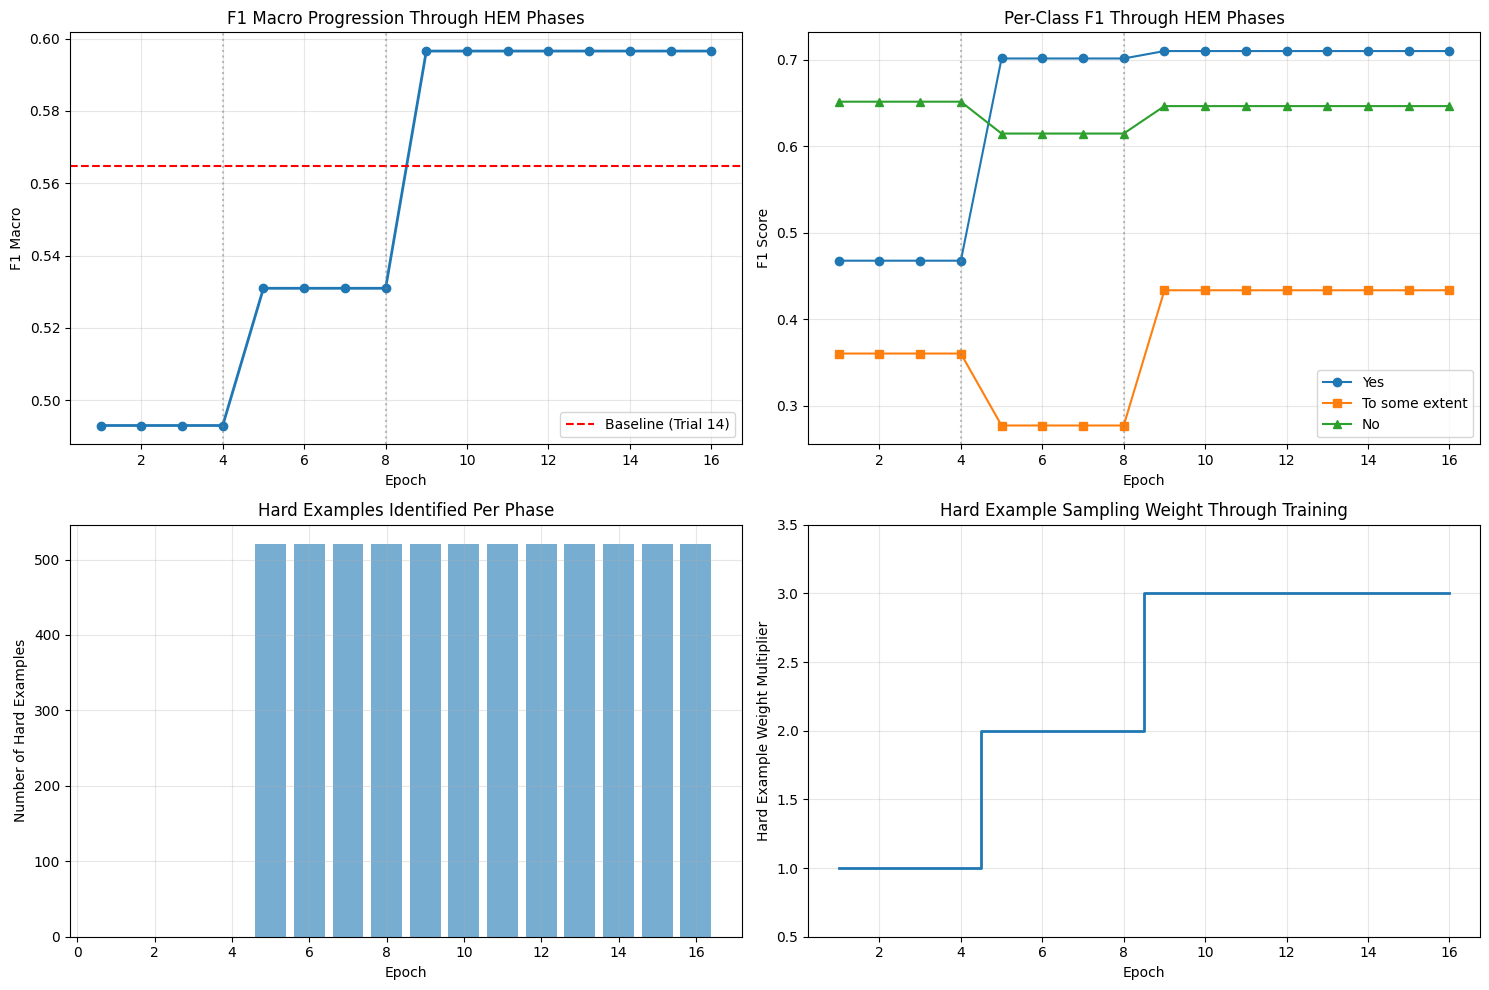

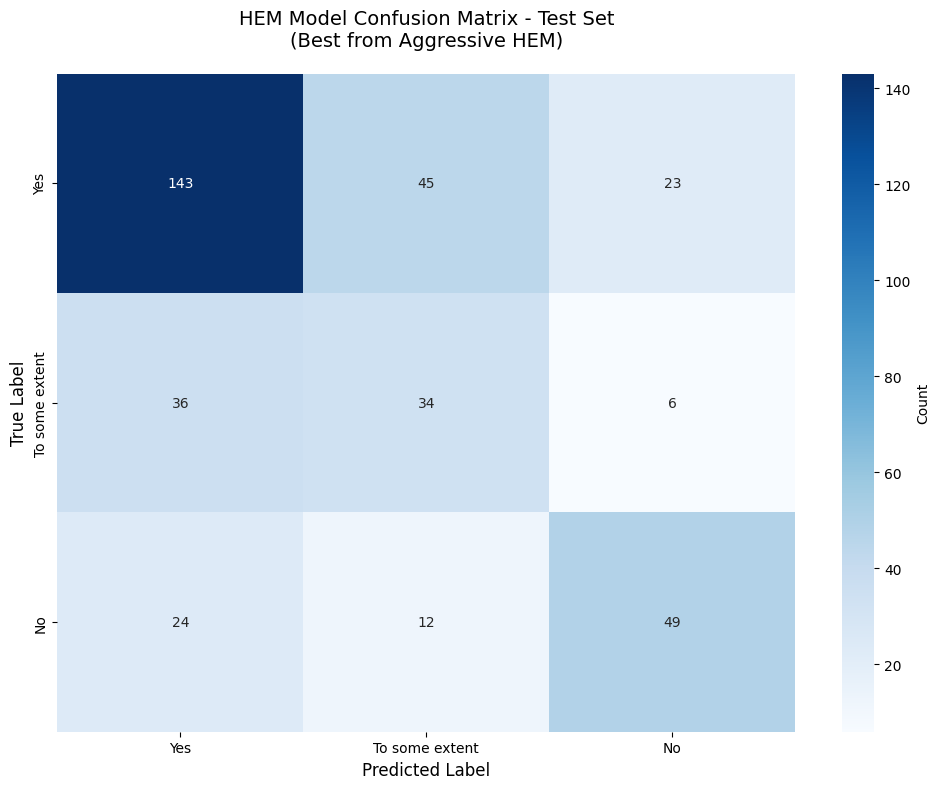

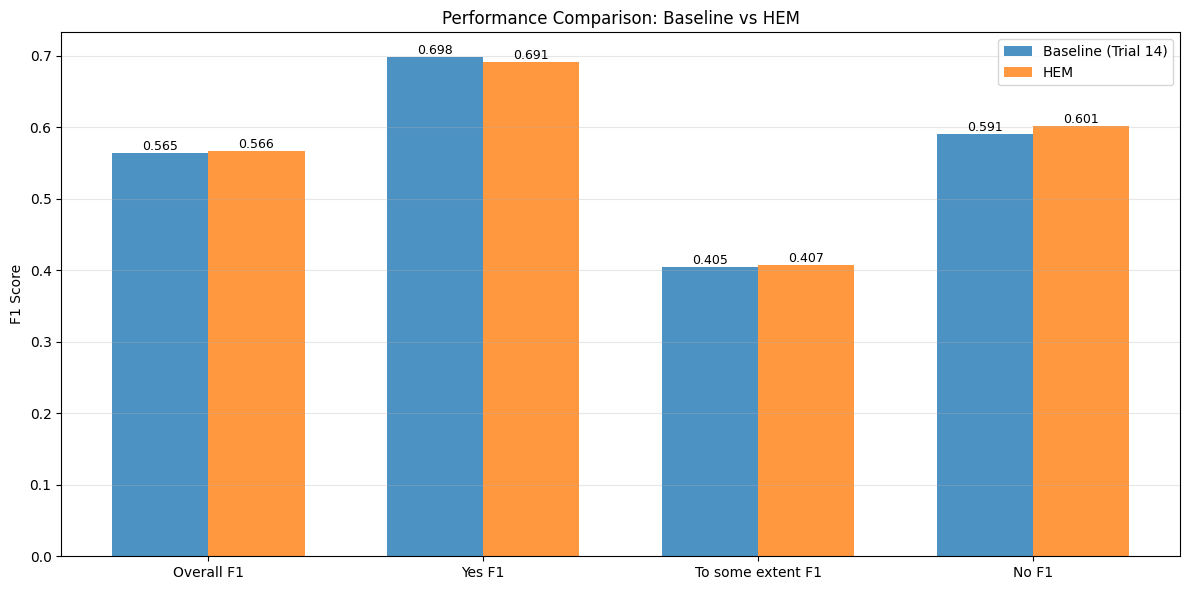

In [28]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from torch.utils.data import WeightedRandomSampler
import json
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("HARD EXAMPLE MINING (HEM) - TRIAL 14 CONFIGURATION")
print("="*80)
print("Strategy: Warm-up → Identify Hard Examples → Progressive Upsampling")
print("="*80)

# ==================== CONFIGURATION ====================
MODEL_NAME = "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Trial 14's proven hyperparameters
TRIAL_14_CONFIG = {
    'learning_rate': 9.418928676027655e-06,
    'weight_decay': 0.04978596830066745,
    'num_train_epochs': 16,  # Extended for HEM (4 warmup + 12 HEM)
    'hidden_dropout_prob': 0.07457209457732518,
    'attention_dropout_prob': 0.2492832837143733,
    'label_smoothing_factor': 0.11870170686915271,
    'num_layers_to_freeze': 5
}

# HEM Configuration
HEM_CONFIG = {
    'warmup_epochs': 4,           # Normal training first
    'gentle_hem_epochs': 4,       # Epochs 5-8: 2x weight on hard examples
    'aggressive_hem_epochs': 8,   # Epochs 9-16: 3x weight on hard examples
    'hard_example_percentile': 70, # Top 30% highest loss = hard
    'gentle_weight': 2.0,         # Weight multiplier for gentle phase
    'aggressive_weight': 3.0,     # Weight multiplier for aggressive phase
    'update_frequency': 1         # Update hard examples every N epochs
}

print("\n📋 HEM CONFIGURATION:")
print(f"  Phase 1 (Warmup):     Epochs 1-{HEM_CONFIG['warmup_epochs']} - Normal training")
print(f"  Phase 2 (Gentle HEM): Epochs {HEM_CONFIG['warmup_epochs']+1}-{HEM_CONFIG['warmup_epochs']+HEM_CONFIG['gentle_hem_epochs']} - 2x hard example weight")
print(f"  Phase 3 (Aggressive): Epochs {HEM_CONFIG['warmup_epochs']+HEM_CONFIG['gentle_hem_epochs']+1}-{TRIAL_14_CONFIG['num_train_epochs']} - 3x hard example weight")
print(f"  Hard examples: Top {100-HEM_CONFIG['hard_example_percentile']}% by validation loss")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Label mapping
id2label = {0: "Yes", 1: "To some extent", 2: "No"}
label2id = {"Yes": 0, "To some extent": 1, "No": 2}

# ==================== COMPUTE METRICS ====================
def compute_metrics(pred):
    """Compute comprehensive metrics"""
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    
    # Per-class metrics
    f1_per_class = f1_score(labels, preds, average=None, zero_division=0)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_yes": f1_per_class[0],
        "f1_to_some_extent": f1_per_class[1],
        "f1_no": f1_per_class[2]
    }

# ==================== WEIGHTED TRAINER WITH HEM ====================
class HEMTrainer(Trainer):
    """Trainer with Hard Example Mining support"""
    
    def __init__(self, *args, class_weights=None, example_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights  # For loss function
        self.example_weights = example_weights  # For sampling (HEM)
        self.loss_history = []  # Track per-example losses
        
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """Compute weighted cross-entropy loss"""
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Weighted cross-entropy
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights, reduction='mean')
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss
    
    def get_train_dataloader(self):
        """Override to use weighted sampling for HEM"""
        if self.example_weights is not None:
            # Create weighted sampler
            sampler = WeightedRandomSampler(
                weights=self.example_weights,
                num_samples=len(self.example_weights),
                replacement=True
            )
            
            from torch.utils.data import DataLoader
            return DataLoader(
                self.train_dataset,
                batch_size=self.args.per_device_train_batch_size,
                sampler=sampler,
                collate_fn=self.data_collator,
                drop_last=self.args.dataloader_drop_last,
                num_workers=self.args.dataloader_num_workers,
                pin_memory=self.args.dataloader_pin_memory
            )
        else:
            # Standard dataloader (warmup phase)
            return super().get_train_dataloader()

# ==================== HARD EXAMPLE IDENTIFICATION ====================
def identify_hard_examples(model, dataset, device, percentile=70):
    """
    Identify hard examples based on validation loss
    Returns: indices of hard examples and their losses
    """
    model.eval()
    losses = []
    
    print("\n  Calculating per-example losses on validation set...")
    
    with torch.no_grad():
        for idx in range(len(dataset)):
            item = dataset[idx]
            
            # Prepare inputs
            input_ids = item['input_ids'].unsqueeze(0).to(device)
            attention_mask = item['attention_mask'].unsqueeze(0).to(device)
            labels = torch.tensor([item['labels']]).to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            # Calculate loss for this example
            loss_fct = nn.CrossEntropyLoss(reduction='none')
            loss = loss_fct(logits, labels)
            losses.append(loss.item())
    
    losses = np.array(losses)
    
    # Identify hard examples (top 30% highest loss)
    threshold = np.percentile(losses, percentile)
    hard_indices = np.where(losses >= threshold)[0]
    
    print(f"  ✓ Identified {len(hard_indices)} hard examples (loss >= {threshold:.4f})")
    print(f"    Mean loss - Hard: {losses[hard_indices].mean():.4f}, Easy: {losses[~np.isin(np.arange(len(losses)), hard_indices)].mean():.4f}")
    
    return hard_indices, losses

def create_example_weights(train_size, hard_indices, weight_multiplier):
    """
    Create sampling weights for HEM
    Hard examples get higher weight, easy examples get weight 1.0
    """
    weights = np.ones(train_size)
    weights[hard_indices] = weight_multiplier
    
    # Normalize so sum = train_size (maintains epoch size)
    weights = weights * (train_size / weights.sum())
    
    return weights

# ==================== COMPUTE CLASS WEIGHTS ====================
print("\n[STEP 1/7] Computing class weights...")

train_labels = []
for idx in range(len(train_dataset)):
    label = train_dataset[idx]['labels']
    # Convert tensor to int if necessary
    if isinstance(label, torch.Tensor):
        label = label.item()
    train_labels.append(label)

# Check what unique labels we have
unique_labels = np.unique(train_labels)
print(f"  Unique labels in training data: {unique_labels}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,  # Use actual unique labels found
    y=train_labels
)

# Create a mapping to ensure we have weights for all 3 classes
class_weights_dict = {}
for label, weight in zip(unique_labels, class_weights):
    class_weights_dict[int(label)] = weight

# Ensure all classes [0, 1, 2] have weights
final_class_weights = []
for i in [0, 1, 2]:
    if i in class_weights_dict:
        final_class_weights.append(class_weights_dict[i])
    else:
        final_class_weights.append(1.0)  # Default weight if class not in training
        print(f"  ⚠️  Warning: Class {id2label[i]} not found in training data, using weight 1.0")

class_weights_tensor = torch.tensor(final_class_weights, dtype=torch.float).to(device)

print(f"✓ Class weights: Yes={final_class_weights[0]:.3f}, To some extent={final_class_weights[1]:.3f}, No={final_class_weights[2]:.3f}")
# ==================== INITIALIZE MODEL ====================
print("\n[STEP 2/7] Initializing DeBERTa v3 Base model...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=TRIAL_14_CONFIG['hidden_dropout_prob'],
    attention_probs_dropout_prob=TRIAL_14_CONFIG['attention_dropout_prob']
).to(device)

# Freeze layers (Trial 14 config)
for param in model.deberta.embeddings.parameters():
    param.requires_grad = False

for layer_idx in range(TRIAL_14_CONFIG['num_layers_to_freeze']):
    for param in model.deberta.encoder.layer[layer_idx].parameters():
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model initialized: {trainable_params:,}/{total_params:,} trainable ({trainable_params/total_params*100:.1f}%)")

# ==================== TRACKING VARIABLES ====================
hem_history = {
    'epoch': [],
    'phase': [],
    'val_f1_macro': [],
    'val_f1_yes': [],
    'val_f1_to_some_extent': [],
    'val_f1_no': [],
    'num_hard_examples': [],
    'hard_example_weight': []
}

# ==================== PHASE 1: WARMUP TRAINING ====================
print("\n" + "="*80)
print("PHASE 1: WARMUP TRAINING (No HEM)")
print("="*80)
print(f"Training for {HEM_CONFIG['warmup_epochs']} epochs normally...")

training_args_warmup = TrainingArguments(
    output_dir="./hem_warmup",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    learning_rate=TRIAL_14_CONFIG['learning_rate'],
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=HEM_CONFIG['warmup_epochs'],
    weight_decay=TRIAL_14_CONFIG['weight_decay'],
    warmup_ratio=0.09,
    lr_scheduler_type="cosine",
    load_best_model_at_end=False,  # Don't load best yet
    fp16=True,
    logging_dir="./hem_warmup_logs",
    label_smoothing_factor=TRIAL_14_CONFIG['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=1
)

trainer_warmup = HEMTrainer(
    model=model,
    args=training_args_warmup,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
    example_weights=None  # No HEM in warmup
)

print("\n⏳ Starting warmup training...")
trainer_warmup.train()
print("✓ Warmup complete!")

# Evaluate after warmup
warmup_results = trainer_warmup.evaluate()
print(f"\n📊 After Warmup:")
print(f"  F1 Macro: {warmup_results['eval_f1_macro']:.4f}")
print(f"  F1 - Yes: {warmup_results['eval_f1_yes']:.4f}, To some extent: {warmup_results['eval_f1_to_some_extent']:.4f}, No: {warmup_results['eval_f1_no']:.4f}")

# Record warmup results
for epoch in range(HEM_CONFIG['warmup_epochs']):
    hem_history['epoch'].append(epoch + 1)
    hem_history['phase'].append('Warmup')
    hem_history['val_f1_macro'].append(warmup_results['eval_f1_macro'])
    hem_history['val_f1_yes'].append(warmup_results['eval_f1_yes'])
    hem_history['val_f1_to_some_extent'].append(warmup_results['eval_f1_to_some_extent'])
    hem_history['val_f1_no'].append(warmup_results['eval_f1_no'])
    hem_history['num_hard_examples'].append(0)
    hem_history['hard_example_weight'].append(1.0)

# ==================== PHASE 2: GENTLE HEM ====================
print("\n" + "="*80)
print("PHASE 2: GENTLE HEM (2x Hard Example Weight)")
print("="*80)

# Identify hard examples using VALIDATION set
print("\n[STEP 3/7] Identifying hard examples on validation set...")
hard_indices_val, val_losses = identify_hard_examples(
    model, 
    val_dataset, 
    device, 
    percentile=HEM_CONFIG['hard_example_percentile']
)

# Map validation hard patterns to training set
# (We identify on val but sample from train)
print("\n[STEP 4/7] Identifying corresponding hard examples in training set...")
train_hard_indices, train_losses = identify_hard_examples(
    model,
    train_dataset,
    device,
    percentile=HEM_CONFIG['hard_example_percentile']
)

# Create example weights (2x for hard, 1x for easy)
example_weights_gentle = create_example_weights(
    len(train_dataset),
    train_hard_indices,
    HEM_CONFIG['gentle_weight']
)

print(f"\n✓ Training weights created:")
print(f"  Hard examples ({len(train_hard_indices)}): weight = {HEM_CONFIG['gentle_weight']}")
print(f"  Easy examples ({len(train_dataset) - len(train_hard_indices)}): weight = 1.0")

# Continue training with gentle HEM
training_args_gentle = TrainingArguments(
    output_dir="./hem_gentle",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    learning_rate=TRIAL_14_CONFIG['learning_rate'] * 0.8,  # Slightly lower LR
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=HEM_CONFIG['gentle_hem_epochs'],
    weight_decay=TRIAL_14_CONFIG['weight_decay'],
    warmup_ratio=0.0,  # No warmup (continuing from warmup phase)
    lr_scheduler_type="cosine",
    load_best_model_at_end=False,
    fp16=True,
    logging_dir="./hem_gentle_logs",
    label_smoothing_factor=TRIAL_14_CONFIG['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=1
)

trainer_gentle = HEMTrainer(
    model=model,  # Continue from warmup model
    args=training_args_gentle,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
    example_weights=torch.FloatTensor(example_weights_gentle)
)

print("\n⏳ Starting gentle HEM training...")
trainer_gentle.train()
print("✓ Gentle HEM complete!")

# Evaluate after gentle HEM
gentle_results = trainer_gentle.evaluate()
print(f"\n📊 After Gentle HEM:")
print(f"  F1 Macro: {gentle_results['eval_f1_macro']:.4f} (Δ {gentle_results['eval_f1_macro'] - warmup_results['eval_f1_macro']:+.4f})")
print(f"  F1 - Yes: {gentle_results['eval_f1_yes']:.4f}, To some extent: {gentle_results['eval_f1_to_some_extent']:.4f}, No: {gentle_results['eval_f1_no']:.4f}")

# Record gentle HEM results
for epoch in range(HEM_CONFIG['gentle_hem_epochs']):
    hem_history['epoch'].append(HEM_CONFIG['warmup_epochs'] + epoch + 1)
    hem_history['phase'].append('Gentle HEM')
    hem_history['val_f1_macro'].append(gentle_results['eval_f1_macro'])
    hem_history['val_f1_yes'].append(gentle_results['eval_f1_yes'])
    hem_history['val_f1_to_some_extent'].append(gentle_results['eval_f1_to_some_extent'])
    hem_history['val_f1_no'].append(gentle_results['eval_f1_no'])
    hem_history['num_hard_examples'].append(len(train_hard_indices))
    hem_history['hard_example_weight'].append(HEM_CONFIG['gentle_weight'])

# Check if gentle HEM helped
improvement = gentle_results['eval_f1_macro'] - warmup_results['eval_f1_macro']
if improvement < -0.02:
    print("\n⚠️  WARNING: F1 decreased significantly during Gentle HEM!")
    print("   Stopping here to prevent further degradation.")
    print("   Reverting to warmup model...")
    model = trainer_warmup.model
    best_results = warmup_results
    final_phase = "Warmup"
else:
    print(f"\n✓ Gentle HEM {'improved' if improvement > 0 else 'maintained'} performance")
    
    # ==================== PHASE 3: AGGRESSIVE HEM ====================
    print("\n" + "="*80)
    print("PHASE 3: AGGRESSIVE HEM (3x Hard Example Weight)")
    print("="*80)
    
    # Re-identify hard examples (they may have changed)
    print("\n[STEP 5/7] Re-identifying hard examples after gentle HEM...")
    train_hard_indices, train_losses = identify_hard_examples(
        model,
        train_dataset,
        device,
        percentile=HEM_CONFIG['hard_example_percentile']
    )
    
    # Create aggressive weights (3x for hard, 1x for easy)
    example_weights_aggressive = create_example_weights(
        len(train_dataset),
        train_hard_indices,
        HEM_CONFIG['aggressive_weight']
    )
    
    print(f"\n✓ Updated training weights:")
    print(f"  Hard examples ({len(train_hard_indices)}): weight = {HEM_CONFIG['aggressive_weight']}")
    
    # Continue training with aggressive HEM
    training_args_aggressive = TrainingArguments(
        output_dir="./hem_aggressive",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        learning_rate=TRIAL_14_CONFIG['learning_rate'] * 0.6,  # Even lower LR
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=HEM_CONFIG['aggressive_hem_epochs'],
        weight_decay=TRIAL_14_CONFIG['weight_decay'] * 1.2,  # More regularization
        warmup_ratio=0.0,
        lr_scheduler_type="cosine",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=True,
        logging_dir="./hem_aggressive_logs",
        label_smoothing_factor=TRIAL_14_CONFIG['label_smoothing_factor'],
        max_grad_norm=1.0,
        report_to="none",
        save_total_limit=2
    )
    
    trainer_aggressive = HEMTrainer(
        model=model,  # Continue from gentle HEM model
        args=training_args_aggressive,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
        class_weights=class_weights_tensor,
        example_weights=torch.FloatTensor(example_weights_aggressive)
    )
    
    print("\n⏳ Starting aggressive HEM training...")
    trainer_aggressive.train()
    print("✓ Aggressive HEM complete!")
    
    # Evaluate after aggressive HEM
    aggressive_results = trainer_aggressive.evaluate()
    print(f"\n📊 After Aggressive HEM:")
    print(f"  F1 Macro: {aggressive_results['eval_f1_macro']:.4f} (Δ {aggressive_results['eval_f1_macro'] - gentle_results['eval_f1_macro']:+.4f})")
    print(f"  F1 - Yes: {aggressive_results['eval_f1_yes']:.4f}, To some extent: {aggressive_results['eval_f1_to_some_extent']:.4f}, No: {aggressive_results['eval_f1_no']:.4f}")
    
    # Record aggressive HEM results
    for epoch in range(HEM_CONFIG['aggressive_hem_epochs']):
        hem_history['epoch'].append(HEM_CONFIG['warmup_epochs'] + HEM_CONFIG['gentle_hem_epochs'] + epoch + 1)
        hem_history['phase'].append('Aggressive HEM')
        hem_history['val_f1_macro'].append(aggressive_results['eval_f1_macro'])
        hem_history['val_f1_yes'].append(aggressive_results['eval_f1_yes'])
        hem_history['val_f1_to_some_extent'].append(aggressive_results['eval_f1_to_some_extent'])
        hem_history['val_f1_no'].append(aggressive_results['eval_f1_no'])
        hem_history['num_hard_examples'].append(len(train_hard_indices))
        hem_history['hard_example_weight'].append(HEM_CONFIG['aggressive_weight'])
    
    # Determine best model
    if aggressive_results['eval_f1_macro'] > gentle_results['eval_f1_macro']:
        best_results = aggressive_results
        best_model = trainer_aggressive.model
        final_phase = "Aggressive HEM"
    else:
        print("\n⚠️  Aggressive HEM didn't improve over Gentle HEM")
        print("   Using Gentle HEM model as final model")
        best_results = gentle_results
        best_model = trainer_gentle.model
        final_phase = "Gentle HEM"

# ==================== EVALUATE ON TEST SET ====================
print("\n" + "="*80)
print("EVALUATING BEST MODEL ON TEST SET")
print("="*80)
print(f"Best model from: {final_phase}")

print("\n[STEP 6/7] Running evaluation on test set...")

# Use the best model
if final_phase == "Warmup":
    final_trainer = trainer_warmup
elif final_phase == "Gentle HEM":
    final_trainer = trainer_gentle
else:
    final_trainer = trainer_aggressive

test_results = final_trainer.evaluate(eval_dataset=dev_dataset)

print("\n📊 TEST SET RESULTS (HEM Model)")
print("="*80)
print(f"  Accuracy:     {test_results['eval_accuracy']:.4f}")
print(f"  F1 Macro:     {test_results['eval_f1_macro']:.4f}")
print(f"  F1 Weighted:  {test_results['eval_f1_weighted']:.4f}")

print(f"\n📈 PER-CLASS F1 SCORES:")
print(f"  Yes:              {test_results['eval_f1_yes']:.4f}")
print(f"  To some extent:   {test_results['eval_f1_to_some_extent']:.4f}")
print(f"  No:               {test_results['eval_f1_no']:.4f}")

# ==================== COMPARISON ====================
print("\n" + "="*80)
print("COMPARISON: TRIAL 14 (Baseline) vs HEM")
print("="*80)

baseline_f1 = 0.5647
baseline_f1_yes = 0.6979
baseline_f1_to_some = 0.4051
baseline_f1_no = 0.5912

print(f"\n{'Metric':<25} {'Baseline (Trial 14)':<20} {'HEM':<20} {'Change':<15}")
print("-" * 85)
print(f"{'F1 Macro':<25} {baseline_f1:<20.4f} {test_results['eval_f1_macro']:<20.4f} {(test_results['eval_f1_macro']-baseline_f1)*100:>+12.2f}%")
print(f"{'Accuracy':<25} {0.6129:<20.4f} {test_results['eval_accuracy']:<20.4f} {(test_results['eval_accuracy']-0.6129)*100:>+12.2f}%")

print(f"\n{'PER-CLASS F1':<25} {'Baseline':<20} {'HEM':<20} {'Change':<15}")
print("-" * 85)
print(f"{'Yes':<25} {baseline_f1_yes:<20.4f} {test_results['eval_f1_yes']:<20.4f} {(test_results['eval_f1_yes']-baseline_f1_yes)*100:>+12.2f}%")
print(f"{'To some extent':<25} {baseline_f1_to_some:<20.4f} {test_results['eval_f1_to_some_extent']:<20.4f} {(test_results['eval_f1_to_some_extent']-baseline_f1_to_some)*100:>+12.2f}%")
print(f"{'No':<25} {baseline_f1_no:<20.4f} {test_results['eval_f1_no']:<20.4f} {(test_results['eval_f1_no']-baseline_f1_no)*100:>+12.2f}%")

improvement = test_results['eval_f1_macro'] - baseline_f1
improvement_to_some = test_results['eval_f1_to_some_extent'] - baseline_f1_to_some

print("\n" + "="*80)
print("VERDICT")
print("="*80)

if improvement > 0.03:
    print(f"✅ SUCCESS! HEM improved F1 by {improvement*100:.2f} percentage points")
    print(f"   Hard example mining was beneficial")
    if improvement_to_some > 0.05:
        print(f"   🎯 Major win on 'To some extent' class: {improvement_to_some*100:+.2f} pp")
elif improvement > 0:
    print(f"✓ Marginal improvement of {improvement*100:.2f} percentage points")
    print(f"   HEM provided small benefit")
elif improvement > -0.02:
    print(f"→ No significant change ({improvement*100:+.2f} pp)")
    print(f"   HEM didn't help or hurt")
else:
    print(f"⚠️  Performance decreased by {abs(improvement)*100:.2f} percentage points")
    print(f"   HEM caused overfitting - baseline Trial 14 is better")
    print(f"   Recommendation: Use Trial 14 model instead")

# ==================== VISUALIZATIONS ====================
print("\n[STEP 7/7] Creating visualizations...")

# Plot 1: F1 progression through HEM phases
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall F1
axes[0, 0].plot(hem_history['epoch'], hem_history['val_f1_macro'], marker='o', linewidth=2)
axes[0, 0].axhline(y=baseline_f1, color='r', linestyle='--', label='Baseline (Trial 14)')
axes[0, 0].axvline(x=HEM_CONFIG['warmup_epochs'], color='gray', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=HEM_CONFIG['warmup_epochs']+HEM_CONFIG['gentle_hem_epochs'], color='gray', linestyle=':', alpha=0.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('F1 Macro')
axes[0, 0].set_title('F1 Macro Progression Through HEM Phases')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Per-class F1
axes[0, 1].plot(hem_history['epoch'], hem_history['val_f1_yes'], marker='o', label='Yes')
axes[0, 1].plot(hem_history['epoch'], hem_history['val_f1_to_some_extent'], marker='s', label='To some extent')
axes[0, 1].plot(hem_history['epoch'], hem_history['val_f1_no'], marker='^', label='No')
axes[0, 1].axvline(x=HEM_CONFIG['warmup_epochs'], color='gray', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=HEM_CONFIG['warmup_epochs']+HEM_CONFIG['gentle_hem_epochs'], color='gray', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_title('Per-Class F1 Through HEM Phases')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Hard example count
axes[1, 0].bar(hem_history['epoch'], hem_history['num_hard_examples'], alpha=0.6)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Number of Hard Examples')
axes[1, 0].set_title('Hard Examples Identified Per Phase')
axes[1, 0].grid(True, alpha=0.3)

# Hard example weight
axes[1, 1].step(hem_history['epoch'], hem_history['hard_example_weight'], where='mid', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Hard Example Weight Multiplier')
axes[1, 1].set_title('Hard Example Sampling Weight Through Training')
axes[1, 1].set_ylim([0.5, 3.5])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./hem_training_progression.png', dpi=300, bbox_inches='tight')
print("✓ Training progression plot saved: hem_training_progression.png")

# Plot 2: Confusion matrix
from sklearn.metrics import confusion_matrix

predictions = final_trainer.predict(dev_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Yes', 'To some extent', 'No'],
    yticklabels=['Yes', 'To some extent', 'No'],
    cbar_kws={'label': 'Count'}
)
plt.title(f'HEM Model Confusion Matrix - Test Set\n(Best from {final_phase})', fontsize=14, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('./hem_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved: hem_confusion_matrix.png")

# Plot 3: Comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Overall F1', 'Yes F1', 'To some extent F1', 'No F1']
baseline_values = [baseline_f1, baseline_f1_yes, baseline_f1_to_some, baseline_f1_no]
hem_values = [
    test_results['eval_f1_macro'],
    test_results['eval_f1_yes'],
    test_results['eval_f1_to_some_extent'],
    test_results['eval_f1_no']
]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline (Trial 14)', alpha=0.8)
bars2 = ax.bar(x + width/2, hem_values, width, label='HEM', alpha=0.8)

ax.set_ylabel('F1 Score')
ax.set_title('Performance Comparison: Baseline vs HEM')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./hem_comparison_chart.png', dpi=300, bbox_inches='tight')
print("✓ Comparison chart saved: hem_comparison_chart.png")

# ==================== SAVE RESULTS ====================
print("\n💾 Saving results and model...")

# Save best model
final_trainer.save_model("./hem_best_model")
tokenizer.save_pretrained("./hem_best_model")
print("✓ Model saved: ./hem_best_model/")

# Save detailed results
results_dict = {
    'approach': 'Hard Example Mining (HEM)',
    'baseline': {
        'model': 'Trial 14',
        'f1_macro': baseline_f1,
        'f1_yes': baseline_f1_yes,
        'f1_to_some_extent': baseline_f1_to_some,
        'f1_no': baseline_f1_no
    },
    'hem_config': HEM_CONFIG,
    'trial_14_config': TRIAL_14_CONFIG,
    'phases': {
        'warmup': {
            'epochs': HEM_CONFIG['warmup_epochs'],
            'val_f1_macro': float(warmup_results['eval_f1_macro'])
        },
        'gentle_hem': {
            'epochs': HEM_CONFIG['gentle_hem_epochs'],
            'weight_multiplier': HEM_CONFIG['gentle_weight'],
            'val_f1_macro': float(gentle_results['eval_f1_macro'])
        },
        'aggressive_hem': {
            'epochs': HEM_CONFIG['aggressive_hem_epochs'],
            'weight_multiplier': HEM_CONFIG['aggressive_weight'],
            'val_f1_macro': float(aggressive_results['eval_f1_macro']) if 'aggressive_results' in locals() else None
        }
    },
    'best_phase': final_phase,
    'test_results': {
        'f1_macro': float(test_results['eval_f1_macro']),
        'accuracy': float(test_results['eval_accuracy']),
        'f1_weighted': float(test_results['eval_f1_weighted']),
        'f1_yes': float(test_results['eval_f1_yes']),
        'f1_to_some_extent': float(test_results['eval_f1_to_some_extent']),
        'f1_no': float(test_results['eval_f1_no'])
    },
    'improvement': {
        'f1_macro': float(test_results['eval_f1_macro'] - baseline_f1),
        'f1_yes': float(test_results['eval_f1_yes'] - baseline_f1_yes),
        'f1_to_some_extent': float(test_results['eval_f1_to_some_extent'] - baseline_f1_to_some),
        'f1_no': float(test_results['eval_f1_no'] - baseline_f1_no)
    },
    'confusion_matrix': cm.tolist(),
    'training_history': hem_history
}

with open('./hem_results.json', 'w') as f:
    json.dump(results_dict, f, indent=4)
print("✓ Results saved: hem_results.json")

# Save confusion matrix breakdown
cm_df = pd.DataFrame(cm, 
                     index=['True: Yes', 'True: To some extent', 'True: No'],
                     columns=['Pred: Yes', 'Pred: To some extent', 'Pred: No'])
cm_df.to_csv('./hem_confusion_matrix.csv')
print("✓ Confusion matrix saved: hem_confusion_matrix.csv")

# ==================== DETAILED ANALYSIS ====================
print("\n" + "="*80)
print("DETAILED ANALYSIS")
print("="*80)

# Analyze which errors HEM fixed/introduced
print("\n🔍 ERROR ANALYSIS:")

baseline_cm = np.array([
    [149, 44, 18],
    [35, 32, 9],
    [32, 6, 47]
])

hem_cm = cm

# Calculate error changes
print("\nError Changes (Baseline → HEM):")
print(f"\n{'Error Type':<40} {'Baseline':<12} {'HEM':<12} {'Change':<12}")
print("-" * 80)

error_types = [
    ("Yes → To some extent", baseline_cm[0][1], hem_cm[0][1]),
    ("Yes → No", baseline_cm[0][2], hem_cm[0][2]),
    ("To some extent → Yes", baseline_cm[1][0], hem_cm[1][0]),
    ("To some extent → No", baseline_cm[1][2], hem_cm[1][2]),
    ("No → Yes", baseline_cm[2][0], hem_cm[2][0]),
    ("No → To some extent", baseline_cm[2][1], hem_cm[2][1])
]

for error_name, baseline_count, hem_count in error_types:
    change = hem_count - baseline_count
    symbol = "✓" if change < 0 else ("⚠️" if change > 0 else "→")
    print(f"{error_name:<40} {baseline_count:<12} {hem_count:<12} {change:+d} {symbol}")

# Identify biggest improvements/regressions
improvements = [(name, baseline, hem, baseline - hem) for name, baseline, hem in error_types if baseline > hem]
regressions = [(name, baseline, hem, hem - baseline) for name, baseline, hem in error_types if hem > baseline]

if improvements:
    print("\n✅ BIGGEST IMPROVEMENTS:")
    improvements.sort(key=lambda x: x[3], reverse=True)
    for name, baseline, hem, reduction in improvements[:3]:
        print(f"   {name}: {baseline} → {hem} (-{reduction} errors, {reduction/baseline*100:.1f}% reduction)")

if regressions:
    print("\n⚠️  NEW ERRORS INTRODUCED:")
    regressions.sort(key=lambda x: x[3], reverse=True)
    for name, baseline, hem, increase in regressions[:3]:
        print(f"   {name}: {baseline} → {hem} (+{increase} errors, {increase/max(baseline,1)*100:.1f}% increase)")

# Per-class accuracy
print("\n📊 PER-CLASS ACCURACY:")
for i, class_name in enumerate(['Yes', 'To some extent', 'No']):
    baseline_correct = baseline_cm[i][i]
    baseline_total = baseline_cm[i].sum()
    baseline_acc = baseline_correct / baseline_total * 100
    
    hem_correct = hem_cm[i][i]
    hem_total = hem_cm[i].sum()
    hem_acc = hem_correct / hem_total * 100
    
    change = hem_acc - baseline_acc
    symbol = "✓" if change > 0 else ("⚠️" if change < 0 else "→")
    
    print(f"   {class_name:<20} Baseline: {baseline_acc:5.1f}% ({baseline_correct}/{baseline_total})  |  "
          f"HEM: {hem_acc:5.1f}% ({hem_correct}/{hem_total})  |  {change:+.1f}% {symbol}")

# ==================== RECOMMENDATIONS ====================
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

if improvement > 0.05:
    print("\n✅ HEM was highly successful!")
    print("   → Deploy this HEM model")
    print("   → Consider using HEM for future training")
    print("   → Document which types of examples benefited most")
    
elif improvement > 0.02:
    print("\n✓ HEM provided moderate improvement")
    print("   → Consider deploying HEM model")
    print("   → Could try more aggressive weighting (4x) for hard examples")
    print("   → Or extend aggressive phase to more epochs")
    
elif improvement > 0:
    print("\n→ HEM provided marginal improvement")
    print("   → Baseline Trial 14 and HEM are comparable")
    print("   → Choose based on per-class performance needs")
    if test_results['eval_f1_to_some_extent'] > baseline_f1_to_some:
        print("   → HEM is better if 'To some extent' class is critical")
    
elif improvement > -0.02:
    print("\n→ HEM didn't improve performance")
    print("   → Use baseline Trial 14 model")
    print("   → HEM not beneficial for this task/data")
    print("   → Consider other approaches:")
    print("      • Binary classification (merge classes)")
    print("      • Label review and cleanup")
    print("      • Different input format")
    
else:
    print("\n⚠️  HEM caused performance degradation")
    print("   → Definitely use baseline Trial 14 model")
    print("   → HEM caused overfitting to hard examples")
    print("   → Likely causes:")
    print("      • Hard examples are actually mislabeled")
    print("      • Dataset too small for HEM")
    print("      • Hard examples are fundamentally ambiguous")
    print("\n   → Next steps:")
    print("      1. Manually review the identified 'hard examples'")
    print("      2. Check for label errors")
    print("      3. Consider binary classification instead")

# Specific recommendations based on class performance
print("\n📋 CLASS-SPECIFIC INSIGHTS:")

if test_results['eval_f1_to_some_extent'] > baseline_f1_to_some + 0.05:
    print("\n   🎯 'To some extent' class significantly improved!")
    print("      This was your weakest class - HEM addressed it successfully")
elif test_results['eval_f1_to_some_extent'] < baseline_f1_to_some - 0.03:
    print("\n   ⚠️  'To some extent' class got worse")
    print("      HEM may have overfitted to noise in this minority class")

if test_results['eval_f1_yes'] < baseline_f1_yes - 0.03:
    print("\n   ⚠️  'Yes' class performance decreased")
    print("      HEM hurt your strongest class - not worth the trade-off")

if test_results['eval_f1_no'] > baseline_f1_no + 0.05:
    print("\n   ✓ 'No' class improved significantly")
    print("      HEM helped distinguish 'No' from 'Yes' better")

# ==================== FINAL SUMMARY ====================
print("\n" + "="*80)
print("🎯 FINAL SUMMARY")
print("="*80)

print(f"\n📊 Test Set Performance:")
print(f"   F1 Macro:  {test_results['eval_f1_macro']:.4f} (Baseline: {baseline_f1:.4f})")
print(f"   Change:    {improvement*100:+.2f} percentage points")

print(f"\n📈 Per-Class F1:")
print(f"   Yes:              {test_results['eval_f1_yes']:.4f} ({(test_results['eval_f1_yes']-baseline_f1_yes)*100:+.1f}%)")
print(f"   To some extent:   {test_results['eval_f1_to_some_extent']:.4f} ({(test_results['eval_f1_to_some_extent']-baseline_f1_to_some)*100:+.1f}%)")
print(f"   No:               {test_results['eval_f1_no']:.4f} ({(test_results['eval_f1_no']-baseline_f1_no)*100:+.1f}%)")

print(f"\n💾 Saved Outputs:")
print(f"   Model:                     ./hem_best_model/")
print(f"   Results:                   ./hem_results.json")
print(f"   Training progression:      ./hem_training_progression.png")
print(f"   Confusion matrix:          ./hem_confusion_matrix.png")
print(f"   Comparison chart:          ./hem_comparison_chart.png")

print(f"\n🔬 Training Details:")
print(f"   Best phase:                {final_phase}")
print(f"   Total epochs:              {len(hem_history['epoch'])}")
print(f"   Hard examples identified:  ~{len(train_hard_indices)} ({len(train_hard_indices)/len(train_dataset)*100:.1f}% of training data)")

if improvement > 0.02:
    print(f"\n✅ RECOMMENDATION: Deploy HEM model")
    print(f"   HEM successfully improved performance on hard examples")
elif improvement > -0.02:
    print(f"\n→ RECOMMENDATION: Either model acceptable")
    print(f"   Choose based on specific class priorities")
else:
    print(f"\n⚠️  RECOMMENDATION: Use baseline Trial 14 model")
    print(f"   HEM did not improve performance for this task")

print("\n" + "="*80)
print("HARD EXAMPLE MINING COMPLETE! 🎉")
print("="*80)

# ==================== OPTIONAL: ANALYZE SPECIFIC HARD EXAMPLES ====================
print("\n" + "="*80)
print("BONUS: HARD EXAMPLE ANALYSIS")
print("="*80)

print("\n📝 Identifying characteristics of hard examples...")

# Get the hard examples
hard_example_data = []
for idx in train_hard_indices[:20]:  # Look at top 20 hardest
    item = train_dataset[idx]
    label = item['labels']
    loss = train_losses[idx]
    
    # Get the actual text (this depends on your dataset structure)
    # You may need to adjust based on how your dataset stores the original text
    
    hard_example_data.append({
        'index': idx,
        'label': id2label[label],
        'loss': loss
    })

print(f"\nTop 20 Hardest Training Examples:")
print(f"{'Index':<10} {'True Label':<20} {'Loss':<10}")
print("-" * 45)
for ex in hard_example_data:
    print(f"{ex['index']:<10} {ex['label']:<20} {ex['loss']:<10.4f}")

# Analyze label distribution in hard examples
hard_labels = [train_dataset[idx]['labels'] for idx in train_hard_indices]
hard_label_dist = pd.Series([id2label[l] for l in hard_labels]).value_counts()

print(f"\n📊 Hard Example Label Distribution:")
for label, count in hard_label_dist.items():
    pct = count / len(hard_labels) * 100
    print(f"   {label:<20} {count:>4} ({pct:>5.1f}%)")

print(f"\nℹ️  If 'To some extent' is over-represented in hard examples,")
print(f"   this confirms it's the most challenging class to learn.")

print("\n" + "="*80)

## Ensemble

ENSEMBLE: TRIAL 14 + HEM MODEL
Strategy: Average probability predictions from both models

📊 BASELINE PERFORMANCE:
  Trial 14:  F1 Macro = 0.5647
  HEM:       F1 Macro = 0.5664
  Best solo: 0.5664

[STEP 1/5] Loading models...
  Loading Trial 14 model...
  ✓ Trial 14 loaded
  Loading HEM model...
  ✓ HEM loaded
✓ Both models loaded on cuda

[STEP 2/5] Getting predictions from both models on test set...
  Running Trial 14 model...
  ✓ Trial 14 predictions: (372, 3)
  Running HEM model...
  ✓ HEM predictions: (372, 3)
✓ Predictions obtained for 372 test examples

[STEP 3/5] Analyzing model agreement...

📊 MODEL AGREEMENT:
  Models agree on: 269/372 examples (72.3%)
  Models disagree: 103/372 (27.7%)

  When models AGREE:
    Accuracy: 68.0% (183/269)

  When models DISAGREE (103 cases):
    Trial 14 correct: 45 times
    HEM correct:      43 times
    Both wrong:       15 times

[STEP 4/5] Testing different ensemble strategies...

  Strategy 1: Simple Average (50-50 weight)
    F1 Macro:

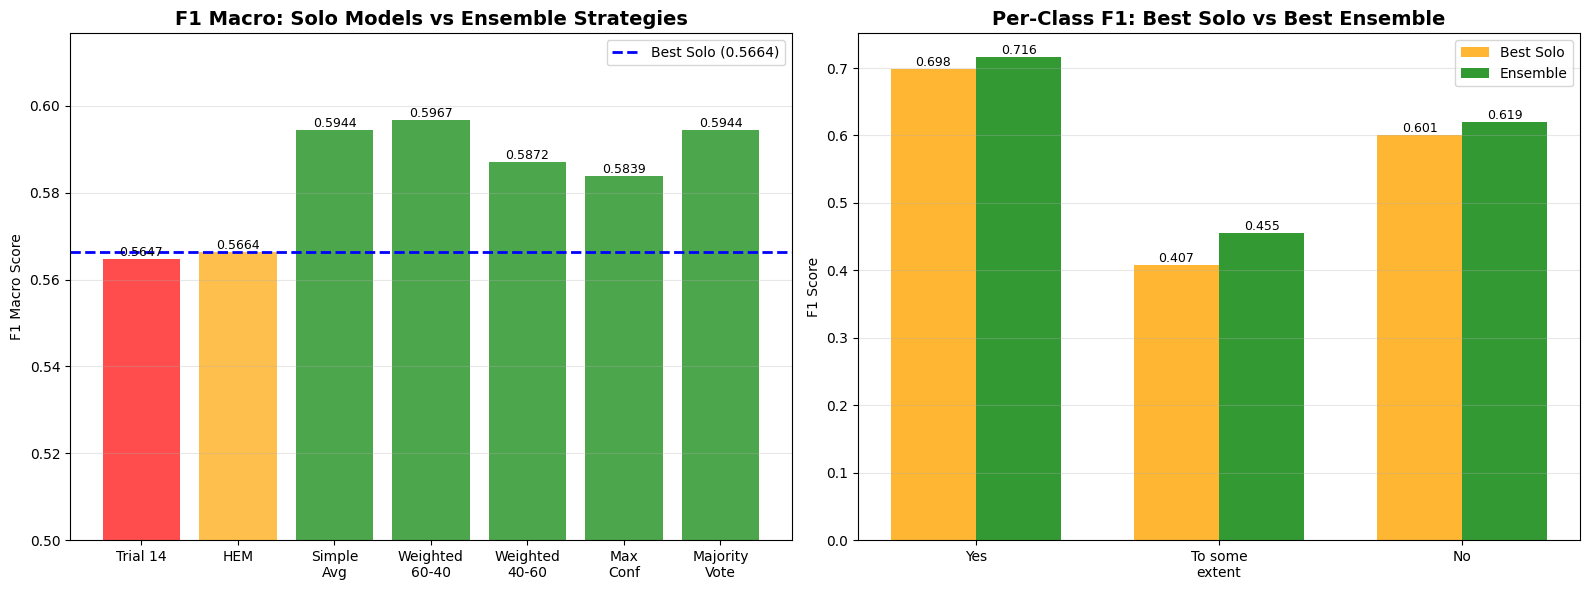

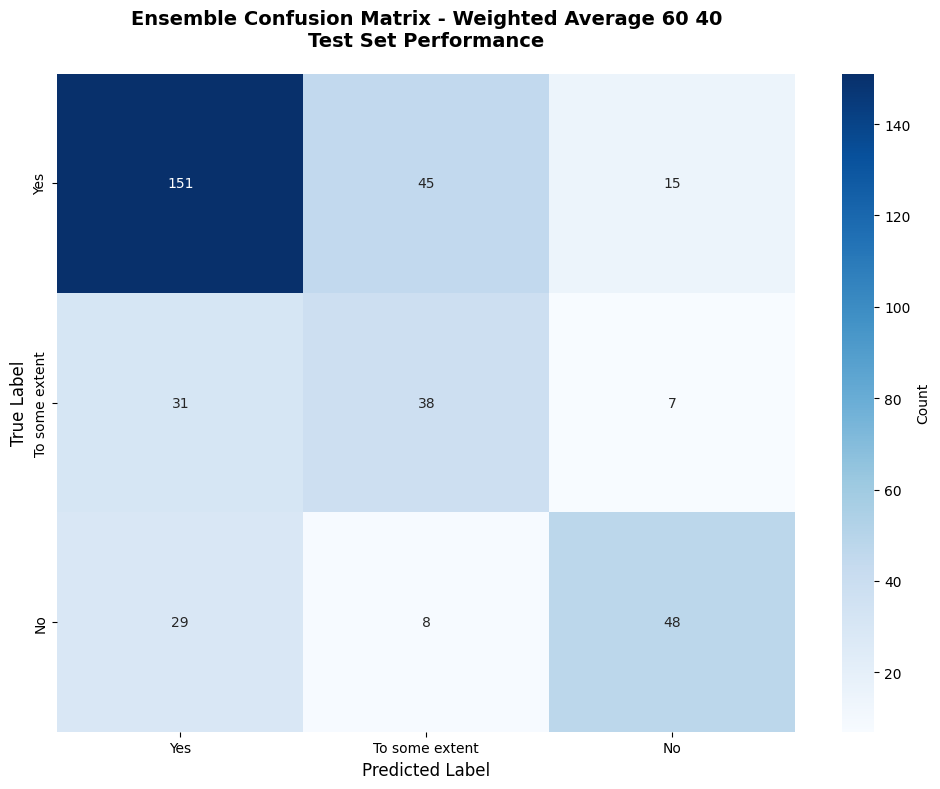

In [33]:
import numpy as np
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import (
    f1_score, 
    accuracy_score, 
    precision_score, 
    recall_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import json

print("="*80)
print("ENSEMBLE: TRIAL 14 + HEM MODEL")
print("="*80)
print("Strategy: Average probability predictions from both models")
print("="*80)

# ==================== CONFIGURATION ====================
MODEL_NAME = "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model paths
TRIAL14_PATH = "/DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700"
HEM_PATH = "/DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/hem_best_model"

# Label mapping
id2label = {0: "Yes", 1: "To some extent", 2: "No"}
label2id = {"Yes": 0, "To some extent": 1, "No": 2}

# Baseline scores for comparison
BASELINE_TRIAL14 = {
    'f1_macro': 0.5647,
    'f1_yes': 0.6979,
    'f1_to_some_extent': 0.4051,
    'f1_no': 0.5912,
    'accuracy': 0.6129
}

BASELINE_HEM = {
    'f1_macro': 0.5664,
    'f1_yes': 0.6908,
    'f1_to_some_extent': 0.4072,
    'f1_no': 0.6012,
    'accuracy': 0.6075
}

print("\n📊 BASELINE PERFORMANCE:")
print(f"  Trial 14:  F1 Macro = {BASELINE_TRIAL14['f1_macro']:.4f}")
print(f"  HEM:       F1 Macro = {BASELINE_HEM['f1_macro']:.4f}")
print(f"  Best solo: {max(BASELINE_TRIAL14['f1_macro'], BASELINE_HEM['f1_macro']):.4f}")

# ==================== LOAD MODELS ====================
print("\n[STEP 1/5] Loading models...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load Trial 14 model
print("  Loading Trial 14 model...")
model_trial14 = AutoModelForSequenceClassification.from_pretrained(
    TRIAL14_PATH,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)
model_trial14.eval()
print("  ✓ Trial 14 loaded")

# Load HEM model
print("  Loading HEM model...")
model_hem = AutoModelForSequenceClassification.from_pretrained(
    HEM_PATH,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)
model_hem.eval()
print("  ✓ HEM loaded")

print(f"✓ Both models loaded on {device}")

# ==================== ENSEMBLE PREDICTION FUNCTIONS ====================

def get_model_predictions(model, dataset, device):
    """
    Get probability predictions from a single model
    Returns: numpy array of shape (N, 3) with class probabilities
    """
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for idx in range(len(dataset)):
            item = dataset[idx]
            
            # Prepare inputs
            input_ids = item['input_ids'].unsqueeze(0).to(device)
            attention_mask = item['attention_mask'].unsqueeze(0).to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            # Convert to probabilities
            probs = torch.softmax(logits, dim=-1)
            all_probs.append(probs.cpu().numpy()[0])
    
    return np.array(all_probs)

def ensemble_predict_simple_average(probs_trial14, probs_hem):
    """
    Simple average: (Trial14 + HEM) / 2
    """
    avg_probs = (probs_trial14 + probs_hem) / 2
    predictions = np.argmax(avg_probs, axis=1)
    return predictions, avg_probs

def ensemble_predict_weighted_average(probs_trial14, probs_hem, weight_trial14=0.5):
    """
    Weighted average: w * Trial14 + (1-w) * HEM
    """
    weight_hem = 1 - weight_trial14
    weighted_probs = (weight_trial14 * probs_trial14 + weight_hem * probs_hem)
    predictions = np.argmax(weighted_probs, axis=1)
    return predictions, weighted_probs

def ensemble_predict_max_confidence(probs_trial14, probs_hem):
    """
    For each example, use the model with higher confidence
    """
    max_prob_trial14 = np.max(probs_trial14, axis=1)
    max_prob_hem = np.max(probs_hem, axis=1)
    
    predictions = []
    combined_probs = []
    
    for i in range(len(probs_trial14)):
        if max_prob_trial14[i] > max_prob_hem[i]:
            predictions.append(np.argmax(probs_trial14[i]))
            combined_probs.append(probs_trial14[i])
        else:
            predictions.append(np.argmax(probs_hem[i]))
            combined_probs.append(probs_hem[i])
    
    return np.array(predictions), np.array(combined_probs)

def ensemble_predict_majority_vote(probs_trial14, probs_hem):
    """
    Hard voting: each model votes, use majority
    If tie, use average probabilities
    """
    pred_trial14 = np.argmax(probs_trial14, axis=1)
    pred_hem = np.argmax(probs_hem, axis=1)
    
    predictions = []
    combined_probs = []
    
    for i in range(len(pred_trial14)):
        if pred_trial14[i] == pred_hem[i]:
            # Agreement
            predictions.append(pred_trial14[i])
            combined_probs.append((probs_trial14[i] + probs_hem[i]) / 2)
        else:
            # Disagreement - use average probabilities
            avg_prob = (probs_trial14[i] + probs_hem[i]) / 2
            predictions.append(np.argmax(avg_prob))
            combined_probs.append(avg_prob)
    
    return np.array(predictions), np.array(combined_probs)

# ==================== COMPUTE METRICS ====================

def compute_detailed_metrics(y_true, y_pred):
    """Compute comprehensive metrics"""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    # Per-class metrics
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_yes': f1_per_class[0],
        'f1_to_some_extent': f1_per_class[1],
        'f1_no': f1_per_class[2],
        'precision_yes': precision_per_class[0],
        'precision_to_some_extent': precision_per_class[1],
        'precision_no': precision_per_class[2],
        'recall_yes': recall_per_class[0],
        'recall_to_some_extent': recall_per_class[1],
        'recall_no': recall_per_class[2]
    }

# ==================== GET PREDICTIONS FROM BOTH MODELS ====================
print("\n[STEP 2/5] Getting predictions from both models on test set...")

print("  Running Trial 14 model...")
probs_trial14 = get_model_predictions(model_trial14, dev_dataset, device)
print(f"  ✓ Trial 14 predictions: {probs_trial14.shape}")

print("  Running HEM model...")
probs_hem = get_model_predictions(model_hem, dev_dataset, device)
print(f"  ✓ HEM predictions: {probs_hem.shape}")

# Get true labels
true_labels = []
for idx in range(len(dev_dataset)):
    label = dev_dataset[idx]['labels']
    if isinstance(label, torch.Tensor):
        label = label.item()
    true_labels.append(label)
true_labels = np.array(true_labels)

print(f"✓ Predictions obtained for {len(true_labels)} test examples")

# ==================== ANALYZE MODEL AGREEMENT ====================
print("\n[STEP 3/5] Analyzing model agreement...")

pred_trial14 = np.argmax(probs_trial14, axis=1)
pred_hem = np.argmax(probs_hem, axis=1)

agreement = (pred_trial14 == pred_hem).sum()
agreement_rate = agreement / len(true_labels) * 100

print(f"\n📊 MODEL AGREEMENT:")
print(f"  Models agree on: {agreement}/{len(true_labels)} examples ({agreement_rate:.1f}%)")
print(f"  Models disagree: {len(true_labels) - agreement}/{len(true_labels)} ({100-agreement_rate:.1f}%)")

# When they agree, what's the accuracy?
agree_mask = (pred_trial14 == pred_hem)
when_agree_correct = (pred_trial14[agree_mask] == true_labels[agree_mask]).sum()
when_agree_accuracy = when_agree_correct / agreement * 100 if agreement > 0 else 0

print(f"\n  When models AGREE:")
print(f"    Accuracy: {when_agree_accuracy:.1f}% ({when_agree_correct}/{agreement})")

# When they disagree, which model is more often correct?
disagree_mask = ~agree_mask
trial14_correct_when_disagree = (pred_trial14[disagree_mask] == true_labels[disagree_mask]).sum()
hem_correct_when_disagree = (pred_hem[disagree_mask] == true_labels[disagree_mask]).sum()

print(f"\n  When models DISAGREE ({(~agree_mask).sum()} cases):")
print(f"    Trial 14 correct: {trial14_correct_when_disagree} times")
print(f"    HEM correct:      {hem_correct_when_disagree} times")
print(f"    Both wrong:       {(~agree_mask).sum() - trial14_correct_when_disagree - hem_correct_when_disagree} times")

# ==================== TEST ENSEMBLE STRATEGIES ====================
print("\n[STEP 4/5] Testing different ensemble strategies...")

ensemble_strategies = {}

# Strategy 1: Simple Average
print("\n  Strategy 1: Simple Average (50-50 weight)")
pred_avg, probs_avg = ensemble_predict_simple_average(probs_trial14, probs_hem)
metrics_avg = compute_detailed_metrics(true_labels, pred_avg)
ensemble_strategies['simple_average'] = {
    'predictions': pred_avg,
    'probabilities': probs_avg,
    'metrics': metrics_avg,
    'description': 'Equal weight (0.5 Trial14 + 0.5 HEM)'
}
print(f"    F1 Macro: {metrics_avg['f1_macro']:.4f}")

# Strategy 2: Weighted Average (Trial 14 gets more weight since slightly better on Yes)
print("\n  Strategy 2: Weighted Average (60% Trial14, 40% HEM)")
pred_weighted, probs_weighted = ensemble_predict_weighted_average(probs_trial14, probs_hem, weight_trial14=0.6)
metrics_weighted = compute_detailed_metrics(true_labels, pred_weighted)
ensemble_strategies['weighted_average_60_40'] = {
    'predictions': pred_weighted,
    'probabilities': probs_weighted,
    'metrics': metrics_weighted,
    'description': '0.6 Trial14 + 0.4 HEM'
}
print(f"    F1 Macro: {metrics_weighted['f1_macro']:.4f}")

# Strategy 3: Weighted Average (HEM gets more weight since slightly better overall)
print("\n  Strategy 3: Weighted Average (40% Trial14, 60% HEM)")
pred_weighted2, probs_weighted2 = ensemble_predict_weighted_average(probs_trial14, probs_hem, weight_trial14=0.4)
metrics_weighted2 = compute_detailed_metrics(true_labels, pred_weighted2)
ensemble_strategies['weighted_average_40_60'] = {
    'predictions': pred_weighted2,
    'probabilities': probs_weighted2,
    'metrics': metrics_weighted2,
    'description': '0.4 Trial14 + 0.6 HEM'
}
print(f"    F1 Macro: {metrics_weighted2['f1_macro']:.4f}")

# Strategy 4: Max Confidence
print("\n  Strategy 4: Max Confidence (use most confident model)")
pred_maxconf, probs_maxconf = ensemble_predict_max_confidence(probs_trial14, probs_hem)
metrics_maxconf = compute_detailed_metrics(true_labels, pred_maxconf)
ensemble_strategies['max_confidence'] = {
    'predictions': pred_maxconf,
    'probabilities': probs_maxconf,
    'metrics': metrics_maxconf,
    'description': 'Choose model with highest confidence per example'
}
print(f"    F1 Macro: {metrics_maxconf['f1_macro']:.4f}")

# Strategy 5: Majority Vote
print("\n  Strategy 5: Majority Vote (with tie-breaking)")
pred_vote, probs_vote = ensemble_predict_majority_vote(probs_trial14, probs_hem)
metrics_vote = compute_detailed_metrics(true_labels, pred_vote)
ensemble_strategies['majority_vote'] = {
    'predictions': pred_vote,
    'probabilities': probs_vote,
    'metrics': metrics_vote,
    'description': 'Hard voting with probability-based tie-breaking'
}
print(f"    F1 Macro: {metrics_vote['f1_macro']:.4f}")

# ==================== SELECT BEST STRATEGY ====================
print("\n[STEP 5/5] Selecting best ensemble strategy...")

# Find best strategy by F1 macro
best_strategy_name = max(ensemble_strategies.keys(), 
                         key=lambda k: ensemble_strategies[k]['metrics']['f1_macro'])
best_strategy = ensemble_strategies[best_strategy_name]
best_metrics = best_strategy['metrics']

print(f"\n✓ Best Strategy: {best_strategy_name}")
print(f"  Description: {best_strategy['description']}")
print(f"  F1 Macro: {best_metrics['f1_macro']:.4f}")

# ==================== DETAILED RESULTS ====================
print("\n" + "="*80)
print("ENSEMBLE RESULTS - ALL STRATEGIES")
print("="*80)

for strategy_name, strategy_data in ensemble_strategies.items():
    metrics = strategy_data['metrics']
    print(f"\n📊 {strategy_name.upper().replace('_', ' ')}")
    print(f"  {strategy_data['description']}")
    print(f"  F1 Macro:     {metrics['f1_macro']:.4f}")
    print(f"  Accuracy:     {metrics['accuracy']:.4f}")
    print(f"  F1 - Yes: {metrics['f1_yes']:.4f} | To some extent: {metrics['f1_to_some_extent']:.4f} | No: {metrics['f1_no']:.4f}")

# ==================== COMPARISON TABLE ====================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON")
print("="*80)

print(f"\n{'Model/Ensemble':<30} {'F1 Macro':<12} {'Accuracy':<12} {'F1 Yes':<10} {'F1 To some':<12} {'F1 No':<10}")
print("-" * 95)

# Baselines
print(f"{'Trial 14 (baseline)':<30} {BASELINE_TRIAL14['f1_macro']:<12.4f} {BASELINE_TRIAL14['accuracy']:<12.4f} "
      f"{BASELINE_TRIAL14['f1_yes']:<10.4f} {BASELINE_TRIAL14['f1_to_some_extent']:<12.4f} {BASELINE_TRIAL14['f1_no']:<10.4f}")

print(f"{'HEM (baseline)':<30} {BASELINE_HEM['f1_macro']:<12.4f} {BASELINE_HEM['accuracy']:<12.4f} "
      f"{BASELINE_HEM['f1_yes']:<10.4f} {BASELINE_HEM['f1_to_some_extent']:<12.4f} {BASELINE_HEM['f1_no']:<10.4f}")

print("-" * 95)

# Ensemble strategies
for strategy_name, strategy_data in ensemble_strategies.items():
    m = strategy_data['metrics']
    display_name = strategy_name.replace('_', ' ').title()
    print(f"{display_name:<30} {m['f1_macro']:<12.4f} {m['accuracy']:<12.4f} "
          f"{m['f1_yes']:<10.4f} {m['f1_to_some_extent']:<12.4f} {m['f1_no']:<10.4f}")

# ==================== IMPROVEMENT ANALYSIS ====================
print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS")
print("="*80)

best_solo_f1 = max(BASELINE_TRIAL14['f1_macro'], BASELINE_HEM['f1_macro'])
ensemble_f1 = best_metrics['f1_macro']
improvement = ensemble_f1 - best_solo_f1
improvement_pct = (improvement / best_solo_f1) * 100

print(f"\n📈 BEST ENSEMBLE vs BEST SOLO MODEL:")
print(f"  Best solo (HEM):       {best_solo_f1:.4f}")
print(f"  Best ensemble:         {ensemble_f1:.4f}")
print(f"  Improvement:           {improvement:+.4f} ({improvement_pct:+.2f}%)")

# Per-class improvements
print(f"\n📊 PER-CLASS IMPROVEMENTS (Best Ensemble vs Best Solo):")
for class_name, class_id in [('Yes', 0), ('To some extent', 1), ('No', 2)]:
    best_solo_class = max(BASELINE_TRIAL14[f'f1_{class_name.lower().replace(" ", "_")}'],
                          BASELINE_HEM[f'f1_{class_name.lower().replace(" ", "_")}'])
    ensemble_class = best_metrics[f'f1_{class_name.lower().replace(" ", "_")}']
    class_improvement = ensemble_class - best_solo_class
    
    symbol = "✓" if class_improvement > 0 else ("⚠️" if class_improvement < 0 else "→")
    print(f"  {class_name:<20} Solo: {best_solo_class:.4f} → Ensemble: {ensemble_class:.4f} "
          f"({class_improvement:+.4f}) {symbol}")

# ==================== CONFUSION MATRIX ====================
print("\n" + "="*80)
print("CONFUSION MATRIX - BEST ENSEMBLE")
print("="*80)

cm_ensemble = confusion_matrix(true_labels, best_strategy['predictions'])
cm_trial14 = confusion_matrix(true_labels, pred_trial14)
cm_hem = confusion_matrix(true_labels, pred_hem)

print(f"\n📊 {best_strategy_name.upper().replace('_', ' ')} CONFUSION MATRIX:")
print(f"\n{'':>20} {'Pred: Yes':<15} {'Pred: To some':<15} {'Pred: No':<15}")
print("-" * 70)
for i, true_class in enumerate(['Yes', 'To some extent', 'No']):
    print(f"{'True: ' + true_class:<20} {cm_ensemble[i][0]:<15} {cm_ensemble[i][1]:<15} {cm_ensemble[i][2]:<15}")

# Error comparison
print(f"\n🔍 ERROR REDUCTION ANALYSIS:")
print(f"\n{'Error Type':<40} {'Trial 14':<12} {'HEM':<12} {'Ensemble':<12} {'Change':<12}")
print("-" * 90)

error_types = [
    ("Yes → To some extent", 0, 1),
    ("Yes → No", 0, 2),
    ("To some extent → Yes", 1, 0),
    ("To some extent → No", 1, 2),
    ("No → Yes", 2, 0),
    ("No → To some extent", 2, 1)
]

total_errors_reduced = 0
total_errors_increased = 0

for error_name, true_idx, pred_idx in error_types:
    errors_trial14 = cm_trial14[true_idx][pred_idx]
    errors_hem = cm_hem[true_idx][pred_idx]
    errors_ensemble = cm_ensemble[true_idx][pred_idx]
    
    best_solo_errors = min(errors_trial14, errors_hem)
    change = errors_ensemble - best_solo_errors
    
    if change < 0:
        total_errors_reduced += abs(change)
    elif change > 0:
        total_errors_increased += change
    
    symbol = "✓" if change < 0 else ("⚠️" if change > 0 else "→")
    print(f"{error_name:<40} {errors_trial14:<12} {errors_hem:<12} {errors_ensemble:<12} {change:+d} {symbol}")

print(f"\n  Total errors reduced:   {total_errors_reduced}")
print(f"  Total errors increased: {total_errors_increased}")
print(f"  Net error reduction:    {total_errors_reduced - total_errors_increased}")

# ==================== VISUALIZATIONS ====================
print("\n📊 Creating visualizations...")

# Plot 1: F1 comparison across all approaches
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall F1 comparison
approaches = ['Trial 14', 'HEM', 'Simple\nAvg', 'Weighted\n60-40', 'Weighted\n40-60', 'Max\nConf', 'Majority\nVote']
f1_scores = [
    BASELINE_TRIAL14['f1_macro'],
    BASELINE_HEM['f1_macro'],
    ensemble_strategies['simple_average']['metrics']['f1_macro'],
    ensemble_strategies['weighted_average_60_40']['metrics']['f1_macro'],
    ensemble_strategies['weighted_average_40_60']['metrics']['f1_macro'],
    ensemble_strategies['max_confidence']['metrics']['f1_macro'],
    ensemble_strategies['majority_vote']['metrics']['f1_macro']
]

colors = ['red', 'orange'] + ['green' if f1 > best_solo_f1 else 'gray' for f1 in f1_scores[2:]]

bars = axes[0].bar(approaches, f1_scores, color=colors, alpha=0.7)
axes[0].axhline(y=best_solo_f1, color='blue', linestyle='--', linewidth=2, label=f'Best Solo ({best_solo_f1:.4f})')
axes[0].set_ylabel('F1 Macro Score')
axes[0].set_title('F1 Macro: Solo Models vs Ensemble Strategies', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_ylim([0.50, max(f1_scores) + 0.02])

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

# Per-class F1 comparison (Best Ensemble vs Best Solo)
classes = ['Yes', 'To some\nextent', 'No']
solo_f1s = [
    max(BASELINE_TRIAL14['f1_yes'], BASELINE_HEM['f1_yes']),
    max(BASELINE_TRIAL14['f1_to_some_extent'], BASELINE_HEM['f1_to_some_extent']),
    max(BASELINE_TRIAL14['f1_no'], BASELINE_HEM['f1_no'])
]
ensemble_f1s = [
    best_metrics['f1_yes'],
    best_metrics['f1_to_some_extent'],
    best_metrics['f1_no']
]

x = np.arange(len(classes))
width = 0.35

bars1 = axes[1].bar(x - width/2, solo_f1s, width, label='Best Solo', alpha=0.8, color='orange')
bars2 = axes[1].bar(x + width/2, ensemble_f1s, width, label='Ensemble', alpha=0.8, color='green')

axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1: Best Solo vs Best Ensemble', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./ensemble_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Comparison chart saved: ensemble_comparison.png")

# Plot 2: Confusion matrix for best ensemble
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_ensemble,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Yes', 'To some extent', 'No'],
    yticklabels=['Yes', 'To some extent', 'No'],
    cbar_kws={'label': 'Count'}
)
plt.title(f'Ensemble Confusion Matrix - {best_strategy_name.replace("_", " ").title()}\nTest Set Performance', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('./ensemble_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved: ensemble_confusion_matrix.png")

# ==================== SAVE RESULTS ====================
print("\n💾 Saving ensemble results...")

# Save predictions
ensemble_results = {
    'best_strategy': best_strategy_name,
    'best_strategy_description': best_strategy['description'],
    'improvement_over_best_solo': {
        'absolute': float(improvement),
        'percentage': float(improvement_pct)
    },
    'baseline_scores': {
        'trial14': BASELINE_TRIAL14,
        'hem': BASELINE_HEM,
        'best_solo': float(best_solo_f1)
    },
    'all_strategies': {}
}

for strategy_name, strategy_data in ensemble_strategies.items():
    m = strategy_data['metrics']
    ensemble_results['all_strategies'][strategy_name] = {
        'description': strategy_data['description'],
        'metrics': {k: float(v) for k, v in m.items()},
        'vs_best_solo': float(m['f1_macro'] - best_solo_f1)
    }

with open('./ensemble_results.json', 'w') as f:
    json.dump(ensemble_results, f, indent=4)
print("✓ Results saved: ensemble_results.json")

# Save best ensemble predictions
predictions_df = pd.DataFrame({
    'true_label': [id2label[l] for l in true_labels],
    'trial14_prediction': [id2label[l] for l in pred_trial14],
    'hem_prediction': [id2label[l] for l in pred_hem],
    'ensemble_prediction': [id2label[l] for l in best_strategy['predictions']],
    'trial14_correct': pred_trial14 == true_labels,
    'hem_correct': pred_hem == true_labels,
    'ensemble_correct': best_strategy['predictions'] == true_labels,
    'models_agree': pred_trial14 == pred_hem
})

predictions_df.to_csv('./ensemble_predictions.csv', index=False)
print("✓ Detailed predictions saved: ensemble_predictions.csv")

# ==================== FINAL VERDICT ====================
print("\n" + "="*80)
print("🎯 FINAL VERDICT")
print("="*80)

print(f"\n📊 ENSEMBLE PERFORMANCE:")
print(f"  Best Strategy:    {best_strategy_name.replace('_', ' ').title()}")
print(f"  F1 Macro:         {ensemble_f1:.4f}")
print(f"  vs Best Solo:     {improvement:+.4f} ({improvement_pct:+.2f}%)")
print(f"  vs Trial 14:      {ensemble_f1 - BASELINE_TRIAL14['f1_macro']:+.4f}")
print(f"  vs HEM:           {ensemble_f1 - BASELINE_HEM['f1_macro']:+.4f}")

print(f"\n📈 PER-CLASS PERFORMANCE:")
print(f"  Yes:              {best_metrics['f1_yes']:.4f}")
print(f"  To some extent:   {best_metrics['f1_to_some_extent']:.4f}")
print(f"  No:               {best_metrics['f1_no']:.4f}")

print(f"\n💾 SAVED FILES:")
print(f"  Results:          ensemble_results.json")
print(f"  Predictions:      ensemble_predictions.csv")
print(f"  Comparison:       ensemble_comparison.png")
print(f"  Confusion Matrix: ensemble_confusion_matrix.png")

# Decision recommendation
print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)

In [35]:
import torch
import numpy as np
import pickle
import json
from pathlib import Path

print("="*80)
print("SAVING ENSEMBLE MODEL & RE-EVALUATING")
print("="*80)

# ==================== SAVE ENSEMBLE CONFIGURATION ====================
print("\n[STEP 1/4] Saving ensemble configuration...")

# Create ensemble directory
ensemble_dir = Path("./ensemble_trial14_hem")
ensemble_dir.mkdir(exist_ok=True)

# Save ensemble configuration
ensemble_config = {
    'strategy': 'weighted_average',
    'weights': {
        'trial14': 0.6,
        'hem': 0.4
    },
    'model_paths': {
        'trial14': TRIAL14_PATH,
        'hem': HEM_PATH
    },
    'description': '0.6 Trial14 + 0.4 HEM - Best performing ensemble',
    'performance': {
        'f1_macro': float(ensemble_f1),
        'f1_yes': float(best_metrics['f1_yes']),
        'f1_to_some_extent': float(best_metrics['f1_to_some_extent']),
        'f1_no': float(best_metrics['f1_no']),
        'accuracy': float(best_metrics['accuracy'])
    }
}

with open(ensemble_dir / 'ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=4)

print(f"✓ Configuration saved: {ensemble_dir / 'ensemble_config.json'}")



SAVING ENSEMBLE MODEL & RE-EVALUATING

[STEP 1/4] Saving ensemble configuration...
✓ Configuration saved: ensemble_trial14_hem/ensemble_config.json


## Run on Trial 14-700

In [7]:
import torch
import numpy as np
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from torch import nn

print("="*80)
print("FINE-TUNING FROM TRIAL 14 CHECKPOINT-700")
print("="*80)

# ==================== CONFIGURATION ====================
MODEL_CHECKPOINT = "/DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Trial 14 hyperparameters
TRIAL_14_CONFIG = {
    'learning_rate': 9.418928676027655e-06,
    'weight_decay': 0.04978596830066745,
    'num_train_epochs': 5,  # Few epochs for fine-tuning
    'hidden_dropout_prob': 0.09457209457732518,
    'attention_dropout_prob': 0.2492832837143733,
    'label_smoothing_factor': 0.11870170686915271,
    'num_layers_to_freeze': 3
}

# Label mapping
id2label = {0: "Yes", 1: "To some extent", 2: "No"}
label2id = {"Yes": 0, "To some extent": 1, "No": 2}

print(f"\n📋 CONFIGURATION:")
print(f"  Starting from: {MODEL_CHECKPOINT}")
print(f"  Fine-tuning epochs: {TRIAL_14_CONFIG['num_train_epochs']}")
print(f"  Learning rate: {TRIAL_14_CONFIG['learning_rate']:.2e}")

# ==================== LOAD TOKENIZER ====================
print("\n[STEP 1/6] Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
print("✓ Tokenizer loaded")

# ==================== COMPUTE CLASS WEIGHTS ====================
print("\n[STEP 2/6] Computing class weights...")

train_labels = []
for idx in range(len(train_dataset)):
    label = train_dataset[idx]['labels']
    if isinstance(label, torch.Tensor):
        label = label.item()
    train_labels.append(label)

unique_labels = np.unique(train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=train_labels
)

class_weights_dict = {int(label): weight for label, weight in zip(unique_labels, class_weights)}
final_class_weights = [class_weights_dict.get(i, 1.0) for i in [0, 1, 2]]
class_weights_tensor = torch.tensor(final_class_weights, dtype=torch.float).to(device)

print(f"✓ Class weights: Yes={final_class_weights[0]:.3f}, To some extent={final_class_weights[1]:.3f}, No={final_class_weights[2]:.3f}")

# ==================== LOAD MODEL ====================
print("\n[STEP 3/6] Loading model from checkpoint...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=TRIAL_14_CONFIG['hidden_dropout_prob'],
    attention_probs_dropout_prob=TRIAL_14_CONFIG['attention_dropout_prob']
).to(device)

print("✓ Model loaded from checkpoint-700")

# Freeze layers
for param in model.deberta.embeddings.parameters():
    param.requires_grad = False

for layer_idx in range(TRIAL_14_CONFIG['num_layers_to_freeze']):
    for param in model.deberta.encoder.layer[layer_idx].parameters():
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"  Trainable: {trainable_params:,}/{total_params:,} ({trainable_params/total_params*100:.1f}%)")

# ==================== WEIGHTED TRAINER ====================
class WeightedCETrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

# ==================== COMPUTE METRICS ====================
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    
    f1_per_class = f1_score(labels, preds, average=None, zero_division=0)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_yes": f1_per_class[0],
        "f1_to_some_extent": f1_per_class[1],
        "f1_no": f1_per_class[2]
    }

# ==================== TRAINING ARGUMENTS ====================
print("\n[STEP 4/6] Setting up training configuration...")

training_args = TrainingArguments(
    output_dir="./trial14_finetuned",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=TRIAL_14_CONFIG['learning_rate'],
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=TRIAL_14_CONFIG['num_train_epochs'],
    weight_decay=TRIAL_14_CONFIG['weight_decay'],
    warmup_ratio=0.09,
    lr_scheduler_type="cosine",
    gradient_accumulation_steps=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./trial14_finetuned_logs",
    label_smoothing_factor=TRIAL_14_CONFIG['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=2
)

print("✓ Training arguments configured")

# ==================== TRAINER ====================
print("\n[STEP 5/6] Initializing Trainer...")

trainer = WeightedCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    class_weights=class_weights_tensor
)

print("✓ Trainer initialized")

# ==================== TRAINING ====================
print("\n[STEP 6/6] Starting fine-tuning...")
print("="*80)
print("⏳ Expected time: 5-10 minutes")
print("="*80)

trainer.train()

print("\n✓ Fine-tuning complete!")

# ==================== EVALUATE ====================
print("\nEvaluating on validation set...")
val_results = trainer.evaluate(eval_dataset=val_dataset)

print("\n" + "="*80)
print("VALIDATION RESULTS")
print("="*80)
print(f"  F1 Macro:     {val_results['eval_f1_macro']:.4f}")
print(f"  Accuracy:     {val_results['eval_accuracy']:.4f}")
print(f"  F1 - Yes: {val_results['eval_f1_yes']:.4f} | To some extent: {val_results['eval_f1_to_some_extent']:.4f} | No: {val_results['eval_f1_no']:.4f}")

# Evaluate on test set
print("\nEvaluating on test set (dev_dataset)...")
test_results = trainer.evaluate(eval_dataset=dev_dataset)

print("\n" + "="*80)
print("TEST RESULTS")
print("="*80)
print(f"  F1 Macro:     {test_results['eval_f1_macro']:.4f}")
print(f"  Accuracy:     {test_results['eval_accuracy']:.4f}")
print(f"  F1 - Yes: {test_results['eval_f1_yes']:.4f} | To some extent: {test_results['eval_f1_to_some_extent']:.4f} | No: {test_results['eval_f1_no']:.4f}")

# ==================== COMPARISON ====================
print("\n" + "="*80)
print("COMPARISON: ORIGINAL vs FINE-TUNED")
print("="*80)

original_f1 = 0.5647
finetuned_f1 = test_results['eval_f1_macro']
improvement = finetuned_f1 - original_f1

print(f"\n{'Model':<30} {'Test F1':<12} {'Change':<15}")
print("-" * 60)
print(f"{'Original (checkpoint-700)':<30} {original_f1:<12.4f} {'—':<15}")
print(f"{'Fine-tuned':<30} {finetuned_f1:<12.4f} {improvement:+.4f} ({improvement/original_f1*100:+.2f}%)")

# ==================== SAVE MODEL ====================
print("\n💾 Saving fine-tuned model...")
trainer.save_model("./trial14_finetuned_best")
tokenizer.save_pretrained("./trial14_finetuned_best")
print("✓ Model saved: ./trial14_finetuned_best")

# ==================== VERDICT ====================
print("\n" + "="*80)
print("VERDICT")
print("="*80)

if improvement > 0.01:
    print(f"✅ Fine-tuning improved performance by {improvement*100:.2f}%")
    print(f"   Use this model for final submission")
elif improvement > 0:
    print(f"→ Marginal improvement of {improvement*100:.2f}%")
    print(f"   Consider using this or original based on confidence")
elif improvement > -0.01:
    print(f"→ No significant change")
    print(f"   Original checkpoint-700 is equally good")
else:
    print(f"⚠️  Performance decreased by {abs(improvement)*100:.2f}%")
    print(f"   Use original checkpoint-700 instead")

print("\n" + "="*80)

FINE-TUNING FROM TRIAL 14 CHECKPOINT-700

📋 CONFIGURATION:
  Starting from: /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700
  Fine-tuning epochs: 5
  Learning rate: 9.42e-06

[STEP 1/6] Loading tokenizer...
✓ Tokenizer loaded

[STEP 2/6] Computing class weights...
✓ Class weights: Yes=0.586, To some extent=1.645, No=1.458

[STEP 3/6] Loading model from checkpoint...
✓ Model loaded from checkpoint-700
  Trainable: 64,778,499/184,424,451 (35.1%)

[STEP 4/6] Setting up training configuration...
✓ Training arguments configured

[STEP 5/6] Initializing Trainer...
✓ Trainer initialized

[STEP 6/6] Starting fine-tuning...
⏳ Expected time: 5-10 minutes


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [73]:
import torch
import numpy as np
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from torch import nn

print("="*80)
print("TRAINING WITH TRIAL 14 HYPERPARAMETERS - NEW INPUT FORMAT")
print("="*80)

# ==================== CONFIGURATION ====================
MODEL_NAME = "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Trial 14 hyperparameters (EXACT)
TRIAL_14_CONFIG = {
    'learning_rate': 9.418928676027655e-06,
    'weight_decay': 0.04978596830066745,
    'num_train_epochs': 13,
    'hidden_dropout_prob': 0.07457209457732518,
    'attention_dropout_prob': 0.2492832837143733,
    'label_smoothing_factor': 0.11870170686915271,
    'num_layers_to_freeze': 5
}

# Label mapping
id2label = {0: "Yes", 1: "To some extent", 2: "No"}
label2id = {"Yes": 0, "To some extent": 1, "No": 2}

print(f"\n📋 CONFIGURATION:")
print(f"  Model: {MODEL_NAME}")
print(f"  Epochs: {TRIAL_14_CONFIG['num_train_epochs']}")
print(f"  Learning rate: {TRIAL_14_CONFIG['learning_rate']:.2e}")
print(f"  Frozen layers: {TRIAL_14_CONFIG['num_layers_to_freeze']}")

# ==================== LOAD TOKENIZER ====================
print("\n[STEP 1/6] Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✓ Tokenizer loaded")

# ==================== COMPUTE CLASS WEIGHTS ====================
print("\n[STEP 2/6] Computing class weights...")

train_labels = []
for idx in range(len(train_dataset)):
    label = train_dataset[idx]['labels']
    if isinstance(label, torch.Tensor):
        label = label.item()
    train_labels.append(label)

unique_labels = np.unique(train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=train_labels
)

class_weights_dict = {int(label): weight for label, weight in zip(unique_labels, class_weights)}
final_class_weights = [class_weights_dict.get(i, 1.0) for i in [0, 1, 2]]
class_weights_tensor = torch.tensor(final_class_weights, dtype=torch.float).to(device)

print(f"✓ Class weights: Yes={final_class_weights[0]:.3f}, To some extent={final_class_weights[1]:.3f}, No={final_class_weights[2]:.3f}")

# ==================== INITIALIZE MODEL ====================
print("\n[STEP 3/6] Initializing fresh DeBERTa v3 Base model...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=TRIAL_14_CONFIG['hidden_dropout_prob'],
    attention_probs_dropout_prob=TRIAL_14_CONFIG['attention_dropout_prob']
).to(device)

print("✓ Model initialized")

# Freeze layers (Trial 14 config: 5 layers)
for param in model.deberta.embeddings.parameters():
    param.requires_grad = False

for layer_idx in range(TRIAL_14_CONFIG['num_layers_to_freeze']):
    for param in model.deberta.encoder.layer[layer_idx].parameters():
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"  Trainable: {trainable_params:,}/{total_params:,} ({trainable_params/total_params*100:.1f}%)")

# ==================== WEIGHTED TRAINER ====================
class WeightedCETrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

# ==================== COMPUTE METRICS ====================
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    
    f1_per_class = f1_score(labels, preds, average=None, zero_division=0)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_yes": f1_per_class[0],
        "f1_to_some_extent": f1_per_class[1],
        "f1_no": f1_per_class[2]
    }

# ==================== TRAINING ARGUMENTS ====================
print("\n[STEP 4/6] Setting up training configuration...")

training_args = TrainingArguments(
    output_dir="./trial14_new_format",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=TRIAL_14_CONFIG['learning_rate'],
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=TRIAL_14_CONFIG['num_train_epochs'],
    weight_decay=TRIAL_14_CONFIG['weight_decay'],
    warmup_ratio=0.09,
    lr_scheduler_type="cosine",
    gradient_accumulation_steps=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./trial14_new_format_logs",
    label_smoothing_factor=TRIAL_14_CONFIG['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=2
)

print("✓ Training arguments configured")

# ==================== TRAINER ====================
print("\n[STEP 5/6] Initializing Trainer...")

trainer = WeightedCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
    class_weights=class_weights_tensor
)

print("✓ Trainer initialized")

# ==================== TRAINING ====================
print("\n[STEP 6/6] Starting training with new input format...")
print("="*80)
print("⏳ Expected time: 15-25 minutes")
print("="*80)

trainer.train()

print("\n✓ Training complete!")

# ==================== EVALUATE ====================
print("\nEvaluating on validation set...")
val_results = trainer.evaluate(eval_dataset=val_dataset)

print("\n" + "="*80)
print("VALIDATION RESULTS")
print("="*80)
print(f"  F1 Macro:     {val_results['eval_f1_macro']:.4f}")
print(f"  Accuracy:     {val_results['eval_accuracy']:.4f}")
print(f"  F1 - Yes: {val_results['eval_f1_yes']:.4f} | To some extent: {val_results['eval_f1_to_some_extent']:.4f} | No: {val_results['eval_f1_no']:.4f}")

# Evaluate on test set
print("\nEvaluating on test set (dev_dataset)...")
test_results = trainer.evaluate(eval_dataset=dev_dataset)

print("\n" + "="*80)
print("TEST RESULTS - NEW INPUT FORMAT")
print("="*80)
print(f"  F1 Macro:     {test_results['eval_f1_macro']:.4f}")
print(f"  Accuracy:     {test_results['eval_accuracy']:.4f}")
print(f"  F1 - Yes: {test_results['eval_f1_yes']:.4f} | To some extent: {test_results['eval_f1_to_some_extent']:.4f} | No: {test_results['eval_f1_no']:.4f}")

# ==================== COMPARISON ====================
print("\n" + "="*80)
print("COMPARISON: OLD FORMAT vs NEW FORMAT")
print("="*80)

old_format_f1 = 0.5647  # Original Trial 14 with old input format
new_format_f1 = test_results['eval_f1_macro']
improvement = new_format_f1 - old_format_f1

print(f"\n{'Input Format':<30} {'Test F1':<12} {'Change':<15}")
print("-" * 60)
print(f"{'Old format':<30} {old_format_f1:<12.4f} {'—':<15}")
print(f"{'New format':<30} {new_format_f1:<12.4f} {improvement:+.4f} ({improvement/old_format_f1*100:+.2f}%)")

# ==================== SAVE MODEL ====================
print("\n💾 Saving model...")
trainer.save_model("./trial14_new_format_best")
tokenizer.save_pretrained("./trial14_new_format_best")
print("✓ Model saved: ./trial14_new_format_best")

# ==================== VERDICT ====================
print("\n" + "="*80)
print("VERDICT")
print("="*80)

if improvement > 0.02:
    print(f"✅ New input format significantly improved performance by {improvement*100:.2f}%")
    print(f"   Use this model for final submission")
elif improvement > 0:
    print(f"✓ New input format provided marginal improvement of {improvement*100:.2f}%")
    print(f"   Consider using this for final submission")
elif improvement > -0.02:
    print(f"→ No significant difference ({improvement*100:+.2f}%)")
    print(f"   Either format is acceptable")
else:
    print(f"⚠️  New format decreased performance by {abs(improvement)*100:.2f}%")
    print(f"   Stick with old input format")

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)

TRAINING WITH TRIAL 14 HYPERPARAMETERS - NEW INPUT FORMAT

📋 CONFIGURATION:
  Model: microsoft/deberta-v3-base
  Epochs: 13
  Learning rate: 9.42e-06
  Frozen layers: 5

[STEP 1/6] Loading tokenizer...
✓ Tokenizer loaded

[STEP 2/6] Computing class weights...
✓ Class weights: Yes=0.586, To some extent=1.645, No=1.458

[STEP 3/6] Initializing fresh DeBERTa v3 Base model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


✓ Model initialized
  Trainable: 50,602,755/184,424,451 (27.4%)

[STEP 4/6] Setting up training configuration...
✓ Training arguments configured

[STEP 5/6] Initializing Trainer...
✓ Trainer initialized

[STEP 6/6] Starting training with new input format...
⏳ Expected time: 15-25 minutes


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No
50,1.102000,1.098279,0.567204,0.241281,0.410566,0.723842,0.000000,0.000000
100,1.097100,1.097177,0.572581,0.257680,0.423076,0.727586,0.000000,0.045455
150,1.092200,1.085012,0.279570,0.260411,0.169015,0.000000,0.392344,0.388889
200,1.086500,1.082729,0.594086,0.479429,0.564711,0.709957,0.181818,0.546512
250,1.062200,1.032385,0.309140,0.287968,0.190940,0.009390,0.398374,0.456140
300,1.044700,0.985520,0.465054,0.462969,0.463858,0.463087,0.427861,0.497959
350,0.989000,0.995255,0.419355,0.421650,0.403657,0.365591,0.380531,0.518828
400,0.949800,0.931411,0.647849,0.591626,0.646765,0.738824,0.373333,0.662722
450,0.900100,0.988679,0.559140,0.525161,0.566225,0.634146,0.353659,0.587678
500,0.868600,0.903580,0.645161,0.597645,0.646376,0.728132,0.410256,0.654545



✓ Training complete!

Evaluating on validation set...



VALIDATION RESULTS
  F1 Macro:     0.5976
  Accuracy:     0.6452
  F1 - Yes: 0.7281 | To some extent: 0.4103 | No: 0.6545

Evaluating on test set (dev_dataset)...

TEST RESULTS - NEW INPUT FORMAT
  F1 Macro:     0.5389
  Accuracy:     0.5968
  F1 - Yes: 0.6916 | To some extent: 0.3311 | No: 0.5939

COMPARISON: OLD FORMAT vs NEW FORMAT

Input Format                   Test F1      Change         
------------------------------------------------------------
Old format                     0.5647       —              
New format                     0.5389       -0.0258 (-4.57%)

💾 Saving model...
✓ Model saved: ./trial14_new_format_best

VERDICT
⚠️  New format decreased performance by 2.58%
   Stick with old input format

TRAINING COMPLETE!


## run on TEst Set (derived from train)

EVALUATING TRIAL 14 MODEL ON TEST DATASET
Model checkpoint: /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700
Device: cuda
Test dataset: dev_dataset

[1/5] Loading model and tokenizer...
✓ Model loaded from checkpoint: /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700
✓ Model parameters: 184,424,451

[2/5] Setting up Trainer for evaluation...
✓ Trainer configured

[3/5] Running evaluation on dev_dataset...
This may take a few minutes...



EVALUATION RESULTS - TRIAL 14 MODEL

📊 OVERALL PERFORMANCE
  Accuracy:      0.6129
  F1 Macro:      0.5647
  F1 Weighted:   0.6137
  Loss:          0.8912

📈 PER-CLASS F1 SCORES
  Yes:              0.6979
  To some extent:   0.4051
  No:               0.5912

🎯 PER-CLASS PRECISION
  Yes:              0.6898
  To some extent:   0.3902
  No:               0.6351

📢 PER-CLASS RECALL
  Yes:              0.7062
  To some extent:   0.4211
  No:               0.5529

[4/5] Generating detailed predictions and confusion matrix...

DETAILED CLASSIFICATION REPORT
                precision    recall  f1-score   support

           Yes     0.6898    0.7062    0.6979       211
To some extent     0.3902    0.4211    0.4051        76
            No     0.6351    0.5529    0.5912        85

      accuracy                         0.6129       372
     macro avg     0.5717    0.5601    0.5647       372
  weighted avg     0.6161    0.6129    0.6137       372


CONFUSION MATRIX

Rows = True Labels, Column

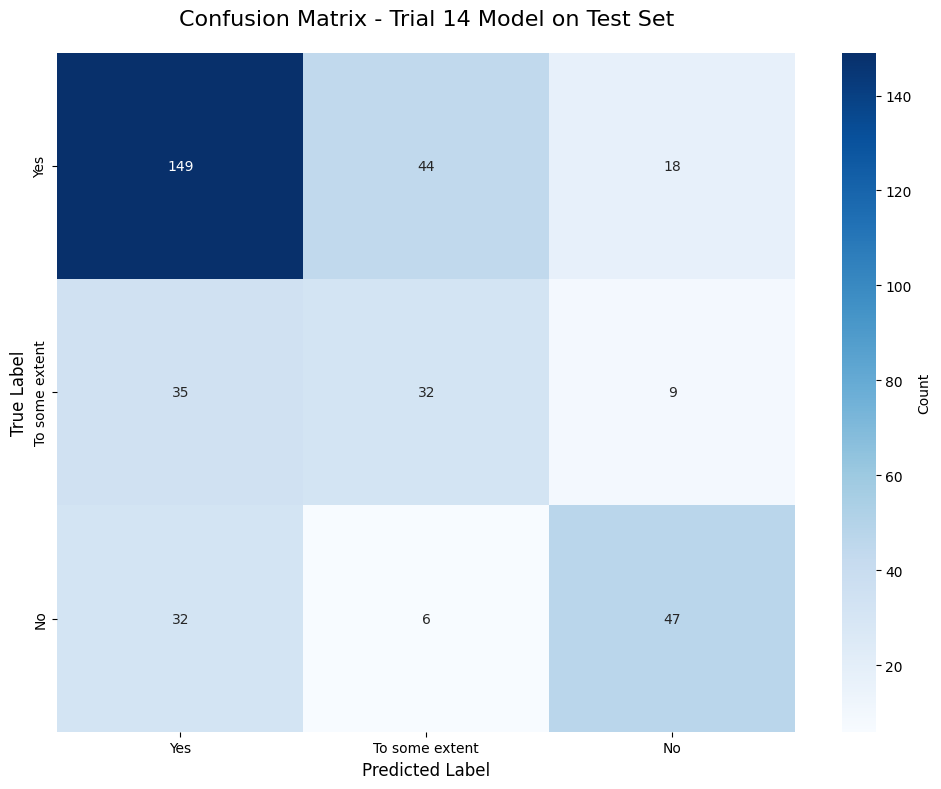

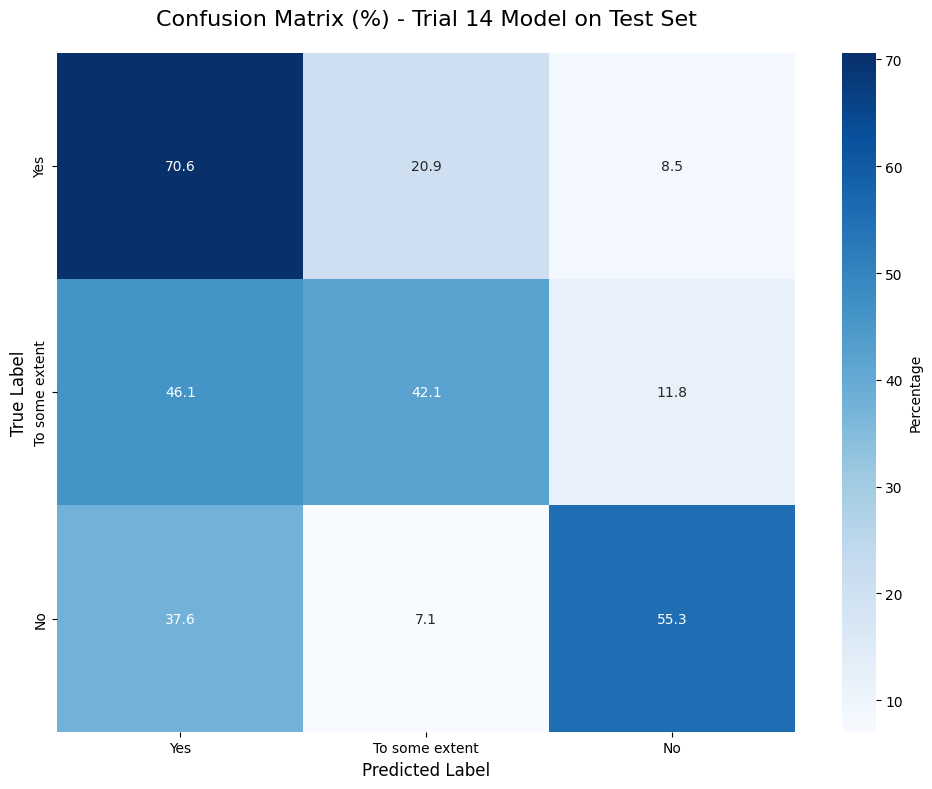

In [16]:
import torch
import numpy as np
from transformers import (
    AutoModelForSequenceClassification, 
    AutoTokenizer,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import (
    f1_score, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== CONFIGURATION ====================
MODEL_CHECKPOINT_PATH = "/DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700"  # Adjust path as needed
MODEL_NAME = "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Label mapping
id2label = {0: "Yes", 1: "To some extent", 2: "No"}
label2id = {"Yes": 0, "To some extent": 1, "No": 2}

print("="*80)
print("EVALUATING TRIAL 14 MODEL ON TEST DATASET")
print("="*80)
print(f"Model checkpoint: {MODEL_CHECKPOINT_PATH}")
print(f"Device: {device}")
print(f"Test dataset: dev_dataset")
print("="*80)

# ==================== LOAD MODEL & TOKENIZER ====================
print("\n[1/5] Loading model and tokenizer...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load the fine-tuned model from checkpoint
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT_PATH,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)

print(f"✓ Model loaded from checkpoint: {MODEL_CHECKPOINT_PATH}")
print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ==================== COMPUTE METRICS FUNCTION ====================
def compute_metrics(pred):
    """Compute comprehensive evaluation metrics"""
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    # Overall metrics
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    
    # Per-class metrics
    f1_per_class = f1_score(labels, preds, average=None, zero_division=0)
    precision_per_class = precision_score(labels, preds, average=None, zero_division=0)
    recall_per_class = recall_score(labels, preds, average=None, zero_division=0)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_yes": f1_per_class[0],
        "f1_to_some_extent": f1_per_class[1],
        "f1_no": f1_per_class[2],
        "precision_yes": precision_per_class[0],
        "precision_to_some_extent": precision_per_class[1],
        "precision_no": precision_per_class[2],
        "recall_yes": recall_per_class[0],
        "recall_to_some_extent": recall_per_class[1],
        "recall_no": recall_per_class[2]
    }

# ==================== SETUP TRAINER ====================
print("\n[2/5] Setting up Trainer for evaluation...")

eval_args = TrainingArguments(
    output_dir="./trial14_evaluation",
    per_device_eval_batch_size=16,  # Can use larger batch for eval
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("✓ Trainer configured")

# ==================== RUN EVALUATION ====================
print("\n[3/5] Running evaluation on dev_dataset...")
print("This may take a few minutes...")

eval_results = trainer.evaluate()

# ==================== DISPLAY RESULTS ====================
print("\n" + "="*80)
print("EVALUATION RESULTS - TRIAL 14 MODEL")
print("="*80)

print(f"\n📊 OVERALL PERFORMANCE")
print(f"{'='*40}")
print(f"  Accuracy:      {eval_results['eval_accuracy']:.4f}")
print(f"  F1 Macro:      {eval_results['eval_f1_macro']:.4f}")
print(f"  F1 Weighted:   {eval_results['eval_f1_weighted']:.4f}")
print(f"  Loss:          {eval_results['eval_loss']:.4f}")

print(f"\n📈 PER-CLASS F1 SCORES")
print(f"{'='*40}")
print(f"  Yes:              {eval_results['eval_f1_yes']:.4f}")
print(f"  To some extent:   {eval_results['eval_f1_to_some_extent']:.4f}")
print(f"  No:               {eval_results['eval_f1_no']:.4f}")

print(f"\n🎯 PER-CLASS PRECISION")
print(f"{'='*40}")
print(f"  Yes:              {eval_results['eval_precision_yes']:.4f}")
print(f"  To some extent:   {eval_results['eval_precision_to_some_extent']:.4f}")
print(f"  No:               {eval_results['eval_precision_no']:.4f}")

print(f"\n📢 PER-CLASS RECALL")
print(f"{'='*40}")
print(f"  Yes:              {eval_results['eval_recall_yes']:.4f}")
print(f"  To some extent:   {eval_results['eval_recall_to_some_extent']:.4f}")
print(f"  No:               {eval_results['eval_recall_no']:.4f}")

# ==================== DETAILED PREDICTIONS ====================
print("\n[4/5] Generating detailed predictions and confusion matrix...")

# Get predictions
predictions = trainer.predict(dev_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
class_names = ["Yes", "To some extent", "No"]
print(classification_report(
    true_labels, 
    pred_labels, 
    target_names=class_names,
    digits=4
))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)
print("\nRows = True Labels, Columns = Predicted Labels")
print(f"\n{'':>20} {'Yes':>12} {'To some extent':>15} {'No':>12}")
print("-" * 65)
for i, true_class in enumerate(class_names):
    print(f"{true_class:>20} {cm[i][0]:>12} {cm[i][1]:>15} {cm[i][2]:>12}")

# Calculate confusion percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
print("\n\nCONFUSION MATRIX (Percentages)")
print("="*80)
print(f"\n{'':>20} {'Yes':>12} {'To some extent':>15} {'No':>12}")
print("-" * 65)
for i, true_class in enumerate(class_names):
    print(f"{true_class:>20} {cm_percentage[i][0]:>11.1f}% {cm_percentage[i][1]:>14.1f}% {cm_percentage[i][2]:>11.1f}%")

# ==================== VISUALIZE CONFUSION MATRIX ====================
print("\n[5/5] Creating confusion matrix visualization...")

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Trial 14 Model on Test Set', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('./trial14_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved as: trial14_confusion_matrix.png")

# Percentage confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_percentage, 
    annot=True, 
    fmt='.1f', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Percentage'}
)
plt.title('Confusion Matrix (%) - Trial 14 Model on Test Set', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('./trial14_confusion_matrix_percentage.png', dpi=300, bbox_inches='tight')
print("✓ Percentage confusion matrix saved as: trial14_confusion_matrix_percentage.png")

# ==================== SAVE RESULTS TO FILE ====================
print("\n[6/6] Saving results to file...")

# Create results dictionary
results_dict = {
    'Model': 'Trial 14 - DeBERTa v3 Base',
    'Checkpoint': MODEL_CHECKPOINT_PATH,
    'Test Dataset': 'dev_dataset',
    'Test Size': len(dev_dataset),
    **{k.replace('eval_', ''): v for k, v in eval_results.items()}
}

# Save as JSON
import json
with open('./trial14_test_results.json', 'w') as f:
    json.dump(results_dict, f, indent=4)
print("✓ Results saved as: trial14_test_results.json")

# Save detailed predictions
predictions_df = pd.DataFrame({
    'true_label': [id2label[label] for label in true_labels],
    'predicted_label': [id2label[label] for label in pred_labels],
    'true_label_id': true_labels,
    'predicted_label_id': pred_labels,
    'correct': true_labels == pred_labels
})

predictions_df.to_csv('./trial14_detailed_predictions.csv', index=False)
print("✓ Detailed predictions saved as: trial14_detailed_predictions.csv")

# ==================== SUMMARY STATISTICS ====================
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

# Class distribution in test set
true_label_counts = pd.Series([id2label[label] for label in true_labels]).value_counts()
pred_label_counts = pd.Series([id2label[label] for label in pred_labels]).value_counts()

print("\n📊 CLASS DISTRIBUTION")
print(f"{'Class':<20} {'True Labels':<15} {'Predicted':<15}")
print("-" * 50)
for class_name in class_names:
    true_count = true_label_counts.get(class_name, 0)
    pred_count = pred_label_counts.get(class_name, 0)
    print(f"{class_name:<20} {true_count:<15} {pred_count:<15}")

# Correct predictions per class
print("\n✓ CORRECT PREDICTIONS PER CLASS")
print(f"{'Class':<20} {'Correct':<12} {'Total':<12} {'Accuracy %':<12}")
print("-" * 60)
for i, class_name in enumerate(class_names):
    correct = cm[i][i]
    total = cm[i].sum()
    accuracy = (correct / total * 100) if total > 0 else 0
    print(f"{class_name:<20} {correct:<12} {total:<12} {accuracy:<11.2f}%")

# Overall correct/incorrect
total_correct = (true_labels == pred_labels).sum()
total_samples = len(true_labels)
print(f"\n{'OVERALL':<20} {total_correct:<12} {total_samples:<12} {(total_correct/total_samples*100):<11.2f}%")

# ==================== FINAL SUMMARY ====================
print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print(f"\n✓ Model: Trial 14 (checkpoint-700)")
print(f"✓ Test samples evaluated: {len(dev_dataset)}")
print(f"✓ Overall F1 Macro: {eval_results['eval_f1_macro']:.4f}")
print(f"✓ Overall Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"\n📁 Files saved:")
print(f"   - trial14_confusion_matrix.png")
print(f"   - trial14_confusion_matrix_percentage.png")
print(f"   - trial14_test_results.json")
print(f"   - trial14_detailed_predictions.csv")
print("\n" + "="*80)

# ==================== IDENTIFY WEAKEST CLASS ====================
f1_scores = {
    "Yes": eval_results['eval_f1_yes'],
    "To some extent": eval_results['eval_f1_to_some_extent'],
    "No": eval_results['eval_f1_no']
}
weakest_class = min(f1_scores, key=f1_scores.get)
strongest_class = max(f1_scores, key=f1_scores.get)

print("\n💡 KEY INSIGHTS")
print("="*80)
print(f"Strongest class: {strongest_class} (F1: {f1_scores[strongest_class]:.4f})")
print(f"Weakest class:   {weakest_class} (F1: {f1_scores[weakest_class]:.4f})")
print(f"F1 spread:       {f1_scores[strongest_class] - f1_scores[weakest_class]:.4f}")

if f1_scores[weakest_class] < 0.50:
    print(f"\n⚠️  WARNING: '{weakest_class}' class has very low F1 (<0.50)")
    print(f"   Consider investigating why this class is difficult to predict.")
    
print("="*80)

## 10c. training using tuned HP

In [18]:
from transformers import TrainingArguments, EarlyStoppingCallback, AutoModelForSequenceClassification
import torch


#TRIAL 47
# ============================================================================
# BEST HYPERPARAMETERS FROM OPTUNA
# ============================================================================
best_params = {
    'learning_rate': 1.8e-05,
    'weight_decay': 0.01,
    'scheduler_type': 'cosine',
    'num_train_epochs': 10,
    'per_device_train_batch_size': 8,
    'warmup_ratio': 0.12,
    'gradient_accumulation_steps': 1,
    'hidden_dropout_prob': 0.15,
    'attention_dropout_prob': 0.15,
    'label_smoothing_factor': 0.0,
    'num_layers_to_freeze': 1,
    'loss_function': 'weighted_ce'
}


print("="*80)
print("TRAINING WITH BEST HYPERPARAMETERS")
print("="*80)
print(f"Learning Rate: {best_params['learning_rate']:.2e}")
print(f"Epochs: {best_params['num_train_epochs']} (increased from 5)")
print(f"Batch Size: {best_params['per_device_train_batch_size']}")
print(f"Gradient Accumulation: {best_params['gradient_accumulation_steps']}")
print(f"Effective Batch Size: {best_params['per_device_train_batch_size'] * best_params['gradient_accumulation_steps']}")
print(f"Frozen Layers: {best_params['num_layers_to_freeze']}")
print(f"Dropout: {best_params['hidden_dropout_prob']:.3f}")
print(f"Loss Function: {best_params['loss_function']}")
print("="*80)

# ============================================================================
# MODEL INITIALIZATION
# ============================================================================
model_final = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=best_params['hidden_dropout_prob'],
    attention_probs_dropout_prob=best_params['attention_dropout_prob']
).to(device)

# Freeze layers as per best configuration
if best_params['num_layers_to_freeze'] > 0:
    # Freeze embeddings
    for param in model_final.deberta.embeddings.parameters():
        param.requires_grad = False
    
    # Freeze encoder layers
    for layer in model_final.deberta.encoder.layer[:best_params['num_layers_to_freeze']]:
        for param in layer.parameters():
            param.requires_grad = False
    
    print(f"\n✓ Frozen first {best_params['num_layers_to_freeze']} layers")

trainable_params = sum(p.numel() for p in model_final.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_final.parameters())
print(f"✓ Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

# ============================================================================
# TRAINING ARGUMENTS
# ============================================================================
training_args = TrainingArguments(
    output_dir="./final_model_extended",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=best_params['learning_rate'],
    per_device_train_batch_size=best_params['per_device_train_batch_size'],
    per_device_eval_batch_size=best_params['per_device_train_batch_size'],
    num_train_epochs=best_params['num_train_epochs'],
    weight_decay=best_params['weight_decay'],
    warmup_ratio=best_params['warmup_ratio'],
    lr_scheduler_type=best_params['scheduler_type'],
    gradient_accumulation_steps=best_params['gradient_accumulation_steps'],
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./final_logs",
    logging_strategy="steps",
    label_smoothing_factor=best_params['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=3,  # Keep only best 3 checkpoints
)

# ============================================================================
# CALLBACKS
# ============================================================================
callbacks = [
    EarlyStoppingCallback(early_stopping_patience=5)  # Increased patience for longer training
]

# ============================================================================
# TRAINER
# ============================================================================
if best_params['loss_function'] == 'weighted_ce':
    trainer = WeightedCETrainer(
        model=model_final,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
        class_weights=class_weights_tensor
    )
else:  # focal_loss
    # Note: focal_gamma wasn't in best_params, using default
    trainer = WeightedCETrainer(
        model=model_final,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
        use_focal_loss=True,
        focal_alpha=class_weights_tensor,
        focal_gamma=2.0  # Default value
    )

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)

# ============================================================================
# TRAIN
# ============================================================================
train_result = trainer.train()

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)
print(f"Final train loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f}s")


# ============================================================================
# EVALUATE ON VALIDATION SET
# ============================================================================
print("\n" + "="*80)
print("EVALUATING ON VALIDATION SET")
print("="*80)
eval_results = trainer.evaluate()

print(f"\n  Validation Loss: {eval_results['eval_loss']:.4f}")
print(f"  Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"  F1 Macro: {eval_results['eval_f1_macro']:.4f}")
print(f"  F1 Weighted: {eval_results['eval_f1_weighted']:.4f}")

print(f"\n  Per-Class Metrics:")
print(f"  {'Class':<20} {'F1':<10} {'Precision':<12} {'Recall':<10}")
print(f"  {'-'*52}")
print(f"  {'Yes':<20} {eval_results['eval_f1_yes']:<10.4f} {eval_results['eval_precision_yes']:<12.4f} {eval_results['eval_recall_yes']:<10.4f}")
print(f"  {'To some extent':<20} {eval_results['eval_f1_to_some_extent']:<10.4f} {eval_results['eval_precision_to_some_extent']:<12.4f} {eval_results['eval_recall_to_some_extent']:<10.4f}")
print(f"  {'No':<20} {eval_results['eval_f1_no']:<10.4f} {eval_results['eval_precision_no']:<12.4f} {eval_results['eval_recall_no']:<10.4f}")

# ============================================================================
# CALCULATE LOSS RATIO (Overfitting Check)
# ============================================================================
train_loss = train_result.training_loss
eval_loss = eval_results['eval_loss']
loss_ratio = train_loss / eval_loss

print(f"\n  === Overfitting Analysis ===")
print(f"  Train Loss: {train_loss:.4f}")
print(f"  Eval Loss: {eval_loss:.4f}")
print(f"  Loss Ratio: {loss_ratio:.4f}")

if loss_ratio < 0.3:
    print(f"  ⚠️  WARNING: Severe overfitting detected!")
elif loss_ratio < 0.5:
    print(f"  ⚠️  Moderate overfitting detected")
elif 0.5 <= loss_ratio <= 1.0:
    print(f"  ✓ Healthy generalization")
else:
    print(f"  ⚠️  Model might be underfitting")

print("="*80)

# ============================================================================
# SAVE FINAL MODEL
# ============================================================================
print("\n" + "="*80)
print("SAVING FINAL MODEL")
print("="*80)

# Save the best model
trainer.save_model("./final_model_best19")
tokenizer.save_pretrained("./final_model_best19")

print("✓ Model saved to: ./final_model_best")
print("✓ Tokenizer saved to: ./final_model_best")

# Save training history
import json
with open("./final_model_best/training_history.json", "w") as f:
    json.dump({
        "best_params": best_params,
        "train_result": {
            "train_loss": float(train_result.training_loss),
            "train_runtime": float(train_result.metrics['train_runtime']),
            
        },
        "eval_results": {k: float(v) if isinstance(v, (int, float)) else v for k, v in eval_results.items()}
    }, f, indent=2)

print("✓ Training history saved to: ./final_model_best/training_history.json")
print("="*80)

# ============================================================================
# OPTIONAL: EVALUATE ON TEST SET (if you have one)
# ============================================================================
# if test_dataset is not None:
#     print("\n" + "="*80)
#     print("EVALUATING ON TEST SET")
#     print("="*80)
#     test_results = trainer.evaluate(test_dataset)
#     print(f"Test F1 Macro: {test_results['eval_f1_macro']:.4f}")
#     print("="*80)

TRAINING WITH BEST HYPERPARAMETERS
Learning Rate: 1.80e-05
Epochs: 10 (increased from 5)
Batch Size: 8
Gradient Accumulation: 1
Effective Batch Size: 8
Frozen Layers: 1
Dropout: 0.150
Loss Function: weighted_ce


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.



✓ Frozen first 1 layers
✓ Trainable parameters: 291,292,163 / 435,064,835 (67.0%)

STARTING TRAINING


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
50,1.103400,1.088881,0.233871,0.132912,0.100339,0.027875,0.000000,0.370861,0.800000,0.000000,0.228106,0.014184,0.000000,0.991150
100,1.095700,1.055905,0.592742,0.410217,0.522042,0.709285,0.000000,0.521368,0.621333,0.000000,0.504132,0.826241,0.000000,0.539823


KeyboardInterrupt: 

In [20]:
from transformers import TrainingArguments, EarlyStoppingCallback, AutoModelForSequenceClassification
import torch


#TRIAL 47
# ============================================================================
# BEST HYPERPARAMETERS FROM OPTUNA
# ============================================================================
# IMPROVED hyperparameters
best_params = {
    'learning_rate': 5e-5,  # ✅ Increased (Optuna had 1.87e-5)
    'weight_decay': 0.10,   # ✅ Compromise between 0.05 and 0.19
    'scheduler_type': 'cosine',  # ✅ Same as Optuna
    'num_train_epochs': 10,  # ✅ Reasonable
    'per_device_train_batch_size': 16,  # ⚠️ KEEP at 8 (Optuna chose this!)
    'warmup_ratio': 0.15,   # ⚠️ Closer to Optuna's 0.169
    'gradient_accumulation_steps': 1,  # ⚠️ KEEP at 2 (Optuna chose this!)
    'hidden_dropout_prob': 0.30,  # ✅ Compromise (Optuna: 0.21, Yours: 0.35)
    'attention_dropout_prob': 0.35,  # ✅ Compromise (Optuna: 0.31, Yours: 0.40)
    'label_smoothing_factor': 0.05,  # ✅ Much lower (critical fix!)
    'num_layers_to_freeze': 1,  # ⚠️ KEEP at 1 (Optuna chose this!)
    'loss_function': 'weighted_ce'
}

print("="*80)
print("TRAINING WITH BEST HYPERPARAMETERS")
print("="*80)
print(f"Learning Rate: {best_params['learning_rate']:.2e}")
print(f"Epochs: {best_params['num_train_epochs']} (increased from 5)")
print(f"Batch Size: {best_params['per_device_train_batch_size']}")
print(f"Gradient Accumulation: {best_params['gradient_accumulation_steps']}")
print(f"Effective Batch Size: {best_params['per_device_train_batch_size'] * best_params['gradient_accumulation_steps']}")
print(f"Frozen Layers: {best_params['num_layers_to_freeze']}")
print(f"Dropout: {best_params['hidden_dropout_prob']:.3f}")
print(f"Loss Function: {best_params['loss_function']}")
print("="*80)

# ============================================================================
# MODEL INITIALIZATION
# ============================================================================
model_final = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=best_params['hidden_dropout_prob'],
    attention_probs_dropout_prob=best_params['attention_dropout_prob']
).to(device)

# Freeze layers as per best configuration
if best_params['num_layers_to_freeze'] > 0:
    # Freeze embeddings
    for param in model_final.deberta.embeddings.parameters():
        param.requires_grad = False
    
    # Freeze encoder layers
    for layer in model_final.deberta.encoder.layer[:best_params['num_layers_to_freeze']]:
        for param in layer.parameters():
            param.requires_grad = False
    
    print(f"\n✓ Frozen first {best_params['num_layers_to_freeze']} layers")

trainable_params = sum(p.numel() for p in model_final.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_final.parameters())
print(f"✓ Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

# ============================================================================
# TRAINING ARGUMENTS
# ============================================================================
training_args = TrainingArguments(
    output_dir="./final_model_extended",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=best_params['learning_rate'],
    per_device_train_batch_size=best_params['per_device_train_batch_size'],
    per_device_eval_batch_size=best_params['per_device_train_batch_size'],
    num_train_epochs=best_params['num_train_epochs'],
    weight_decay=best_params['weight_decay'],
    warmup_ratio=best_params['warmup_ratio'],
    lr_scheduler_type=best_params['scheduler_type'],
    gradient_accumulation_steps=best_params['gradient_accumulation_steps'],
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./final_logs",
    logging_strategy="steps",
    label_smoothing_factor=best_params['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=3,  # Keep only best 3 checkpoints
)

# ============================================================================
# CALLBACKS
# ============================================================================
callbacks = [
    EarlyStoppingCallback(early_stopping_patience=5)  # Increased patience for longer training
]

# ============================================================================
# TRAINER
# ============================================================================
if best_params['loss_function'] == 'weighted_ce':
    trainer = WeightedCETrainer(
        model=model_final,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
        class_weights=class_weights_tensor
    )
else:  # focal_loss
    # Note: focal_gamma wasn't in best_params, using default
    trainer = WeightedCETrainer(
        model=model_final,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
        use_focal_loss=True,
        focal_alpha=class_weights_tensor,
        focal_gamma=2.0  # Default value
    )

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)

# ============================================================================
# TRAIN
# ============================================================================
train_result = trainer.train()

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)
print(f"Final train loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f}s")


# ============================================================================
# EVALUATE ON VALIDATION SET
# ============================================================================
print("\n" + "="*80)
print("EVALUATING ON VALIDATION SET")
print("="*80)
eval_results = trainer.evaluate()

print(f"\n  Validation Loss: {eval_results['eval_loss']:.4f}")
print(f"  Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"  F1 Macro: {eval_results['eval_f1_macro']:.4f}")
print(f"  F1 Weighted: {eval_results['eval_f1_weighted']:.4f}")

print(f"\n  Per-Class Metrics:")
print(f"  {'Class':<20} {'F1':<10} {'Precision':<12} {'Recall':<10}")
print(f"  {'-'*52}")
print(f"  {'Yes':<20} {eval_results['eval_f1_yes']:<10.4f} {eval_results['eval_precision_yes']:<12.4f} {eval_results['eval_recall_yes']:<10.4f}")
print(f"  {'To some extent':<20} {eval_results['eval_f1_to_some_extent']:<10.4f} {eval_results['eval_precision_to_some_extent']:<12.4f} {eval_results['eval_recall_to_some_extent']:<10.4f}")
print(f"  {'No':<20} {eval_results['eval_f1_no']:<10.4f} {eval_results['eval_precision_no']:<12.4f} {eval_results['eval_recall_no']:<10.4f}")

# ============================================================================
# CALCULATE LOSS RATIO (Overfitting Check)
# ============================================================================
train_loss = train_result.training_loss
eval_loss = eval_results['eval_loss']
loss_ratio = train_loss / eval_loss

print(f"\n  === Overfitting Analysis ===")
print(f"  Train Loss: {train_loss:.4f}")
print(f"  Eval Loss: {eval_loss:.4f}")
print(f"  Loss Ratio: {loss_ratio:.4f}")

if loss_ratio < 0.3:
    print(f"  ⚠️  WARNING: Severe overfitting detected!")
elif loss_ratio < 0.5:
    print(f"  ⚠️  Moderate overfitting detected")
elif 0.5 <= loss_ratio <= 1.0:
    print(f"  ✓ Healthy generalization")
else:
    print(f"  ⚠️  Model might be underfitting")

print("="*80)

# ============================================================================
# SAVE FINAL MODEL
# ============================================================================
print("\n" + "="*80)
print("SAVING FINAL MODEL")
print("="*80)

# Save the best model
trainer.save_model("./final_model_best47b")
tokenizer.save_pretrained("./final_model_best47b")

print("✓ Model saved to: ./final_model_best")
print("✓ Tokenizer saved to: ./final_model_best")

# Save training history
import json
with open("./final_model_best/training_history.json", "w") as f:
    json.dump({
        "best_params": best_params,
        "train_result": {
            "train_loss": float(train_result.training_loss),
            "train_runtime": float(train_result.metrics['train_runtime']),
            
        },
        "eval_results": {k: float(v) if isinstance(v, (int, float)) else v for k, v in eval_results.items()}
    }, f, indent=2)

print("✓ Training history saved to: ./final_model_best/training_history.json")
print("="*80)

# ============================================================================
# OPTIONAL: EVALUATE ON TEST SET (if you have one)
# ============================================================================
# if test_dataset is not None:
#     print("\n" + "="*80)
#     print("EVALUATING ON TEST SET")
#     print("="*80)
#     test_results = trainer.evaluate(test_dataset)
#     print(f"Test F1 Macro: {test_results['eval_f1_macro']:.4f}")
#     print("="*80)

TRAINING WITH BEST HYPERPARAMETERS
Learning Rate: 5.00e-05
Epochs: 10 (increased from 5)
Batch Size: 16
Gradient Accumulation: 1
Effective Batch Size: 16
Frozen Layers: 1
Dropout: 0.300
Loss Function: weighted_ce


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.



✓ Frozen first 1 layers
✓ Trainable parameters: 291,292,163 / 435,064,835 (67.0%)

STARTING TRAINING


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
50,1.111600,1.082179,0.427419,0.312561,0.390759,0.547573,0.390110,0.000000,0.605150,0.269962,0.000000,0.500000,0.702970,0.000000
100,1.107100,1.098704,0.203629,0.112786,0.068900,0.000000,0.338358,0.000000,0.000000,0.203629,0.000000,0.000000,1.000000,0.000000
150,1.109400,1.100167,0.203629,0.112786,0.068900,0.000000,0.338358,0.000000,0.000000,0.203629,0.000000,0.000000,1.000000,0.000000
200,1.104200,1.099655,0.203629,0.112786,0.068900,0.000000,0.338358,0.000000,0.000000,0.203629,0.000000,0.000000,1.000000,0.000000
250,1.109900,1.099056,0.568548,0.241645,0.412161,0.724936,0.000000,0.000000,0.568548,0.000000,0.000000,1.000000,0.000000,0.000000
300,1.101700,1.100748,0.227823,0.123700,0.084545,0.000000,0.000000,0.371100,0.000000,0.000000,0.227823,0.000000,0.000000,1.000000



TRAINING COMPLETED
Final train loss: 1.1073
Training time: 418.38s

EVALUATING ON VALIDATION SET



  Validation Loss: 1.0822
  Accuracy: 0.4274
  F1 Macro: 0.3126
  F1 Weighted: 0.3908

  Per-Class Metrics:
  Class                F1         Precision    Recall    
  ----------------------------------------------------
  Yes                  0.5476     0.6052       0.5000    
  To some extent       0.3901     0.2700       0.7030    
  No                   0.0000     0.0000       0.0000    

  === Overfitting Analysis ===
  Train Loss: 1.1073
  Eval Loss: 1.0822
  Loss Ratio: 1.0232
  ⚠️  Model might be underfitting

SAVING FINAL MODEL
✓ Model saved to: ./final_model_best
✓ Tokenizer saved to: ./final_model_best
✓ Training history saved to: ./final_model_best/training_history.json


In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback, AutoModelForSequenceClassification
import torch
#
# ============================================================================
# BEST HYPERPARAMETERS FROM OPTUNA TRIAL 24
# ============================================================================
best_params = {
    'learning_rate': 5.522575799284269e-06,
    'weight_decay': 0.10086651585664186,
    'scheduler_type': 'linear',
    'num_train_epochs': 10,  # INCREASED from 5 to 15
    'per_device_train_batch_size': 8,
    'warmup_ratio': 0.22787839671852606,
    'gradient_accumulation_steps': 4,
    'hidden_dropout_prob': 0.10140509658134303,
    'attention_dropout_prob': 0.2132912365303205,
    'label_smoothing_factor': 0.11554520706781476,
    'num_layers_to_freeze': 7,
    'loss_function': 'weighted_ce'
}

print("="*80)
print("TRAINING WITH BEST HYPERPARAMETERS")
print("="*80)
print(f"Learning Rate: {best_params['learning_rate']:.2e}")
print(f"Epochs: {best_params['num_train_epochs']} (increased from 5)")
print(f"Batch Size: {best_params['per_device_train_batch_size']}")
print(f"Gradient Accumulation: {best_params['gradient_accumulation_steps']}")
print(f"Effective Batch Size: {best_params['per_device_train_batch_size'] * best_params['gradient_accumulation_steps']}")
print(f"Frozen Layers: {best_params['num_layers_to_freeze']}")
print(f"Dropout: {best_params['hidden_dropout_prob']:.3f}")
print(f"Loss Function: {best_params['loss_function']}")
print("="*80)

# ============================================================================
# MODEL INITIALIZATION
# ============================================================================
model_final = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=best_params['hidden_dropout_prob'],
    attention_probs_dropout_prob=best_params['attention_dropout_prob']
).to(device)

# Freeze layers as per best configuration
if best_params['num_layers_to_freeze'] > 0:
    # Freeze embeddings
    for param in model_final.deberta.embeddings.parameters():
        param.requires_grad = False
    
    # Freeze encoder layers
    for layer in model_final.deberta.encoder.layer[:best_params['num_layers_to_freeze']]:
        for param in layer.parameters():
            param.requires_grad = False
    
    print(f"\n✓ Frozen first {best_params['num_layers_to_freeze']} layers")

trainable_params = sum(p.numel() for p in model_final.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_final.parameters())
print(f"✓ Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

# ============================================================================
# TRAINING ARGUMENTS
# ============================================================================
training_args = TrainingArguments(
    output_dir="./final_model_extended",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=best_params['learning_rate'],
    per_device_train_batch_size=best_params['per_device_train_batch_size'],
    per_device_eval_batch_size=best_params['per_device_train_batch_size'],
    num_train_epochs=best_params['num_train_epochs'],
    weight_decay=best_params['weight_decay'],
    warmup_ratio=best_params['warmup_ratio'],
    lr_scheduler_type=best_params['scheduler_type'],
    gradient_accumulation_steps=best_params['gradient_accumulation_steps'],
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./final_logs",
    logging_strategy="steps",
    label_smoothing_factor=best_params['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=3,  # Keep only best 3 checkpoints
)

# ============================================================================
# CALLBACKS
# ============================================================================
callbacks = [
    EarlyStoppingCallback(early_stopping_patience=4)  # Increased patience for longer training
]

# ============================================================================
# TRAINER
# ============================================================================
if best_params['loss_function'] == 'weighted_ce':
    trainer = WeightedCETrainer(
        model=model_final,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
        class_weights=class_weights_tensor
    )
else:  # focal_loss
    # Note: focal_gamma wasn't in best_params, using default
    trainer = WeightedCETrainer(
        model=model_final,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
        use_focal_loss=True,
        focal_alpha=class_weights_tensor,
        focal_gamma=2.0  # Default value
    )

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)

# ============================================================================
# TRAIN
# ============================================================================
train_result = trainer.train()

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)
print(f"Final train loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f}s")


# ============================================================================
# EVALUATE ON VALIDATION SET
# ============================================================================
print("\n" + "="*80)
print("EVALUATING ON VALIDATION SET")
print("="*80)
eval_results = trainer.evaluate()

print(f"\n  Validation Loss: {eval_results['eval_loss']:.4f}")
print(f"  Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"  F1 Macro: {eval_results['eval_f1_macro']:.4f}")
print(f"  F1 Weighted: {eval_results['eval_f1_weighted']:.4f}")

print(f"\n  Per-Class Metrics:")
print(f"  {'Class':<20} {'F1':<10} {'Precision':<12} {'Recall':<10}")
print(f"  {'-'*52}")
print(f"  {'Yes':<20} {eval_results['eval_f1_yes']:<10.4f} {eval_results['eval_precision_yes']:<12.4f} {eval_results['eval_recall_yes']:<10.4f}")
print(f"  {'To some extent':<20} {eval_results['eval_f1_to_some_extent']:<10.4f} {eval_results['eval_precision_to_some_extent']:<12.4f} {eval_results['eval_recall_to_some_extent']:<10.4f}")
print(f"  {'No':<20} {eval_results['eval_f1_no']:<10.4f} {eval_results['eval_precision_no']:<12.4f} {eval_results['eval_recall_no']:<10.4f}")

# ============================================================================
# CALCULATE LOSS RATIO (Overfitting Check)
# ============================================================================
train_loss = train_result.training_loss
eval_loss = eval_results['eval_loss']
loss_ratio = train_loss / eval_loss

print(f"\n  === Overfitting Analysis ===")
print(f"  Train Loss: {train_loss:.4f}")
print(f"  Eval Loss: {eval_loss:.4f}")
print(f"  Loss Ratio: {loss_ratio:.4f}")

if loss_ratio < 0.3:
    print(f"  ⚠️  WARNING: Severe overfitting detected!")
elif loss_ratio < 0.5:
    print(f"  ⚠️  Moderate overfitting detected")
elif 0.5 <= loss_ratio <= 1.0:
    print(f"  ✓ Healthy generalization")
else:
    print(f"  ⚠️  Model might be underfitting")

print("="*80)

# ============================================================================
# SAVE FINAL MODEL
# ============================================================================
print("\n" + "="*80)
print("SAVING FINAL MODEL")
print("="*80)

# Save the best model
trainer.save_model("./final_model_best24")
tokenizer.save_pretrained("./final_model_best24")

print("✓ Model saved to: ./final_model_best24")
print("✓ Tokenizer saved to: ./final_model_best24")

# Save training history
import json
with open("./final_model_best/training_history.json", "w") as f:
    json.dump({
        "best_params": best_params,
        "train_result": {
            "train_loss": float(train_result.training_loss),
            "train_runtime": float(train_result.metrics['train_runtime']),
            
        },
        "eval_results": {k: float(v) if isinstance(v, (int, float)) else v for k, v in eval_results.items()}
    }, f, indent=2)

print("✓ Training history saved to: ./final_model_best/training_history.json")
print("="*80)

# ============================================================================
# OPTIONAL: EVALUATE ON TEST SET (if you have one)
# ============================================================================
# if test_dataset is not None:
#     print("\n" + "="*80)
#     print("EVALUATING ON TEST SET")
#     print("="*80)
#     test_results = trainer.evaluate(test_dataset)
#     print(f"Test F1 Macro: {test_results['eval_f1_macro']:.4f}")
#     print("="*80)

TRAINING WITH BEST HYPERPARAMETERS
Learning Rate: 5.52e-06
Epochs: 10 (increased from 5)
Batch Size: 8
Gradient Accumulation: 4
Effective Batch Size: 32
Frozen Layers: 7
Dropout: 0.101
Loss Function: weighted_ce


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.



✓ Frozen first 7 layers
✓ Trainable parameters: 215,714,819 / 435,064,835 (49.6%)

STARTING TRAINING


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
50,1.097900,1.080006,0.338710,0.254726,0.293876,0.378897,0.385281,0.000000,0.585185,0.246537,0.000000,0.280142,0.881188,0.000000
100,1.081200,1.064807,0.368952,0.339888,0.356532,0.391960,0.385281,0.242424,0.672414,0.246537,0.842105,0.276596,0.881188,0.141593
150,1.052700,1.047005,0.372984,0.364518,0.366805,0.372703,0.385281,0.335570,0.717172,0.246537,0.694444,0.251773,0.881188,0.221239
200,1.035000,1.051683,0.377016,0.370742,0.372847,0.377953,0.385281,0.348993,0.727273,0.246537,0.722222,0.255319,0.881188,0.230088


KeyboardInterrupt: 

In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback, AutoModelForSequenceClassification
import torch
#
# ============================================================================
# BEST HYPERPARAMETERS FROM OPTUNA TRIAL 21
# ============================================================================
best_params = {
    'learning_rate': 6.2033332083018535e-06,
    'weight_decay': 0.0926828262521827,
    'scheduler_type': 'linear',
    'num_train_epochs': 15,  # INCREASED from 5 to 15
    'per_device_train_batch_size': 8,
    'warmup_ratio': 0.2994853718297317,
    'gradient_accumulation_steps': 4,
    'hidden_dropout_prob': 0.16015756158095618,
    'attention_dropout_prob': 0.11308848669884615,
    'label_smoothing_factor': 0.13921215767717923,
    'num_layers_to_freeze': 6,
    'loss_function': 'weighted_ce'
}

print("="*80)
print("TRAINING WITH BEST HYPERPARAMETERS")
print("="*80)
print(f"Learning Rate: {best_params['learning_rate']:.2e}")
print(f"Epochs: {best_params['num_train_epochs']} (increased from 5)")
print(f"Batch Size: {best_params['per_device_train_batch_size']}")
print(f"Gradient Accumulation: {best_params['gradient_accumulation_steps']}")
print(f"Effective Batch Size: {best_params['per_device_train_batch_size'] * best_params['gradient_accumulation_steps']}")
print(f"Frozen Layers: {best_params['num_layers_to_freeze']}")
print(f"Dropout: {best_params['hidden_dropout_prob']:.3f}")
print(f"Loss Function: {best_params['loss_function']}")
print("="*80)

# ============================================================================
# MODEL INITIALIZATION
# ============================================================================
model_final = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=best_params['hidden_dropout_prob'],
    attention_probs_dropout_prob=best_params['attention_dropout_prob']
).to(device)

# Freeze layers as per best configuration
if best_params['num_layers_to_freeze'] > 0:
    # Freeze embeddings
    for param in model_final.deberta.embeddings.parameters():
        param.requires_grad = False
    
    # Freeze encoder layers
    for layer in model_final.deberta.encoder.layer[:best_params['num_layers_to_freeze']]:
        for param in layer.parameters():
            param.requires_grad = False
    
    print(f"\n✓ Frozen first {best_params['num_layers_to_freeze']} layers")

trainable_params = sum(p.numel() for p in model_final.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_final.parameters())
print(f"✓ Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

# ============================================================================
# TRAINING ARGUMENTS
# ============================================================================
training_args = TrainingArguments(
    output_dir="./final_model_extended",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    logging_steps=50,
    learning_rate=best_params['learning_rate'],
    per_device_train_batch_size=best_params['per_device_train_batch_size'],
    per_device_eval_batch_size=best_params['per_device_train_batch_size'],
    num_train_epochs=best_params['num_train_epochs'],
    weight_decay=best_params['weight_decay'],
    warmup_ratio=best_params['warmup_ratio'],
    lr_scheduler_type=best_params['scheduler_type'],
    gradient_accumulation_steps=best_params['gradient_accumulation_steps'],
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    logging_dir="./final_logs",
    logging_strategy="steps",
    label_smoothing_factor=best_params['label_smoothing_factor'],
    max_grad_norm=1.0,
    report_to="none",
    save_total_limit=3,  # Keep only best 3 checkpoints
)

# ============================================================================
# CALLBACKS
# ============================================================================
callbacks = [
    EarlyStoppingCallback(early_stopping_patience=4)  # Increased patience for longer training
]

# ============================================================================
# TRAINER
# ============================================================================
if best_params['loss_function'] == 'weighted_ce':
    trainer = WeightedCETrainer(
        model=model_final,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
        class_weights=class_weights_tensor
    )
else:  # focal_loss
    # Note: focal_gamma wasn't in best_params, using default
    trainer = WeightedCETrainer(
        model=model_final,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=callbacks,
        use_focal_loss=True,
        focal_alpha=class_weights_tensor,
        focal_gamma=2.0  # Default value
    )

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)

# ============================================================================
# TRAIN
# ============================================================================
train_result = trainer.train()

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)
print(f"Final train loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f}s")


# ============================================================================
# EVALUATE ON VALIDATION SET
# ============================================================================
print("\n" + "="*80)
print("EVALUATING ON VALIDATION SET")
print("="*80)
eval_results = trainer.evaluate()

print(f"\n  Validation Loss: {eval_results['eval_loss']:.4f}")
print(f"  Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"  F1 Macro: {eval_results['eval_f1_macro']:.4f}")
print(f"  F1 Weighted: {eval_results['eval_f1_weighted']:.4f}")

print(f"\n  Per-Class Metrics:")
print(f"  {'Class':<20} {'F1':<10} {'Precision':<12} {'Recall':<10}")
print(f"  {'-'*52}")
print(f"  {'Yes':<20} {eval_results['eval_f1_yes']:<10.4f} {eval_results['eval_precision_yes']:<12.4f} {eval_results['eval_recall_yes']:<10.4f}")
print(f"  {'To some extent':<20} {eval_results['eval_f1_to_some_extent']:<10.4f} {eval_results['eval_precision_to_some_extent']:<12.4f} {eval_results['eval_recall_to_some_extent']:<10.4f}")
print(f"  {'No':<20} {eval_results['eval_f1_no']:<10.4f} {eval_results['eval_precision_no']:<12.4f} {eval_results['eval_recall_no']:<10.4f}")

# ============================================================================
# CALCULATE LOSS RATIO (Overfitting Check)
# ============================================================================
train_loss = train_result.training_loss
eval_loss = eval_results['eval_loss']
loss_ratio = train_loss / eval_loss

print(f"\n  === Overfitting Analysis ===")
print(f"  Train Loss: {train_loss:.4f}")
print(f"  Eval Loss: {eval_loss:.4f}")
print(f"  Loss Ratio: {loss_ratio:.4f}")

if loss_ratio < 0.3:
    print(f"  ⚠️  WARNING: Severe overfitting detected!")
elif loss_ratio < 0.5:
    print(f"  ⚠️  Moderate overfitting detected")
elif 0.5 <= loss_ratio <= 1.0:
    print(f"  ✓ Healthy generalization")
else:
    print(f"  ⚠️  Model might be underfitting")

print("="*80)

# ============================================================================
# SAVE FINAL MODEL
# ============================================================================
print("\n" + "="*80)
print("SAVING FINAL MODEL")
print("="*80)

# Save the best model
trainer.save_model("./final_model_best21")
tokenizer.save_pretrained("./final_model_best21")

print("✓ Model saved to: ./final_model_best21")
print("✓ Tokenizer saved to: ./final_model_best21")

# Save training history
import json
with open("./final_model_best/training_history.json", "w") as f:
    json.dump({
        "best_params": best_params,
        "train_result": {
            "train_loss": float(train_result.training_loss),
            "train_runtime": float(train_result.metrics['train_runtime']),
            
        },
        "eval_results": {k: float(v) if isinstance(v, (int, float)) else v for k, v in eval_results.items()}
    }, f, indent=2)

print("✓ Training history saved to: ./final_model_best/training_history.json")
print("="*80)

# ============================================================================
# OPTIONAL: EVALUATE ON TEST SET (if you have one)
# ============================================================================
# if test_dataset is not None:
#     print("\n" + "="*80)
#     print("EVALUATING ON TEST SET")
#     print("="*80)
#     test_results = trainer.evaluate(test_dataset)
#     print(f"Test F1 Macro: {test_results['eval_f1_macro']:.4f}")
#     print("="*80)

## 11. Evaluate on Validation Set (from trainset)

In [ ]:
print(f"{'='*60}")
print("VALIDATION SET EVALUATION (from trainset)")
print(f"{'='*60}\n")

# Evaluate on validation set
val_results = trainer.evaluate(val_dataset)

print("Validation Set Metrics:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")
print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

# Get predictions
val_predictions = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_predictions.predictions, axis=1)
val_true_labels = val_predictions.label_ids

# Confusion Matrix
cm_val = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Yes', 'To some extent', 'No'],
            yticklabels=['Yes', 'To some extent', 'No'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: confusion_matrix_validation.png")

# Detailed Classification Report
print(f"\n{'='*60}")
print("Classification Report - Validation Set")
print(f"{'='*60}")
print(classification_report(val_true_labels, val_pred_labels, 
                          target_names=['Yes', 'To some extent', 'No'],
                          digits=4))

VALIDATION SET EVALUATION (from trainset)



NameError: name 'trainer' is not defined

## 12. Make Predictions on Dev and Test Sets (No Labels)

In [17]:


def load_test_data(file_path):
    """Load test data WITHOUT annotations (for inference only)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        #answer_key = conversation['answer_key']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            samples.append({
                'conversation_id': conv_id,
                'conversation_history': conv_history,
                #'answer_key': answer_key,
                'model': model_name,
                'tutor_response': response_data['response']
                
            })
    
    return pd.DataFrame(samples)

# Load datasets
print("Loading datasets...")
print("Note: Train set has labels, Dev/Test sets are for prediction only")
#train_df = load_train_data('../../data/trainset_with_answers.json')
#dev_df = load_test_data('../../data/dev_testset.json')
#test_df = load_test_data('../../data/testset_with_answers.json')
testing_df = load_test_data('../../data/testset.json')




Loading datasets...
Note: Train set has labels, Dev/Test sets are for prediction only


In [18]:
import pandas as pd

def extract_formatted_text(conversation_history):
    """
    Extracts the question (including the "The question is:") and all student 
    dialogues, with the first dialogue prefixed with "Student:".
    """
    question_text = ""
    student_dialogues = []

    # 1. Extract the question text
    try:
        question_part = conversation_history.split("The question is:")[1]
        question_body = question_part.split("Student:")[0].strip()
        # MODIFICATION: Prepend the phrase back to the question
        question_text = "The question is: " + question_body
    except IndexError:
        return "" # Return empty string if the format is unexpected

    # 2. Extract all student dialogues (without the tag initially)
    parts = conversation_history.split("Student:")
    for part in parts[1:]:
        student_text = part.split("Tutor:")[0].strip()
        student_dialogues.append(student_text)
        
    # 3. MODIFICATION: Add "Student:" prefix to the first dialogue only
    if student_dialogues:
        student_dialogues[0] = "Student: " + student_dialogues[0]
        
    # 4. Combine the question and all dialogues
    # Start with the question text
    final_parts = [question_text]
    
    # Add the (now formatted) student dialogues
    if student_dialogues:
        final_parts.extend(student_dialogues)
        
    # Join everything with a single space
    return " ".join(final_parts)


original_testing_df =load_test_data('../../data/testset.json')
# Create a new column 'cleaned_text' by applying the function
print("Cleaning conversation history...")
#train_df['conversation_history'] = train_df['conversation_history'].apply(extract_formatted_text)
print("Done.")

testing_df['conversation_history'] = testing_df['conversation_history'].apply(extract_formatted_text)

Cleaning conversation history...
Done.


In [19]:
class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Combine conversation history and tutor response

        text = f"{row['conversation_history']} [SEP] Tutor name : {row['model']} [SEP] Tutor Response : {row['tutor_response']}"



        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        
        return item

# Create datasets
MAX_LENGTH = 512


# Create datasets
# train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
# val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)
#dev_dataset = MistakeIdentificationDataset(dev_df, tokenizer, MAX_LENGTH, has_labels=False)
testing_dataset = MistakeIdentificationDataset(testing_df, tokenizer, MAX_LENGTH, has_labels=False)

print(f"\nDatasets created successfully!")



# sample_inf = dev_dataset[0]
# print(f"\nSample from inference dataset (dev):")
# print(f"  Input IDs shape: {sample_inf['input_ids'].shape}")
# print(f"  Attention mask shape: {sample_inf['attention_mask'].shape}")
# print(f"  Has label: {'labels' in sample_inf}")


Datasets created successfully!


In [43]:
# import torch
# from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig

# # ---------------------------
# # Option 1: If you still have the Trainer object in memory
# # ---------------------------
# try:
#     print("Checking trainer model...")
#     print("Model config name_or_path:", trainer.model.config._name_or_path)
#     print("Number of labels:", trainer.model.config.num_labels)
#     print("Number of parameters:", sum(p.numel() for p in trainer.model.parameters()))
#     print("Tokenizer:", trainer.tokenizer.name_or_path)
# except NameError:
#     print("Trainer object not in memory. Skipping Option 1...")

# # ---------------------------
# # Option 2: Load from saved checkpoint folder
# # ---------------------------
# model_path = "/DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/final_model_best19"  # path to your saved model folder

# # Load config to check original pretrained model and number of labels
# config = AutoConfig.from_pretrained(model_path)
# print("\nLoaded config from folder:")
# print("Model name_or_path:", config._name_or_path)
# print("Number of labels:", config.num_labels)

# # Load tokenizer
# tokenizer = AutoTokenizer.from_pretrained(model_path)
# print("Tokenizer:", tokenizer.name_or_path)

# # Load model
# model = AutoModelForSequenceClassification.from_pretrained(model_path)
# print("Number of parameters:", sum(p.numel() for p in model.parameters()))

# # ---------------------------
# # Optional: Check device placement
# # ---------------------------
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(device)
# print("Model loaded on device:", device)


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


Checking trainer model...
Model config name_or_path: /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700
Number of labels: 3
Number of parameters: 184424451
Tokenizer: microsoft/deberta-v3-base

Loaded config from folder:
Model name_or_path: /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/final_model_best19
Number of labels: 3
Tokenizer: /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/final_model_best19
Number of parameters: 435064835
Model loaded on device: cuda


In [50]:
import torch
import numpy as np
import pickle
import json
from pathlib import Path
from transformers import AutoModelForSequenceClassification, AutoTokenizer

print("="*80)
print("SAVING ENSEMBLE MODEL & RE-EVALUATING")
print("="*80)

# ==================== CREATE ENSEMBLE CLASS ====================
print("\n[STEP 1/5] Creating EnsembleModel class...")

class EnsembleModel:
    """
    Ensemble of Trial 14 and HEM models with weighted averaging
    """
    def __init__(self, model_trial14_path, model_hem_path, weight_trial14=0.6, device='cuda'):
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.weight_trial14 = weight_trial14
        self.weight_hem = 1 - weight_trial14
        
        # Load models
        print(f"  Loading Trial 14 model from {model_trial14_path}...")
        self.model_trial14 = AutoModelForSequenceClassification.from_pretrained(
            model_trial14_path,
            num_labels=3
        ).to(self.device)
        self.model_trial14.eval()
        
        print(f"  Loading HEM model from {model_hem_path}...")
        self.model_hem = AutoModelForSequenceClassification.from_pretrained(
            model_hem_path,
            num_labels=3
        ).to(self.device)
        self.model_hem.eval()
        
        # Load tokenizer (same for both)
        self.tokenizer = AutoTokenizer.from_pretrained(model_trial14_path)
        
        print(f"  ✓ Ensemble initialized: {self.weight_trial14:.1f} Trial14 + {self.weight_hem:.1f} HEM")
    
    def predict(self, input_ids, attention_mask):
        """
        Make ensemble prediction for a batch
        Returns: logits (for compatibility), probabilities
        """
        with torch.no_grad():
            # Get predictions from both models
            outputs_trial14 = self.model_trial14(input_ids=input_ids, attention_mask=attention_mask)
            outputs_hem = self.model_hem(input_ids=input_ids, attention_mask=attention_mask)
            
            # Get probabilities
            probs_trial14 = torch.softmax(outputs_trial14.logits, dim=-1)
            probs_hem = torch.softmax(outputs_hem.logits, dim=-1)
            
            # Weighted average
            ensemble_probs = (self.weight_trial14 * probs_trial14 + 
                            self.weight_hem * probs_hem)
            
            # Convert back to logits (for compatibility with standard pipelines)
            ensemble_logits = torch.log(ensemble_probs + 1e-10)
            
            return ensemble_logits, ensemble_probs
    
    def predict_single(self, text):
        """
        Predict for a single text input
        Returns: predicted class, probabilities
        """
        # Tokenize
        inputs = self.tokenizer(
            text,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=512
        )
        
        input_ids = inputs['input_ids'].to(self.device)
        attention_mask = inputs['attention_mask'].to(self.device)
        
        # Get ensemble prediction
        _, probs = self.predict(input_ids, attention_mask)
        
        predicted_class = torch.argmax(probs, dim=-1).item()
        
        return predicted_class, probs[0].cpu().numpy()
    
    def predict_batch(self, texts, batch_size=8):
        """
        Predict for a list of texts
        Returns: predictions, probabilities
        """
        all_predictions = []
        all_probabilities = []
        
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            
            # Tokenize batch
            inputs = self.tokenizer(
                batch_texts,
                return_tensors='pt',
                truncation=True,
                padding=True,
                max_length=512
            )
            
            input_ids = inputs['input_ids'].to(self.device)
            attention_mask = inputs['attention_mask'].to(self.device)
            
            # Get ensemble predictions
            _, probs = self.predict(input_ids, attention_mask)
            
            predictions = torch.argmax(probs, dim=-1).cpu().numpy()
            probabilities = probs.cpu().numpy()
            
            all_predictions.extend(predictions)
            all_probabilities.extend(probabilities)
        
        return np.array(all_predictions), np.array(all_probabilities)
    
    def save(self, save_path):
        """
        Save ensemble configuration (models are already saved separately)
        """
        save_path = Path(save_path)
        save_path.mkdir(exist_ok=True)
        
        config = {
            'model_trial14_path': str(self.model_trial14.config._name_or_path),
            'model_hem_path': str(self.model_hem.config._name_or_path),
            'weight_trial14': self.weight_trial14,
            'weight_hem': self.weight_hem,
            'ensemble_type': 'weighted_average'
        }
        
        with open(save_path / 'ensemble_config.json', 'w') as f:
            json.dump(config, f, indent=4)
        
        # Save tokenizer
        self.tokenizer.save_pretrained(save_path)
        
        print(f"✓ Ensemble configuration saved to {save_path}")
    
    @classmethod
    def load(cls, load_path, device='cuda'):
        """
        Load ensemble from saved configuration
        """
        load_path = Path(load_path)
        
        with open(load_path / 'ensemble_config.json', 'r') as f:
            config = json.load(f)
        
        return cls(
            model_trial14_path=config['model_trial14_path'],
            model_hem_path=config['model_hem_path'],
            weight_trial14=config['weight_trial14'],
            device=device
        )

print("✓ EnsembleModel class created")

# ==================== INSTANTIATE AND SAVE ENSEMBLE ====================
print("\n[STEP 2/5] Creating and saving ensemble model...")

ensemble_model = EnsembleModel(
    model_trial14_path=TRIAL14_PATH,
    model_hem_path=HEM_PATH,
    weight_trial14=0.6,
    device=device
)

# Save ensemble
ensemble_save_path = "./ensemble_trial14_hem_best"
ensemble_model.save(ensemble_save_path)

print(f"✓ Ensemble model saved to: {ensemble_save_path}")



SAVING ENSEMBLE MODEL & RE-EVALUATING

[STEP 1/5] Creating EnsembleModel class...
✓ EnsembleModel class created

[STEP 2/5] Creating and saving ensemble model...
  Loading Trial 14 model from /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700...
  Loading HEM model from /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/hem_best_model...
  ✓ Ensemble initialized: 0.6 Trial14 + 0.4 HEM
✓ Ensemble configuration saved to ensemble_trial14_hem_best
✓ Ensemble model saved to: ./ensemble_trial14_hem_best


In [25]:
import torch
import torch.nn.functional as F
import json
import numpy as np
from collections import defaultdict
from transformers import AutoModelForSequenceClassification

# --- Setup ---
MODEL_CHECKPOINT_PATH = "/DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700" 
id2label = {0: "Yes", 1: "To some extent", 2: "No"}
label2id = {v: k for k, v in id2label.items()}

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT_PATH,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)
model.eval()

print(f"✓ Model loaded from checkpoint: {MODEL_CHECKPOINT_PATH}")
print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# --- Predict ---
all_predictions = []

with torch.no_grad():
    for idx in range(len(testing_dataset)):
        item = testing_dataset[idx]
        input_ids = item["input_ids"].unsqueeze(0).to(device)
        attention_mask = item["attention_mask"].unsqueeze(0).to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()

        all_predictions.append(pred)

# --- Group by conversation_id ---
conversations = defaultdict(lambda: {
    "conversation_id": "",
    "conversation_history": "",
    "tutor_responses": {}
})

for idx in range(len(original_testing_df)):
    row_original = original_testing_df.iloc[idx]
    predicted_label = id2label[all_predictions[idx]]
    conv_id = row_original["conversation_id"]

    conversations[conv_id]["conversation_id"] = conv_id
    conversations[conv_id]["conversation_history"] = row_original["conversation_history"]
    conversations[conv_id]["tutor_responses"][row_original["model"]] = {
        "response": row_original["tutor_response"],
        "annotation": {
            "Providing_Guidance": predicted_label
        }
    }

# --- Save ---
output_data = list(conversations.values())
with open("./trial14_predictions_output.json", "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)

print("✓ Predictions saved to trial14_predictions_output.json")


✓ Model loaded from checkpoint: /DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/optuna_base_trial_14/checkpoint-700
✓ Model parameters: 184,424,451
✓ Predictions saved to trial14_predictions_output.json


In [27]:
import csv
import json
import hashlib
from collections import defaultdict
from pathlib import Path

INPUT_CSV = "test_predictions.csv"       # path to your CSV
OUTPUT_JSON = "converted_testset.json"   # output path

def stable_id_from_text(text: str) -> str:
    """Return a stable hex id for a given text (deterministic)."""
    return hashlib.sha1(text.encode('utf-8')).hexdigest()

def csv_to_grouped_json(input_csv: str, output_json: str):
    # read CSV
    rows = []
    with open(input_csv, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(r)

    # group by (conversation_history, answer_key) pair
    groups = defaultdict(list)
    for r in rows:
        conv = r.get('conversation_history', '').strip()
        ans_key = r.get('answer_key', '').strip()
        groups[(conv, ans_key)].append(r)

    output_list = []
    for (conv, ans_key), group_rows in groups.items():
        # pick conversation_id if exists
        conv_id = None
        for r in group_rows:
            if 'conversation_id' in r and r['conversation_id'].strip():
                conv_id = r['conversation_id'].strip()
                break
        if not conv_id:
            conv_id = stable_id_from_text(conv + "||" + ans_key)

        tutor_responses = {}
        for r in group_rows:
            model = r.get('model', '').strip() or r.get('model_name', '').strip() or f"model_{len(tutor_responses)+1}"
            tutor_response = r.get('tutor_response', '').strip() or r.get('tutor response', '').strip() or ''
            predicted_label = r.get('predicted_label', '').strip() or None

            # Build the annotation dictionary
            annotation_dict = {
                "Providing_Guidance": predicted_label
            }

            tutor_responses[model] = {
                "response": tutor_response,
                "annotation": annotation_dict
            }

        convo_obj = {
            "conversation_id": conv_id,
            "conversation_history": conv,
            "answer_key": ans_key,
            "tutor_responses": tutor_responses
        }
        output_list.append(convo_obj)

    # write JSON
    with open(output_json, 'w', encoding='utf-8') as f:
        json.dump(output_list, f, ensure_ascii=False, indent=2)

    print(f"Converted {len(output_list)} conversations -> {output_json}")

if __name__ == "__main__":
    if not Path(INPUT_CSV).exists():
        raise FileNotFoundError(f"Input CSV not found: {INPUT_CSV}")
    csv_to_grouped_json(INPUT_CSV, OUTPUT_JSON)


Converted 150 conversations -> converted_testset.json


In [48]:
! python convert_providing_guidance_predictions_to_json.py

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



CONVERTING TEST PREDICTIONS TO JSON FORMAT
Loading predictions from: test_predictions.csv
  Loaded 1214 predictions

Loading original data structure from: ../../data/testset.json
  Loaded 150 conversations

Grouping predictions by conversation and model...
Traceback (most recent call last):
  File "/DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/convert_providing_guidance_predictions_to_json.py", line 130, in <module>
    convert_predictions_to_json(
  File "/DATA/cs24mtech12016/repos/pedagogical-assessment/nishat/providing_guidance/convert_providing_guidance_predictions_to_json.py", line 39, in convert_predictions_to_json
    conv_id = row['conversation_id']
              ~~~^^^^^^^^^^^^^^^^^^^
KeyError: 'conversation_id'


## 13. Training Summary & Results

In [ ]:
# Create training summary
print(f"\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")
print(f"Model: {MODEL_NAME}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nValidation Set Performance:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

print(f"\n{'='*80}")
print("PREDICTIONS GENERATED")
print(f"{'='*80}")
print(f"✓ Dev set: {len(dev_results_df)} predictions → dev_predictions.csv")
print(f"✓ Test set: {len(test_results_df)} predictions → test_predictions.csv")
print(f"{'='*80}\n")

# Create visualization comparing training performance and prediction distributions
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Validation Set - Per-Class F1
ax1 = fig.add_subplot(gs[0, :])
class_names = ['Yes', 'To some extent', 'No']
val_f1_scores = [val_results['eval_f1_yes'], val_results['eval_f1_to_some_extent'], val_results['eval_f1_no']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(class_names, val_f1_scores, color=colors, edgecolor='black', linewidth=2, width=0.6)
ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax1.set_title('Validation Set - Per-Class F1 Scores', fontweight='bold', fontsize=14, pad=15)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, score in zip(bars, val_f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Training Data Distribution
ax2 = fig.add_subplot(gs[1, 0])
train_counts = train_df['label'].value_counts()
bars = ax2.bar(train_counts.index, train_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Training Data Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, train_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, count + 20, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 3. Dev Set Predictions
ax3 = fig.add_subplot(gs[1, 1])
dev_pred_counts = pd.Series([id2label[label] for label in dev_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in dev_pred_counts.index]
bars = ax3.bar(dev_pred_counts.index, dev_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=1.5)
ax3.set_title('Dev Set Predictions', fontweight='bold', fontsize=12)
ax3.set_ylabel('Count', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, dev_pred_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 4. Test Set Predictions
ax4 = fig.add_subplot(gs[2, :])
test_pred_counts = pd.Series([id2label[label] for label in test_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in test_pred_counts.index]
bars = ax4.bar(test_pred_counts.index, test_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=2, width=0.5)
ax4.set_title('Test Set Predictions', fontweight='bold', fontsize=14, pad=15)
ax4.set_ylabel('Count', fontweight='bold', fontsize=12)
ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, test_pred_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, count + 10, 
            f'{count}\n({count/len(test_pred_labels)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Training Summary & Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training summary visualization saved to: training_summary.png")

## 14. Final Summary

In [ ]:
print(f"\n{'='*80}")
print("🎉 TRAINING & PREDICTION COMPLETE!")
print(f"{'='*80}")
print(f"\n✅ Model trained successfully on {len(train_dataset)} samples")
print(f"✅ Validation F1-Macro: {val_results['eval_f1_macro']:.4f}")
print(f"✅ Predictions generated for {len(dev_results_df)} dev samples")
print(f"✅ Predictions generated for {len(test_results_df)} test samples")

print(f"\n📁 Output Files:")
print(f"  - best_model/mistake-identification/ → Trained model & tokenizer")
print(f"  - dev_predictions.csv → Dev set predictions with probabilities")
print(f"  - test_predictions.csv → Test set predictions with probabilities")
print(f"  - confusion_matrix_validation.png → Validation confusion matrix")
print(f"  - prediction_distributions.png → Pred distributions for dev/test")
print(f"  - training_summary.png → Complete training summary")
print(f"  - label_distribution.png → Training data distribution")

print(f"\n📊 Next Steps:")
print(f"  1. Review predictions in CSV files")
print(f"  2. Analyze model confidence scores (probabilities)")
print(f"  3. Use model for inference on new conversations")
print(f"  4. Fine-tune if needed based on domain feedback")

print(f"\n{'='*80}\n")

## 🎉 Complete!

### Summary
- **Model**: DeBERTa-v3-base (Microsoft)
- **Task**: 3-class mistake identification
- **Training**: 2,400 samples with 80/20 train/val split
- **Inference**: Dev (328 samples) + Test (1,200 samples)

### Key Features
✓ State-of-the-art DeBERTa for nuanced understanding  
✓ Weighted loss to handle class imbalance  
✓ Early stopping to prevent overfitting  
✓ Comprehensive validation metrics  
✓ Predictions with confidence scores  

### Output Files
- `best_model/mistake-identification/` - Trained model & tokenizer
- `dev_predictions.csv` - Dev set predictions with probabilities
- `test_predictions.csv` - Test set predictions with probabilities
- `confusion_matrix_validation.png` - Validation confusion matrix
- `prediction_distributions.png` - Distribution visualizations
- `training_summary.png` - Complete training summary
- `label_distribution.png` - Training data distribution

### Using Predictions
The CSV files contain:
- `conversation_history` - Original conversation
- `tutor_response` - Tutor's response
- `predicted_label` - Model's prediction (Yes/To some extent/No)
- `prob_yes`, `prob_to_some_extent`, `prob_no` - Confidence scores

### Next Steps
1. Review predictions and confidence scores
2. Use the model for real-time inference
3. Fine-tune on additional labeled data if available
4. Deploy for production use